# Домашнее задание №4. Логистическая регрессия. Оптимизация. Подбор гиперпараметров

## Ф.И.О: Бадигул Айторе Абайулы

По вопросам в задании писать в беседу курса или в лс (tg: @Skorik_S)

## Задание 1: Теоретическая часть

Постановка задачи логистической регрессии:
$$
    \mathcal{L}(\theta, X, y) = \dfrac{1}{N}\sum_{i=1}^N\log(1 + e^{-y_i\langle\theta, x_i\rangle}) → \min_{θ \in \mathbb{R}^d}, \tag{1}
$$

в которой


1.   $θ \in \mathbb{R}^d$ - вектор параметров модели.
2.   $(x_i, y_i)$ - обучающая пара. В данной постановке $y = \{-1, 1\}$.



### Задача 0 (0.5 балла)

1. *Получите постановку логистической регрессии, используя принцип максимума правдоподобия в предположении $y = \{0, 1\}$.*
2. Проверьте, что если метки классов $y = \{-1, 1\}$, то полученная постановка примет вид (1).
---

#### Ваше решение:

1. на лекции общая постановка вводилась так

$$
L(w, X, y) = - \frac{1}{N}\sum_{i=1}^n \log P(y_i | x_i, w) \to \min_w
$$

мы доказали что $P(y_i = 1| x_i, w) = \frac{1}{1 + e^{- \langle w; x_i \rangle }}$ в предположении что x - распределено нормально относительно параметра $y_i$


$$
L(w, X, y) = -\frac{1}{N}\sum_{i=1}^n \left[ \mathbb{I}[y_i = +1] \log \frac{1}{1 + e^{-\langle w, x_i \rangle}} + \mathbb{I}[y_i = 0] \log \frac{e^{-\langle w, x_i \rangle}}{1 + e^{-\langle w, x_i \rangle}} \right]
$$

2. а для меток {-1, 1} - формулу можно переписать так

$$
\begin{aligned}
L(w, X, y) &= -\frac{1}{N}\sum_{i=1}^n \left[ \mathbb{I}[y_i = +1] \log \frac{1}{1 + e^{-\langle w, x_i \rangle}} + \mathbb{I}[y_i = -1] \log \frac{e^{-\langle w, x_i \rangle}}{1 + e^{-\langle w, x_i \rangle}} \right] \\

&= -\frac{1}{N}\sum_{i=1}^n \left[ \mathbb{I}[y_i = +1] \log \frac{1}{1 + e^{-\langle w, x_i \rangle}} + \mathbb{I}[y_i = -1] \log \frac{1}{1 + e^{\langle w, x_i \rangle}} \right] \\

&= \frac{1}{N}\sum_{i=1}^n \log \left( 1 + \exp^{-y_i \langle w, x_i \rangle} \right)
\end{aligned}
$$


---

### Задача 1* (2 балла)

1. Покажите, что градиент функции потерь равен:

$$\nabla \mathcal{L}(\theta, X, y) = - \dfrac{1}{N}\sum_{i=1}^N \dfrac{y_i x_{i}e^{-y_i\langle\theta, x_i\rangle}}{1 + e^{-y_i\langle\theta, x_i\rangle}}. $$

2. Покажите, что гессиан функции потерь равен:

$$ \nabla^2 \mathcal{L}(\theta, X, y) = \dfrac{1}{N}X^\top D X, \tag{2}$$
где $D$ - диагональная матрица с элементами $\sigma(-y_i\langle\theta, x_i\rangle)(1 - \sigma(-y_i\langle\theta, x_i\rangle))$, где $\sigma(\cdot)$ - функция сигмоиды

---

#### Ваше решение:*

1. 
$$
\begin{aligned}
\nabla\mathcal{L}(\theta, X, y)
&=\dfrac{1}{N}\sum_{i=1}^N \dfrac{1}{1 + e^{-y_i\langle\theta, x_i\rangle}} \cdot e^{-y_i\langle\theta, x_i\rangle} \cdot \nabla (-y_i \langle x_{i}, w \rangle) \\
&-\dfrac{1}{N}\sum_{i=1}^N \dfrac{y_i x_{i}e^{-y_i\langle\theta, x_i\rangle}}{1 + e^{-y_i\langle\theta, x_i\rangle}}= \\
&-\dfrac{1}{N}\sum_{i=1}^N(1 - \sigma(y_i \langle \theta, x_i \rangle))y_i x_i
\end{aligned}
$$

пусть $z_i = y_i \langle \theta, x_i \rangle$

2.

$$
\nabla_\theta \left[ (1 - \sigma(z_i)) y_i x_i \right] 
= - \sigma'(z_i) \cdot (y_i x_i) \cdot (y_i x_i)^\top.
$$

Поскольку $y_i^2 = 1$, получаем:

$$
= - \sigma(z_i)(1 - \sigma(z_i)) \cdot x_i x_i^\top.
$$

то есть $$ \nabla^2 \mathcal{L}(\theta, X, y) = \dfrac{1}{N}X^\top D X, \tag{2}$$

---

### Задача 2* (1 балл)

1. Покажите что в выражении (2) $\nabla^2\mathcal{L} \succeq 0$. Что это говорит об $\mathcal{L}$ и её экстремумах?

2. В каких случаях в выражении (2) $\nabla^2\mathcal{L} \succ 0$? Что в этом случае мы можем сказать о глобальном минимуме? Всегда ли он существует? Ответ обоснуйте.

---

#### Ваше решение:*

1.
$$
\begin{aligned}
&v^T \dfrac{1}{N}X^\top D Xv = \\
&\dfrac{1}{N} v^TX^\top D Xv = \\
&\dfrac{1}{N} (Xv)^\top D Xv \geq 0
\end{aligned}
$$

так как гессиан положительно полуопределен - задача является выпуклой, это означает что любая точка локального миниму является точкой глобального минимума

2.
Заметим что все диагональные элементы D положительны так как $\sigma$ принимает значения (0, 1)

Пусть $(n, d) = X.shape$

если $n < d$ то столбцы X будут линейно зависимыми, и тогда найдется вектор $v$ такой что $Xv = 0$

если $n \leq d \quad \text{и} \quad rank(X) = d \rightarrow$ то тогда столбцы X не будут линейно зависимыми, и в таком случае  $\nabla^2\mathcal{L} \succ 0$

В таком случае задача будет строго выпукла, и глобальных точек будет не более одной

Регуляризируем исходную задачу:
$$
\mathcal{L}(\theta, X, y) = -\dfrac{1}{N}\sum_{i=1}^N\log(1 + e^{-y_i\langle\theta, x_i\rangle}) + \dfrac{\lambda}{2}\|\theta\|^2 → \min_{θ \in \mathbb{R}^d}, \tag{3}
$$
здесь $\lambda > 0$ - параметр регуляризации. Задача (3) представляет собой *минимизацию эмпирического риска*.

### Задача 3 (2 балла)

1. Покажите, что задача (3) L-гладкая с константой $$L = \dfrac{1}{4N}\lambda_{max}(XX^\top) + \lambda \tag{4}.$$

2. Покажите, что задача (3) $\mu$-сильно-выпуклая с константой $\mu = λ$.

Для доказательства п.1 и п.2 воспользуйтесь тем, что $L = \lambda_{max}(\nabla^2 \mathcal{L}(\theta, X, y))$ и $\mu = \lambda_{min}(\nabla^2 \mathcal{L}(\theta, X, y))$, где $\lambda_{max}(\cdot)$ и $\lambda_{min}(\cdot)$ - максимальное и минимальное собственное значение матрицы.

---

#### Ваше решение:

1.
Заметим, что $0 < D_{ii} \leq \frac{1}{4}$ для всех $i$, так как максимальное значение функции $\sigma(t)(1-\sigma(t))$ равно $\frac{1}{4}$. Следовательно,
$$
D \preceq \frac{1}{4} I
$$

Тогда
$$
X^\top D X \preceq X^\top \left( \frac{1}{4} I \right) X = \frac{1}{4} X^\top X
$$

и
$$
\nabla^2 \mathcal{L}(\theta) = \frac{1}{N} X^\top D X \preceq \frac{1}{4N} X^\top X
$$

Из этого слудует что 

$$
\nabla^2 \mathcal{L}(\theta) \preceq \frac{1}{4N} \lambda_{max}(X^\top X)
$$

С регуляризацией

$$
\nabla^2 \mathcal{L_{reg}}(\theta) \preceq \frac{1}{4N} \lambda_{max}(X^\top X) + \lambda
$$

2.
Так как $D_{ii} > 0$, то $X^\top D X \succeq 0$, и
$$
\nabla^2 \mathcal{L}(\theta) = \frac{1}{N} X^\top D X \succeq 0
$$
Тогда
$$
\nabla^2 \mathcal{L}_{\text{reg}}(\theta) = \nabla^2 \mathcal{L}(\theta) + \lambda I \succeq \lambda I
$$
Таким образом, минимальное собственное значение гессиана удовлетворяет:
$$
\lambda_{\min}(\nabla^2 \mathcal{L}_{\text{reg}}(\theta)) \geq \lambda
$$
Следовательно, функция является $\mu$-сильно выпуклой с $\mu = \lambda$.

---

### Задача 4* (1 балл)

1. Всегда ли существует глобальный минимум задачи (3)? Ответ обоснуйте.

---

#### Ваше решение:*

---

## Задание 2: Сравнение алгоритмов оптимизации

Для практической части мы пользуемся библиотекой `numpy`: [документация](https://numpy.org/doc/)

Не пользуйтесь другими библиотеками (`torch`, `jax` и тп)

In [213]:
from typing import Callable
import time
from functools import partial
from tqdm import tqdm
from sklearn.datasets import load_svmlight_file
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests

sns.set()
%config InlineBackend.figure_format = 'retina'

Подготовим данные

In [214]:
url = 'https://drive.google.com/uc?id=1vcd064Gz1Apf9Tz-VkSSkchwPZopBh98'
filename = 'mushrooms.txt'

response = requests.get(url)
with open(filename, 'wb') as file:
    file.write(response.content)

In [215]:
data = load_svmlight_file(filename)
mushrooms_x, mushrooms_y = data[0].toarray(), data[1]
# сделаем y -1 или 1
mushrooms_y = 2 * mushrooms_y - 3

Разделим данные на train/test

**Важно:** не меняйте код ниже. random_state зафиксирован для воспроизводимости.

In [216]:
train_mush_x, test_mush_x, train_mush_y, test_mush_y = train_test_split(
    mushrooms_x, mushrooms_y, test_size=0.2, random_state=42
)

print(f"{train_mush_x.shape=}")
print(f"{train_mush_y.shape=}")

train_mush_x.shape=(6499, 112)
train_mush_y.shape=(6499,)


### Задача 0 (1 балл)

Найдите константу гладкости $L$ согласно (4) на практике для `train_mush_x`.

---

In [217]:
def get_lipschitz(x_values: np.ndarray) -> float:
    N, d = x_values.shape
    XTX = x_values.T @ x_values
    eigenvalues = np.linalg.eigvalsh(XTX)

    L = (0.25 / N) * eigenvalues.max()
    lamb = L / 1000
    L += lamb
    return L

In [218]:
def assert_lipschitz(get_lipschitz: Callable) -> None:
    true_lipschitz = 2.5872260889612666
    your_lipschitz = get_lipschitz(train_mush_x)
    assert np.allclose(true_lipschitz, your_lipschitz, atol=1e-6), "Failed on get_lipschitz(train_mush_x)"
    print("Success!!!")

assert_lipschitz(get_lipschitz)

Success!!!


In [219]:
lipschitz_mush = get_lipschitz(train_mush_x)
lambda_mush = lipschitz_mush / 1000

### Задача 1 (2 балла)

Реализуйте подсчёт значения, градиента и гессиана целевой функции (3).

In [220]:
def mush_exp(x: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
    # TODO: Calculate exp(-y * <w,x>)
    M = - y * (x @ w)
    return np.exp(M)


def sigmoid(x: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
    return 1 / (1 + mush_exp(x, y, w))


def mush_f(
    w: np.ndarray, x: np.ndarray = train_mush_x, y: np.ndarray = train_mush_y
) -> float:
    # TODO: Calculate loss function

    return np.log(1 + mush_exp(x, y, w)).mean(axis=0) + lambda_mush * (w.T @ w) / 2
    

def mush_grad(
    w: np.ndarray, x: np.ndarray = train_mush_x, y: np.ndarray = train_mush_y
) -> np.ndarray:
    # TODO: Calculate gradient of loss function
    # (mush_exp(x, y, w) / (1 + mush_exp(x, y, w)))=1 - sigmoid(x, y, w)
    sigma = sigmoid(x, y, w).reshape(-1, 1)
    y_reshape = y.reshape(-1, 1)
    return -((1 - sigma) * y_reshape * x).mean(axis=0) + lambda_mush * w


def mush_hess(
    w: np.ndarray, x: np.ndarray = train_mush_x, y: np.ndarray = train_mush_y
) -> np.ndarray:
    # TODO: Calculate hessian of loss function
    N, d = x.shape
    diagonal_values = sigmoid(x, y, w) * (1 - sigmoid(x, y, w))
    D = np.diag(diagonal_values)
    return (1 / N) * x.T @ D @ x + lambda_mush * np.eye(d)


def mush_accuracy(
    w: np.ndarray, x: np.ndarray = test_mush_x, y: np.ndarray = test_mush_y
) -> float:
    if len(x) == 0:
        return 0
    return np.mean((np.sign(x @ w) == y))

In [221]:
def assert_mush(mush_f: Callable, mush_grad: Callable, mush_hess: Callable):
    w = np.zeros(train_mush_x[0].shape[0])
    assert np.allclose(mush_f(w), 0.6931471805599453, atol=1e-6), "Failed on mush_f(w) for w=0"
    assert np.allclose(mush_grad(w).sum(), -0.3732112632712724, atol=1e-6), "Failed on mush_grad(w) for w=0"
    assert np.allclose(mush_hess(w).sum(), 110.53976932196366, atol=1e-6), "Failed on mush_hess(w) for w=0"


    w = np.ones(train_mush_x[0].shape[0])
    assert np.allclose(mush_f(w), 10.271673398468815, atol=1e-6), "Failed on mush_f(w) for w=1"
    assert np.allclose(mush_grad(w).sum(), 10.416558042769106, atol=1e-6), "Failed on mush_grad(w) for w=1"
    assert np.allclose(mush_hess(w).sum(), 0.2897696563545762, atol=1e-6), "Failed on mush_hess(w) for w=1"
    print("Success!!!")

assert_mush(mush_f, mush_grad, mush_hess)

Success!!!


### Задача 2 (2 балла)

Рассмотрим и реализуем метод градиентного спуска (Gradient Descent)

$$
\begin{equation*}
w_{k+1} = w_k - \gamma_k \nabla \mathcal{L}(w_k)
\end{equation*}
$$

In [222]:
# Фиксируем рандомизацию для воспроизводимости
seed = 42
np.random.seed(seed)
start_w_mush = np.random.randn(train_mush_x.shape[1])

In [223]:
# Базовый класс оптимизатора
class ManualSolver:
    def __init__(
        self,
        lr: float | Callable, # Скорость обучения
        name: str, # Название оптимизатора (для логгирования)
        first_order: bool, # Использует ли оптимизатор grad_f
        second_order: bool, # Использует ли оптимизатор hess_f
    ) -> None:
        super().__init__()
        self.name = name
        self.lr = lr if isinstance(lr, Callable) else lambda _: lr
        self.first_order = first_order
        self.second_order = second_order

    def step(self, w: np.ndarray, k: int, grad_f: np.ndarray, hess_f: np.ndarray) -> np.ndarray:
        # эту функцию должны переопределить наследуемые классы
        raise NotImplementedError

#### Задача 2.1

Реализуйте шаг обучения и тестирования.

**Важно:** критерием сходимости является отношение $\frac{\| \nabla f(w^k) \|}{\| \nabla f(w^0) \|}$ на **обучающей** выборке. В связи с этим, подсчет `grad_norm`$=\| \nabla f(w^k) \|$ необходимо производить на обучающей выборке `train_mush_x`.

Подсчет точности и лосса в `eval_optimizer_step` проводятся на тестовой выборке.

In [224]:
def train_optimizer_step(
    optimizer: ManualSolver,
    w: np.ndarray,
    iter_num: int,
    x: np.ndarray = train_mush_x,
    y: np.ndarray = train_mush_y
) -> np.ndarray:
    # TODO: implement train_step pipeline;
    # OUTPUT: Updated training weights
    grad_f = mush_grad(w, x, y) if optimizer.first_order else None
    hess_f = mush_hess(w, x, y) if optimizer.second_order else None
        
    updated_w = optimizer.step(w, iter_num, grad_f, hess_f)
    return updated_w

In [225]:
def eval_optimizer_step(
    w: np.ndarray,
    x: np.ndarray = test_mush_x,
    y: np.ndarray = test_mush_y
) -> list[float, float, float]:
    # TODO: implement eval pipeline;
    # OUTPUT: [grad_norm, accuracy, val_loss]
    # You need to calculate `grad_norm` on train_mush_x!!
    train_mush_x_local = train_mush_x # here is a global variable
    train_mush_y_local = train_mush_y
    grad_norm = np.linalg.norm(mush_grad(w, train_mush_x_local, train_mush_y_local))
    accuracy = mush_accuracy(w)
    val_loss = mush_f(w, train_mush_x_local, train_mush_y_local)
    return [grad_norm, accuracy, val_loss]

In [226]:
def test_optimizer(
    optimizer: ManualSolver,
    max_iters: int = 1000,
    start_w: np.ndarray = start_w_mush,
    stop_criterion: float = 1e-8,
) -> dict:

    accuracies = []
    losses = []
    criterion_logs = []  # нормы градиента или что-то другое
    time_logs = []

    w = start_w.copy()

    # initial eval
    start_grad_norm, accuracy, val_loss = eval_optimizer_step(w)
    time_logs.append(0)
    criterion_logs.append(start_grad_norm / start_grad_norm)
    accuracies.append(accuracy)
    losses.append(val_loss)

    start_time = time.time()

    with tqdm(range(max_iters), desc=optimizer.name) as loop:
        for k in loop:
            # train
            w = train_optimizer_step(optimizer, w, k)
            # eval
            grad_norm, accuracy, val_loss = eval_optimizer_step(w)
            criterion_logs.append(grad_norm / start_grad_norm)
            accuracies.append(accuracy)
            losses.append(val_loss)
            time_logs.append(time.time() - start_time)
            loop.set_postfix(
                {"Loss": val_loss, "Accuracy": accuracy, "Grad norm": grad_norm / start_grad_norm}
            )
            # Остановить, если criterion <= stop_criterion
            if grad_norm / start_grad_norm <= stop_criterion:
                break

    results_dict = {
        "name": optimizer.name,
        "num_iters": list(range(len(accuracies))),
        "Time": time_logs,
        "Accuracy": accuracies,
        "Criterion": criterion_logs,
        "Loss": losses,
        "W": w.copy(),
    }

    return results_dict

In [227]:
def plot_results(results_dictionaries: list, title: str, metrics_type: list = ['Criterion'], x: str = 'num_iters') -> None:
    valid_metrics = {'Criterion', 'Accuracy', 'Loss'}
    assert all(metric in valid_metrics for metric in metrics_type), \
        f"All metrics should be one of {valid_metrics}, got {metrics_type}"

    assert x in ['num_iters', 'Time'], f"x should be one of ['num_iters', 'Time'], got {x}"

    num_metrics = len(metrics_type)
    if num_metrics == 1:
        width = 10
    else:
        width = 6 * num_metrics
    fig, axs = plt.subplots(1, num_metrics, figsize=(width, 6), sharey=False)
    if num_metrics == 1:
        axs = [axs]

    for idx, metric_type in enumerate(metrics_type):
        ax = axs[idx]
        for results_dict in results_dictionaries:
            if metric_type == 'Criterion':
                ax.set_yscale('log')
            ax.plot(
                results_dict[x],
                results_dict[metric_type],
                label=results_dict["name"],
                linewidth=2
            )
        ylabel = f"log {metric_type}" if metric_type == 'Criterion' else metric_type
        ax.set_xlabel(x, fontsize=14)
        ax.set_ylabel(ylabel, fontsize=14)
        ax.legend(loc='best', fontsize=12)
        ax.grid(True)

    fig.suptitle(title, fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

#### Задача 2.2

- Реализуйте метод градиентного спуска
- Проведите оптимизацию гиперпараметров . Сравнения проиллюстрируйте на графике. Критерием задачи является $\frac{\| \nabla f(w^k) \|}{\| \nabla f(w^0) \|}$. Однако приветствуются также графики точности и функции потерь на тесте:
1.  Протестируйте различные $\gamma_k = \gamma = \frac{s}{L}$, где $s \in [0, 3]$, $L$ -- константа липшица в задаче. Рассмотрите не менее 4-х $s$;
2. Протестируйте различные $\gamma_k = \frac{\gamma}{\delta + k}$, где $\gamma, \delta \in [1, 100]$. Рассмотрите не менее 4-х гиперпараметров;
3. Протестируйте различные $\gamma_k = \frac{\gamma}{\delta + \sqrt{k}}$, где $\gamma, \delta \in [1, 100]$. Рассмотрите не менее 4-х гиперпараметров;
4. Выберите лучшие $\gamma^1_k$, $\gamma^2_k$, $\gamma^3_k$ из п. 1-3 соответственно. Сделайте общий график, сравнивающий их. Также добавьте базовый $\gamma_k = \gamma = 10^{-3}$.

In [228]:
class GradientDescent(ManualSolver):
    def __init__(self, lr, name) -> None:
        super().__init__(lr, name, True, False)
    def step(self, w: np.ndarray, k: int, grad_f: np.ndarray, hess_f: None) -> np.ndarray:
        # TODO: init GradientDescent step

        return w - self.lr(k) * grad_f

GD lr=1e-3: 100%|██████████| 1000/1000 [00:04<00:00, 213.17it/s, Loss=1.07, Accuracy=0.66, Grad norm=0.47] 


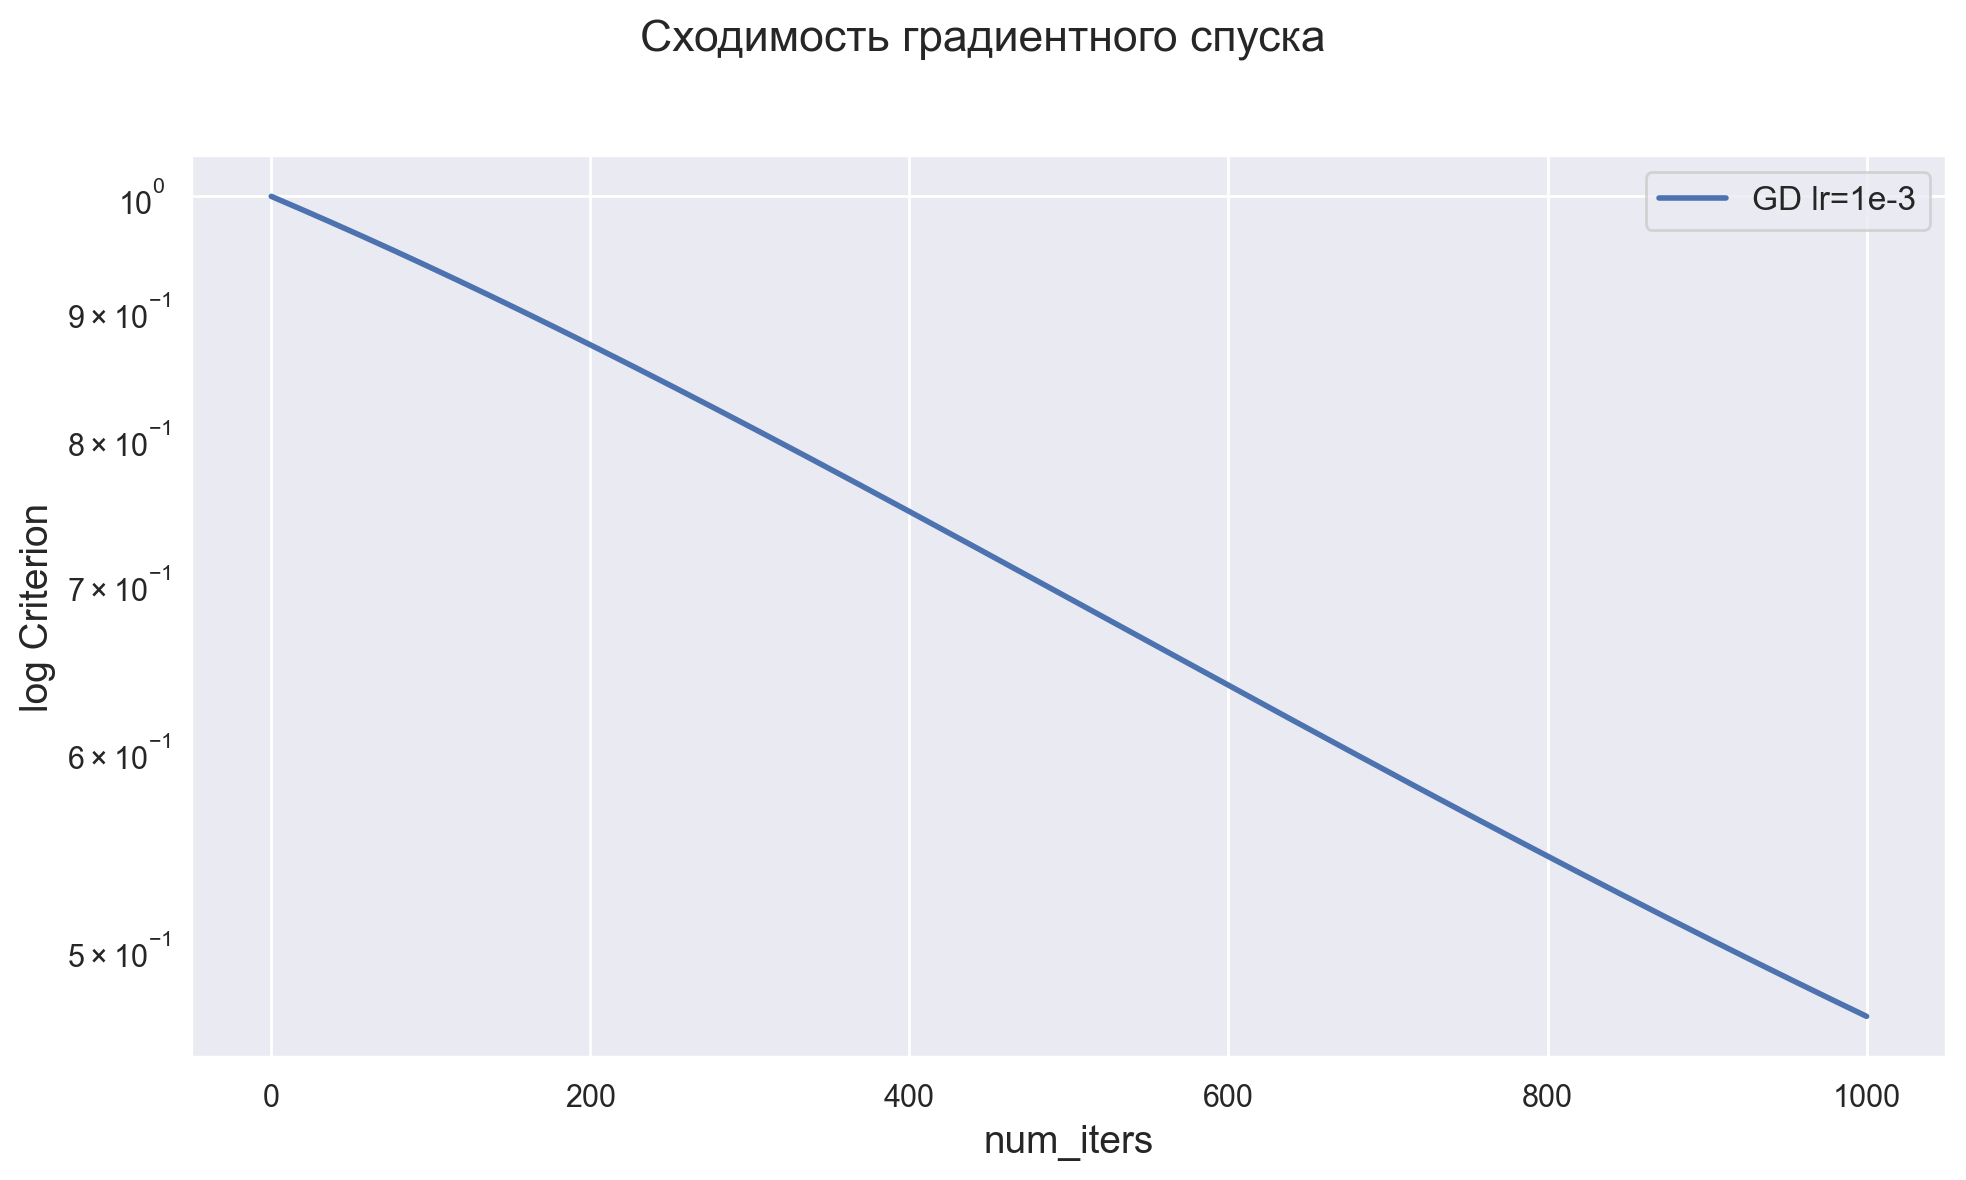

In [229]:
grad_opt = GradientDescent(lr=1e-3, name='GD lr=1e-3')
gd_res_baseline = test_optimizer(grad_opt)
plot_results([gd_res_baseline], 'Cходимость градиентного спуска')

GD lr=3/L: 100%|██████████| 1000/1000 [00:07<00:00, 129.70it/s, Loss=0.0814, Accuracy=0.996, Grad norm=0.000599]


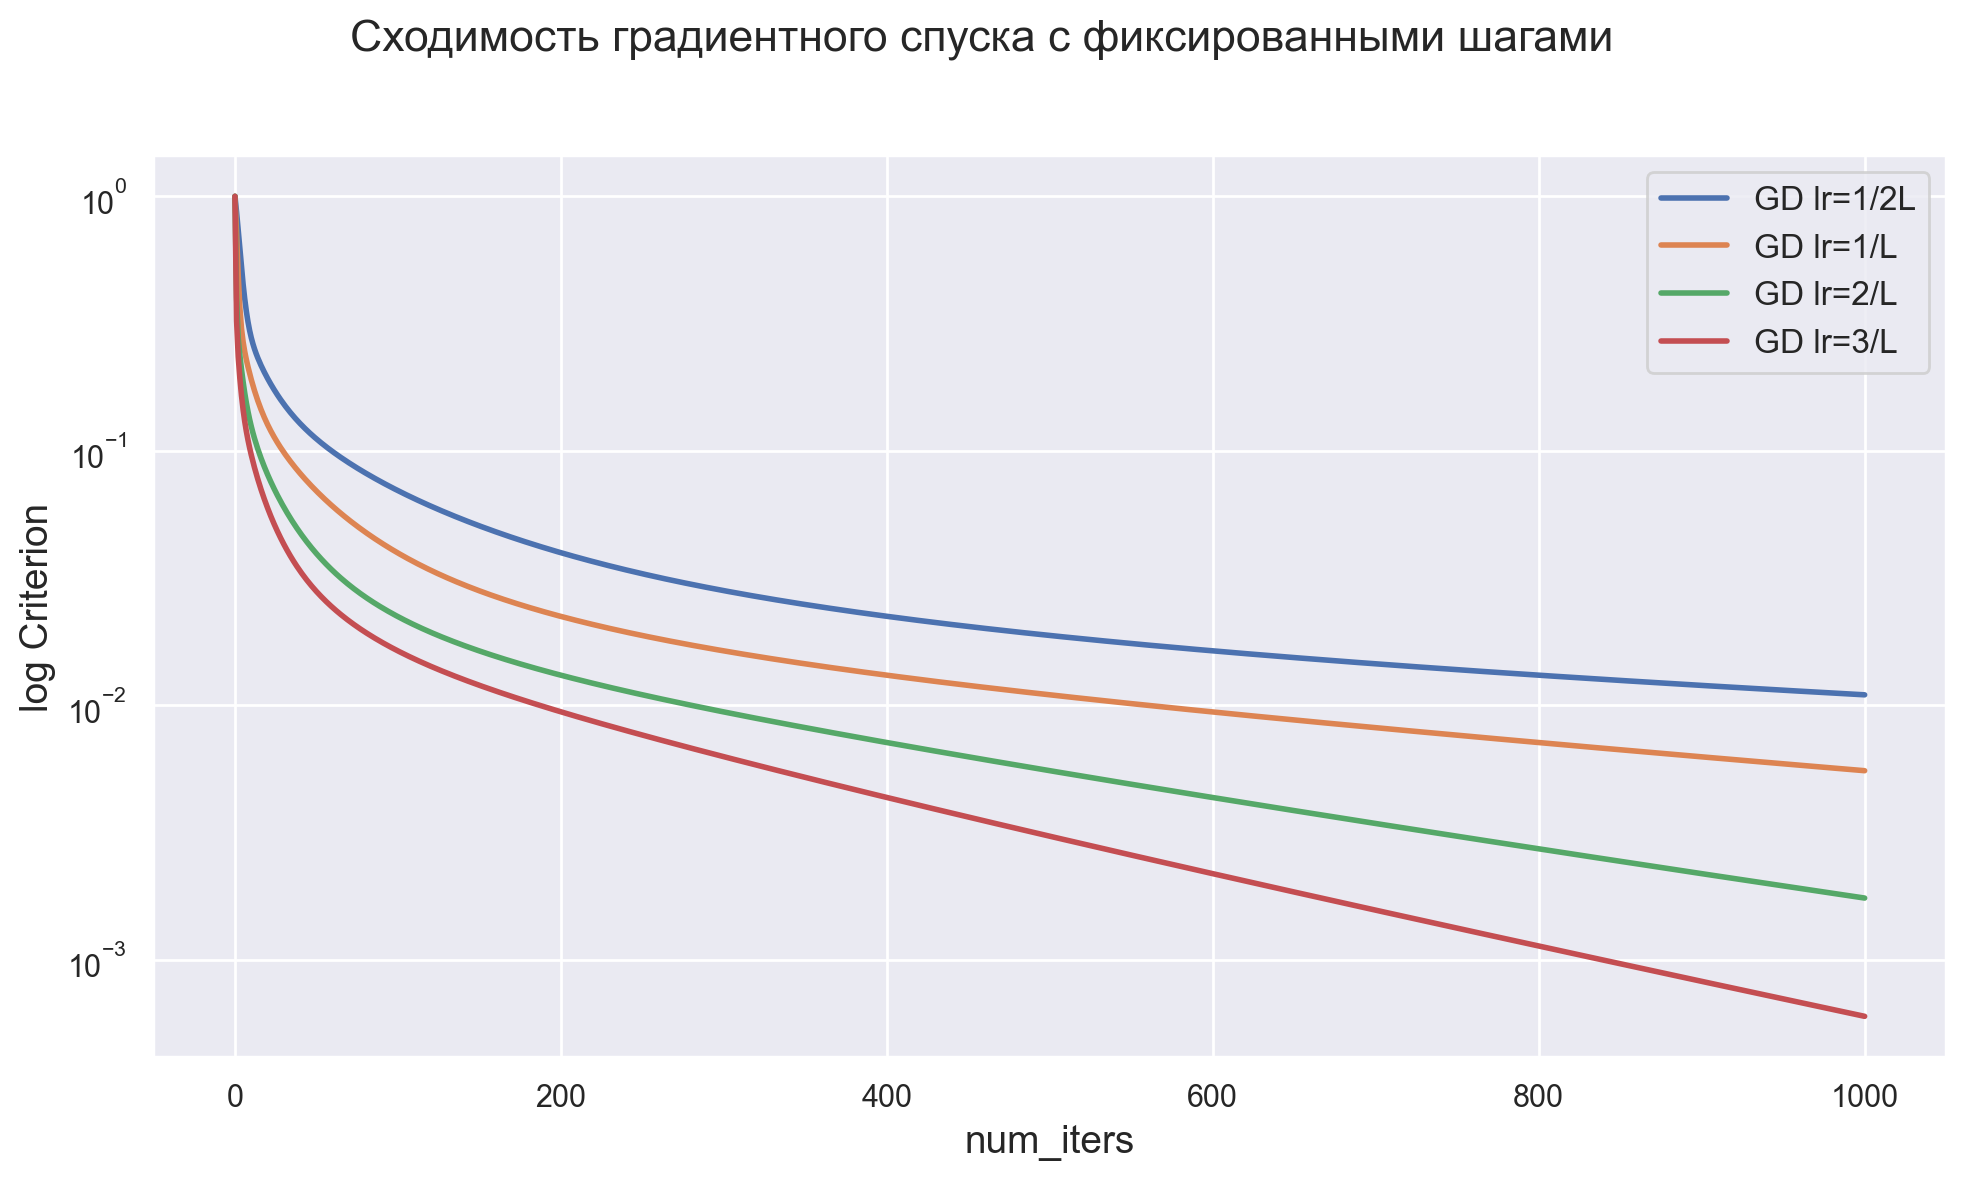

In [230]:
1.
grad_opt_1 = GradientDescent(lr=0.5/lipschitz_mush, name='GD lr=1/2L')
gd_res_baseline_1 = test_optimizer(grad_opt_1)

grad_opt_2 = GradientDescent(lr=1/lipschitz_mush, name='GD lr=1/L')
gd_res_baseline_2 = test_optimizer(grad_opt_2)

grad_opt_3 = GradientDescent(lr=2/lipschitz_mush, name='GD lr=2/L')
gd_res_baseline_3 = test_optimizer(grad_opt_3)

grad_opt_4 = GradientDescent(lr=3/lipschitz_mush, name='GD lr=3/L')
gd_res_baseline_4 = test_optimizer(grad_opt_4)

plot_results([gd_res_baseline_1, gd_res_baseline_2, gd_res_baseline_3, gd_res_baseline_4], 'Cходимость градиентного спуска с фиксированными шагами')

как мы видим градиентный спуск сходится все лучше с увеличением шага до $\frac{3}{L}$, в случае же с квадратичной задачей, шаг больше $\frac{2}{L}$ приводил бы к расхождению метода

GD lr=15.6/L:  88%|████████▊ | 883/1000 [00:14<00:01, 58.87it/s, Loss=0.0813, Accuracy=0.996, Grad norm=9.91e-9] 


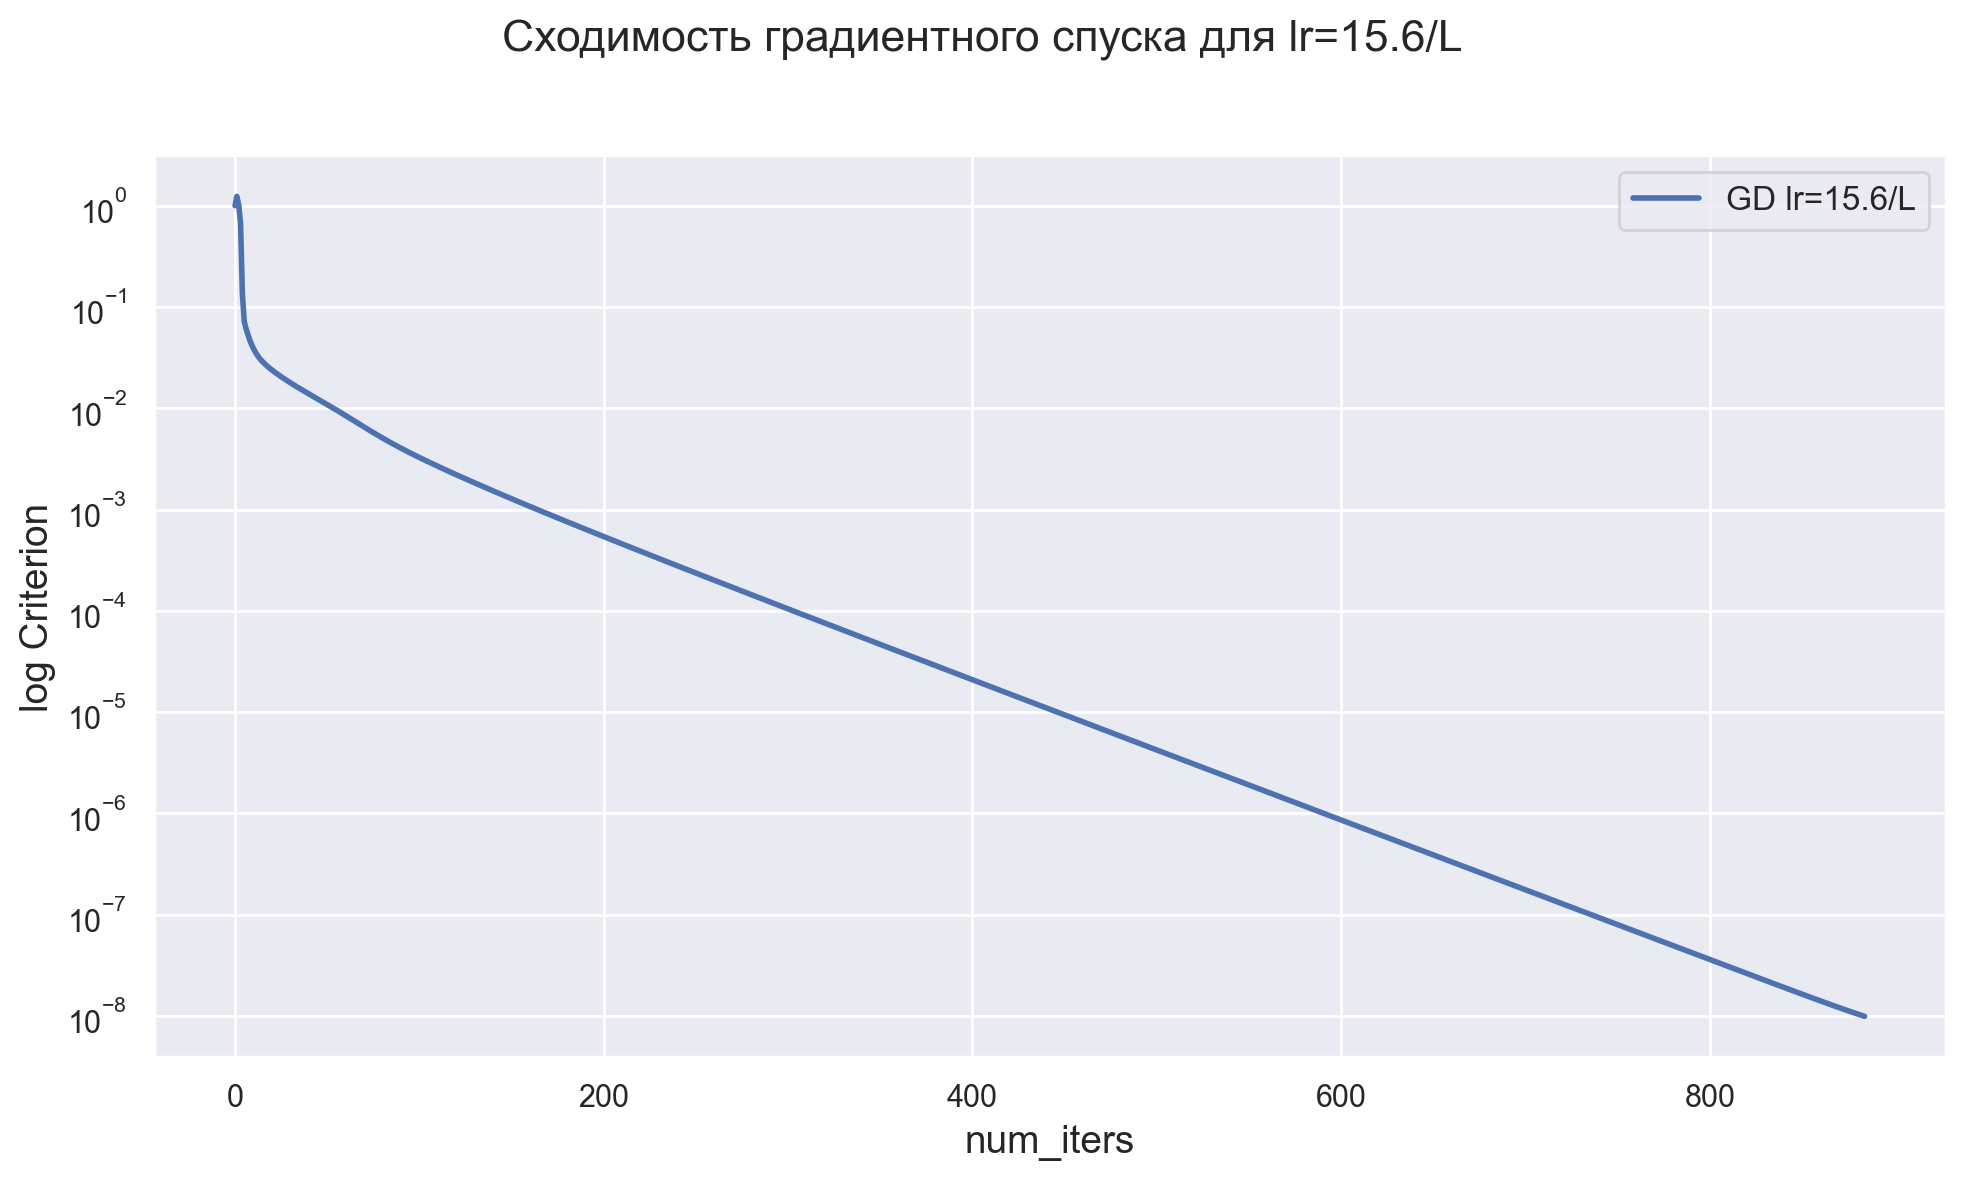

In [231]:
#я здесь немного пошалю, не обращайте внимания
grad_opt_5 = GradientDescent(lr=15.6/lipschitz_mush, name='GD lr=15.6/L')
gd_res_baseline_5 = test_optimizer(grad_opt_5)
plot_results([gd_res_baseline_5], "Cходимость градиентного спуска для lr=15.6/L")

GD lr=100 / (20 + k): 100%|██████████| 1000/1000 [00:09<00:00, 109.65it/s, Loss=0.0914, Accuracy=0.995, Grad norm=0.00613]


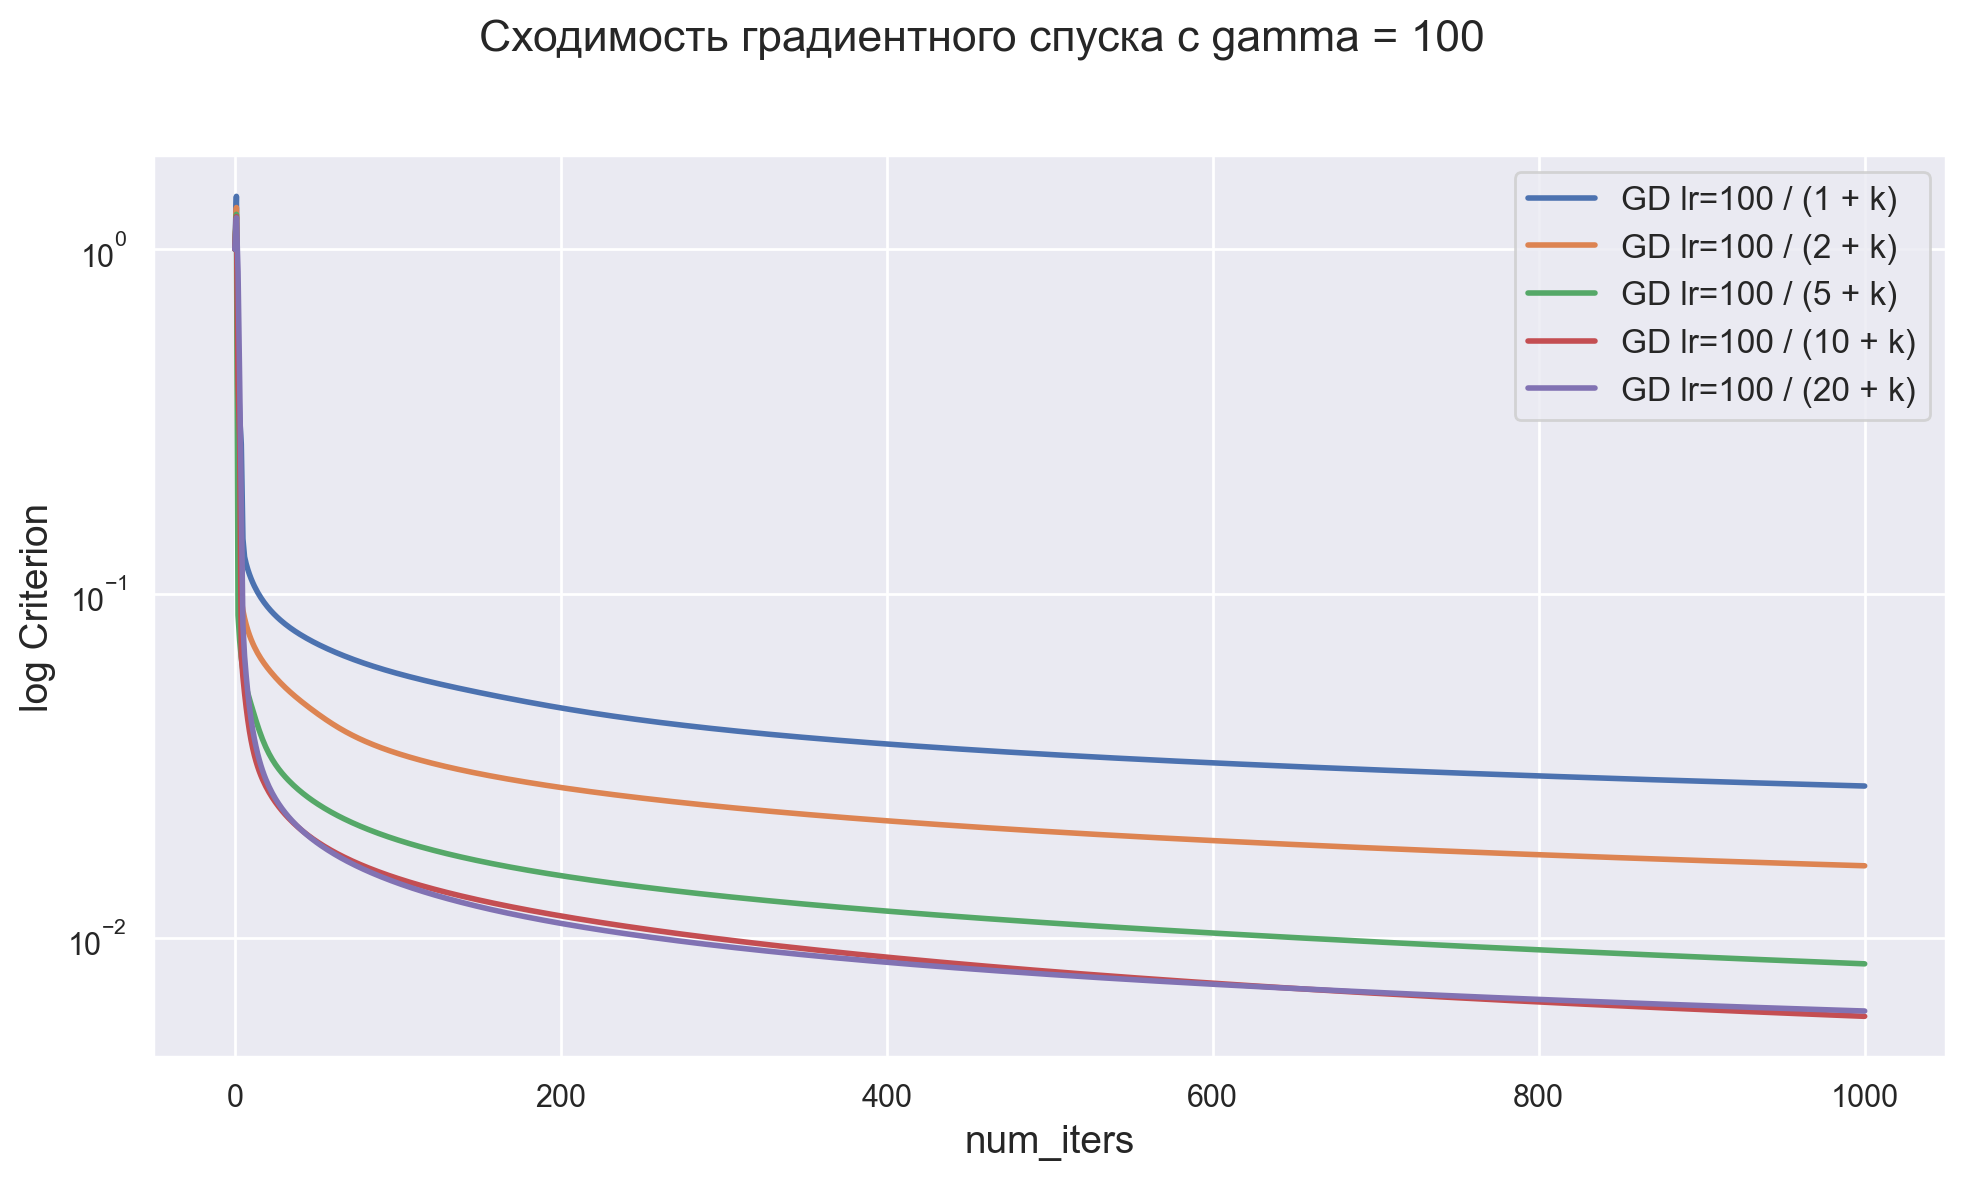

In [232]:
2.
def dynamic_lr(initial_gamma, delta):
    # TODO: return a lambda function that depends on k
    return lambda k : initial_gamma / (delta + k)

grad_opt_1 = GradientDescent(lr=dynamic_lr(100, 1), name='GD lr=100 / (1 + k)')
gd_res_baseline_1 = test_optimizer(grad_opt_1)

grad_opt_2 = GradientDescent(lr=dynamic_lr(100, 2), name='GD lr=100 / (2 + k)')
gd_res_baseline_2 = test_optimizer(grad_opt_2)

grad_opt_3 = GradientDescent(lr=dynamic_lr(100, 5), name='GD lr=100 / (5 + k)')
gd_res_baseline_3 = test_optimizer(grad_opt_3)

grad_opt_4 = GradientDescent(lr=dynamic_lr(100, 10), name='GD lr=100 / (10 + k)')
gd_res_baseline_4 = test_optimizer(grad_opt_4)

grad_opt_5 = GradientDescent(lr=dynamic_lr(100, 20), name='GD lr=100 / (20 + k)')
gd_res_baseline_5 = test_optimizer(grad_opt_5)


plot_results([gd_res_baseline_1, gd_res_baseline_2, gd_res_baseline_3, gd_res_baseline_4, gd_res_baseline_5], 'Cходимость градиентного спуска с gamma = 100')

Как можно заметить с увеличеним $\delta$ результаты улучшаются до $\delta = 10$. при $\delta \geq 20$ метод начинает сходится медленнее

GD lr=50 / (1 + k):   0%|          | 0/1000 [00:00<?, ?it/s, Loss=81.3, Accuracy=0.519, Grad norm=1.32]

GD lr=50 / (20 + k): 100%|██████████| 1000/1000 [00:06<00:00, 164.78it/s, Loss=0.113, Accuracy=0.989, Grad norm=0.0112]


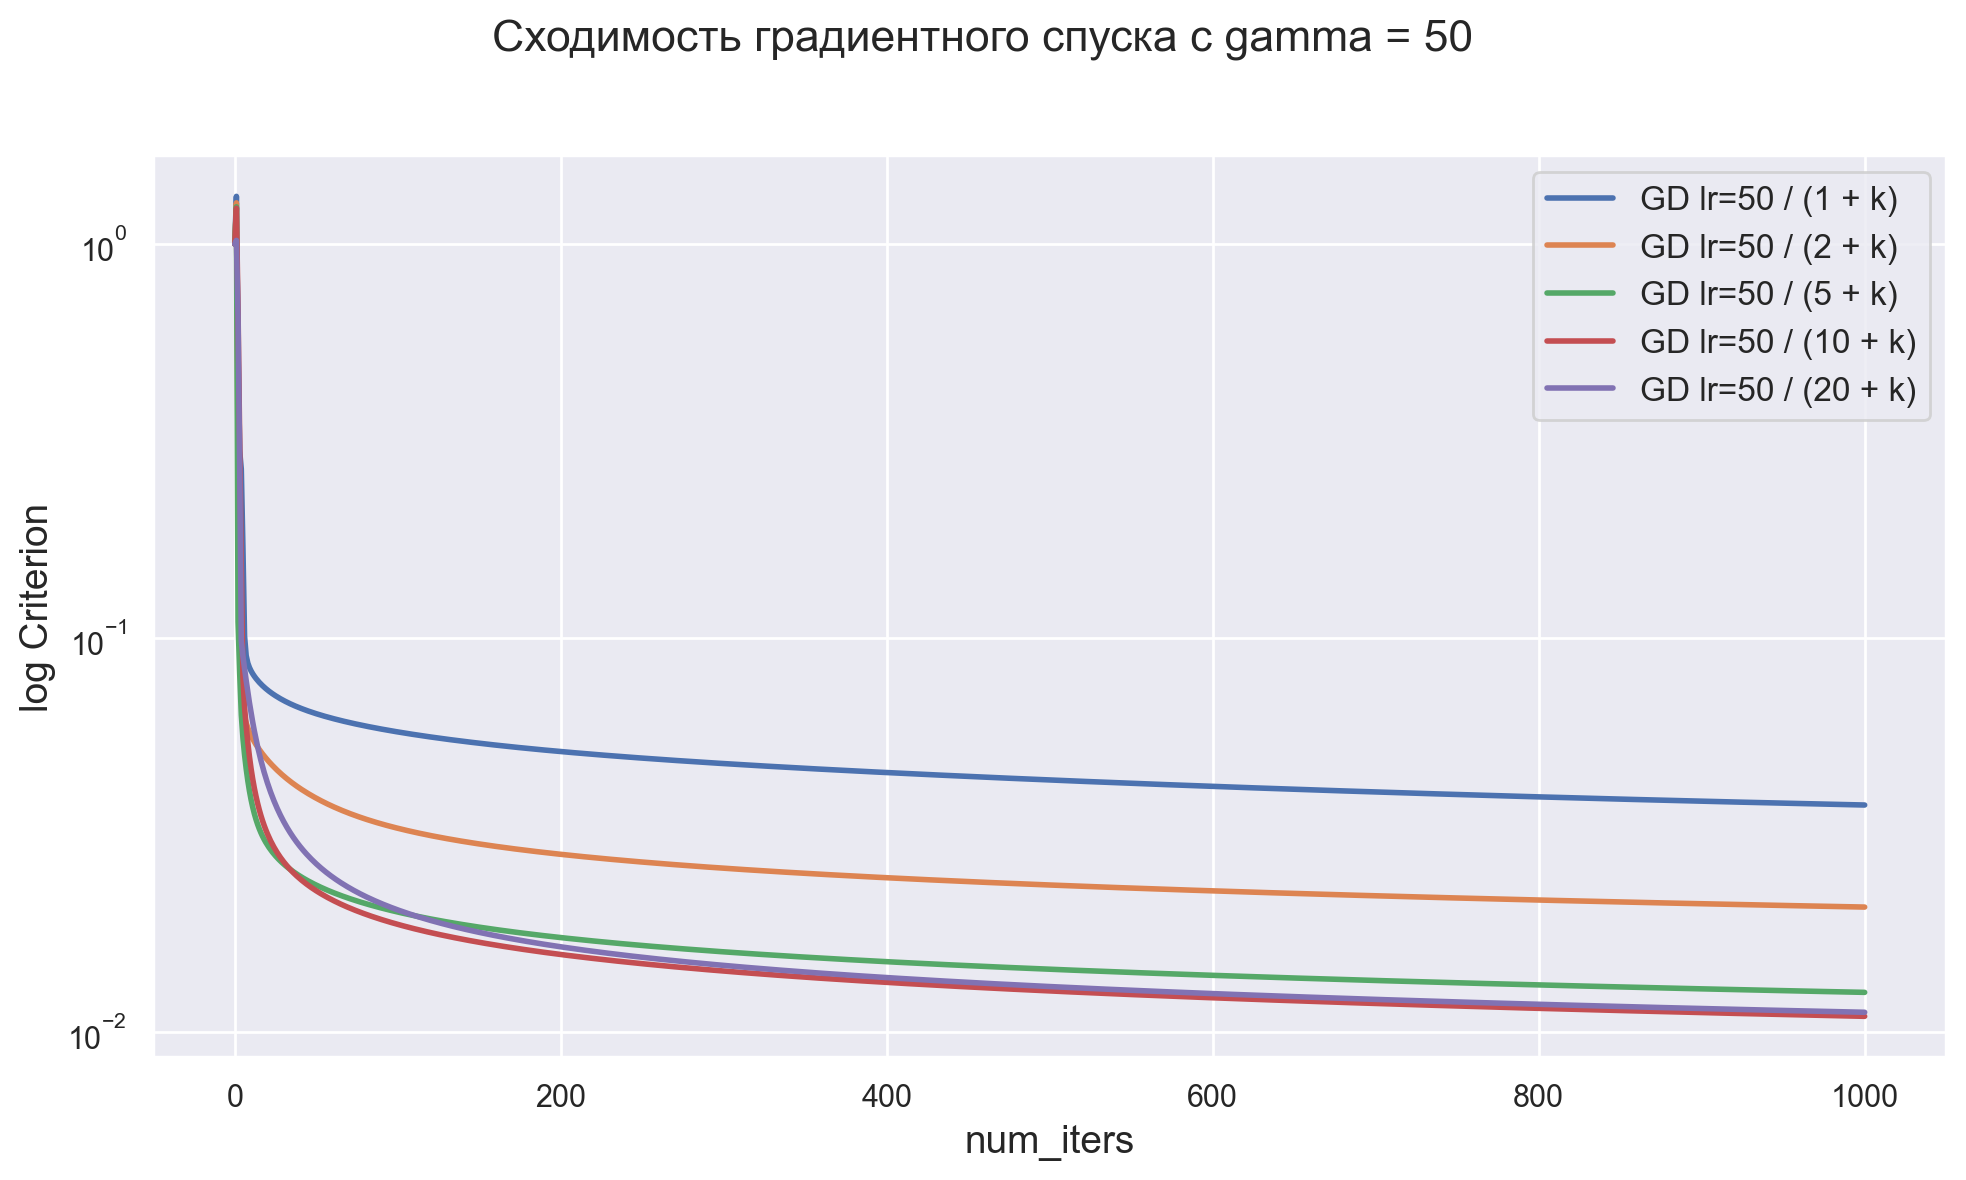

In [233]:
grad_opt_1 = GradientDescent(lr=dynamic_lr(50, 1), name='GD lr=50 / (1 + k)')
gd_res_baseline_1 = test_optimizer(grad_opt_1)

grad_opt_2 = GradientDescent(lr=dynamic_lr(50, 2), name='GD lr=50 / (2 + k)')
gd_res_baseline_2 = test_optimizer(grad_opt_2)

grad_opt_3 = GradientDescent(lr=dynamic_lr(50, 5), name='GD lr=50 / (5 + k)')
gd_res_baseline_3 = test_optimizer(grad_opt_3)

grad_opt_4 = GradientDescent(lr=dynamic_lr(50, 10), name='GD lr=50 / (10 + k)')
gd_res_baseline_4 = test_optimizer(grad_opt_4)

grad_opt_5 = GradientDescent(lr=dynamic_lr(50, 20), name='GD lr=50 / (20 + k)')
gd_res_baseline_5 = test_optimizer(grad_opt_5)


plot_results([gd_res_baseline_1, gd_res_baseline_2, gd_res_baseline_3, gd_res_baseline_4, gd_res_baseline_5], 'Cходимость градиентного спуска с gamma = 50')

аналогичная ситуация у $\gamma = 50$

GD lr=10 / (20 + k): 100%|██████████| 1000/1000 [00:04<00:00, 213.79it/s, Loss=0.217, Accuracy=0.95, Grad norm=0.039] 


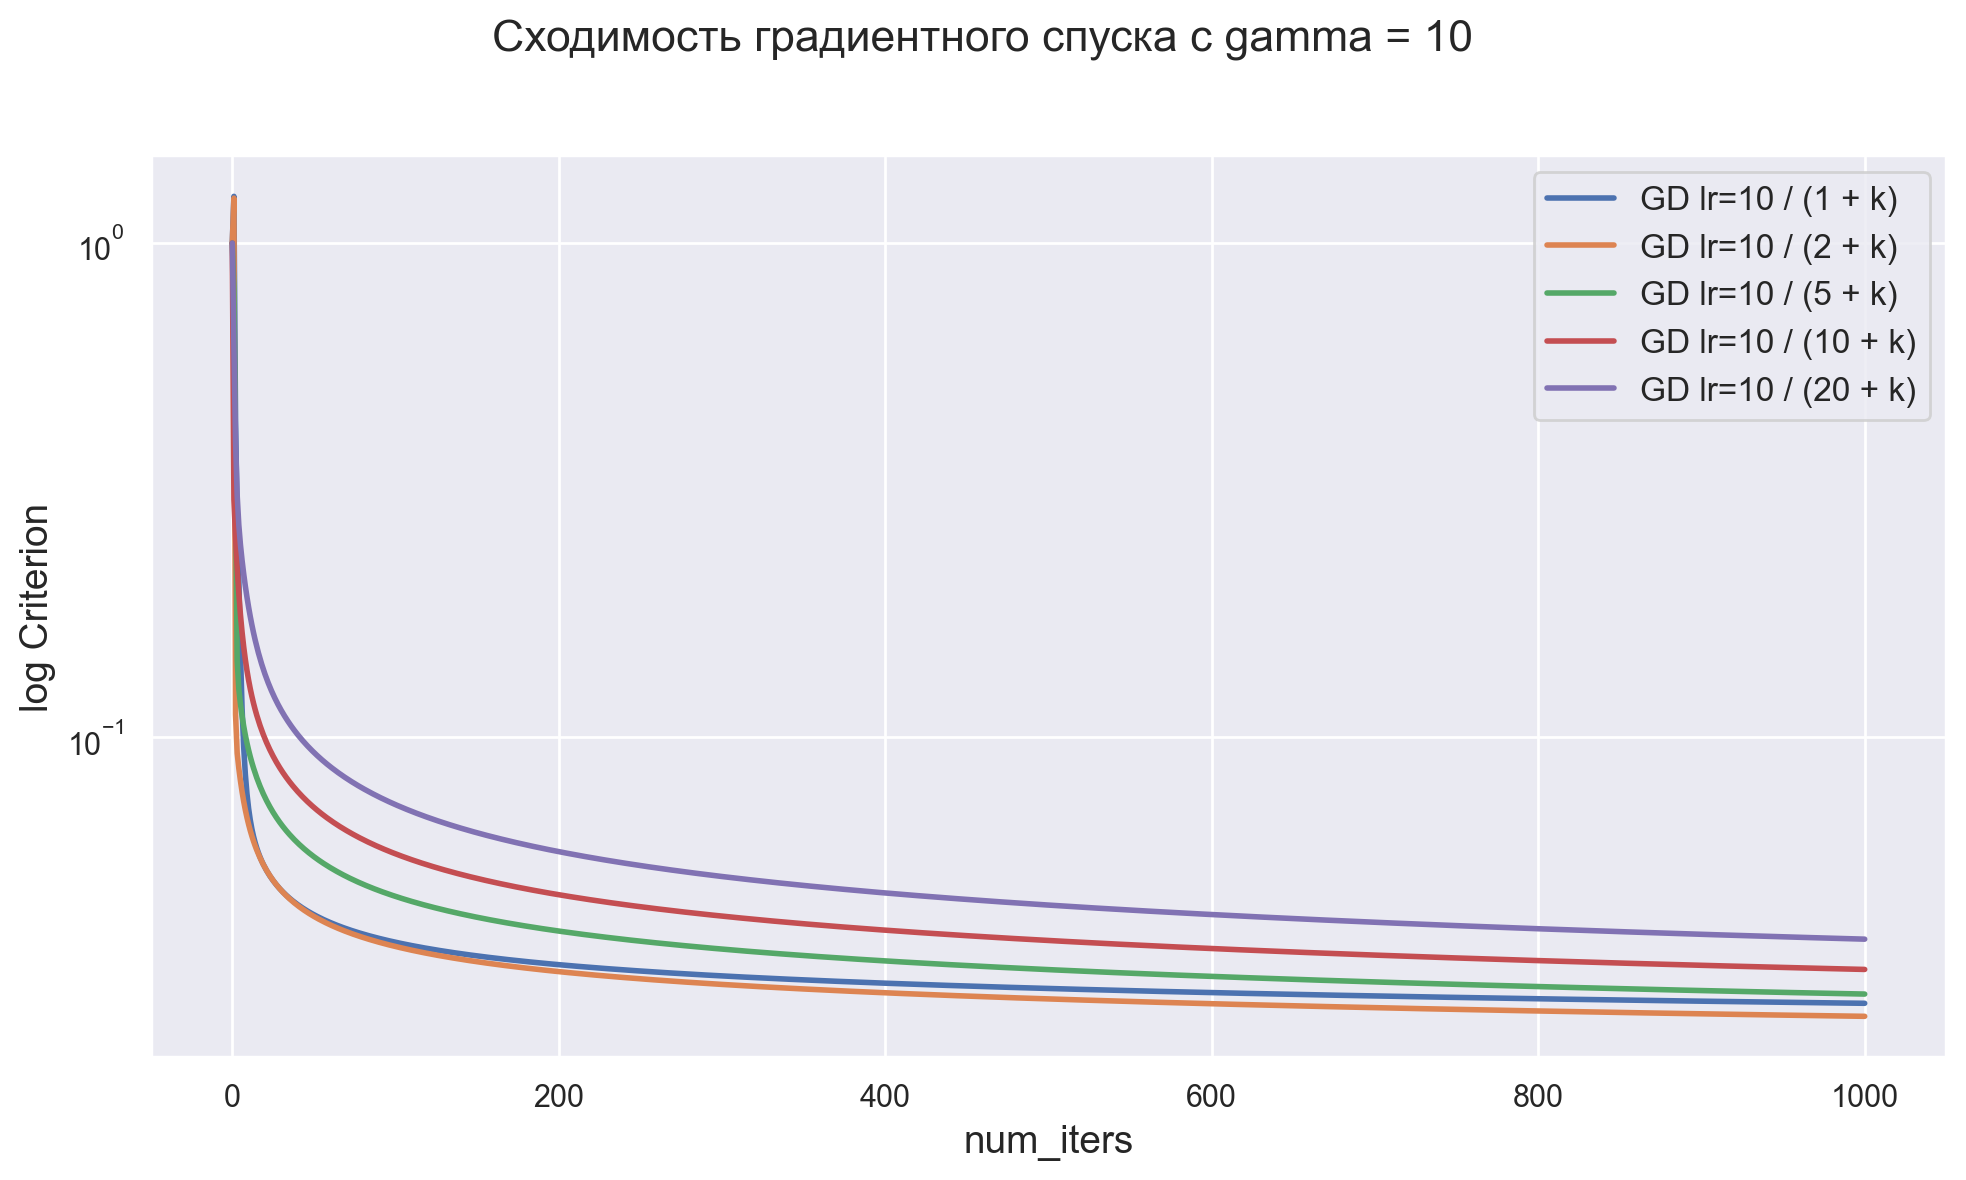

In [234]:
grad_opt_1 = GradientDescent(lr=dynamic_lr(10, 1), name='GD lr=10 / (1 + k)')
gd_res_baseline_1 = test_optimizer(grad_opt_1)

grad_opt_2 = GradientDescent(lr=dynamic_lr(10, 2), name='GD lr=10 / (2 + k)')
gd_res_baseline_2 = test_optimizer(grad_opt_2)

grad_opt_3 = GradientDescent(lr=dynamic_lr(10, 5), name='GD lr=10 / (5 + k)')
gd_res_baseline_3 = test_optimizer(grad_opt_3)

grad_opt_4 = GradientDescent(lr=dynamic_lr(10, 10), name='GD lr=10 / (10 + k)')
gd_res_baseline_4 = test_optimizer(grad_opt_4)

grad_opt_5 = GradientDescent(lr=dynamic_lr(10, 20), name='GD lr=10 / (20 + k)')
gd_res_baseline_5 = test_optimizer(grad_opt_5)


plot_results([gd_res_baseline_1, gd_res_baseline_2, gd_res_baseline_3, gd_res_baseline_4, gd_res_baseline_5], 'Cходимость градиентного спуска с gamma = 10')

Лучшее на что способен этот метод это точность в 1e-2 (по крайней мере судя по моим экспериментам)

GD lr=100 / (20 + sqrt(k)): 100%|██████████| 1000/1000 [00:05<00:00, 193.64it/s, Loss=0.0813, Accuracy=0.996, Grad norm=1.55e-5]


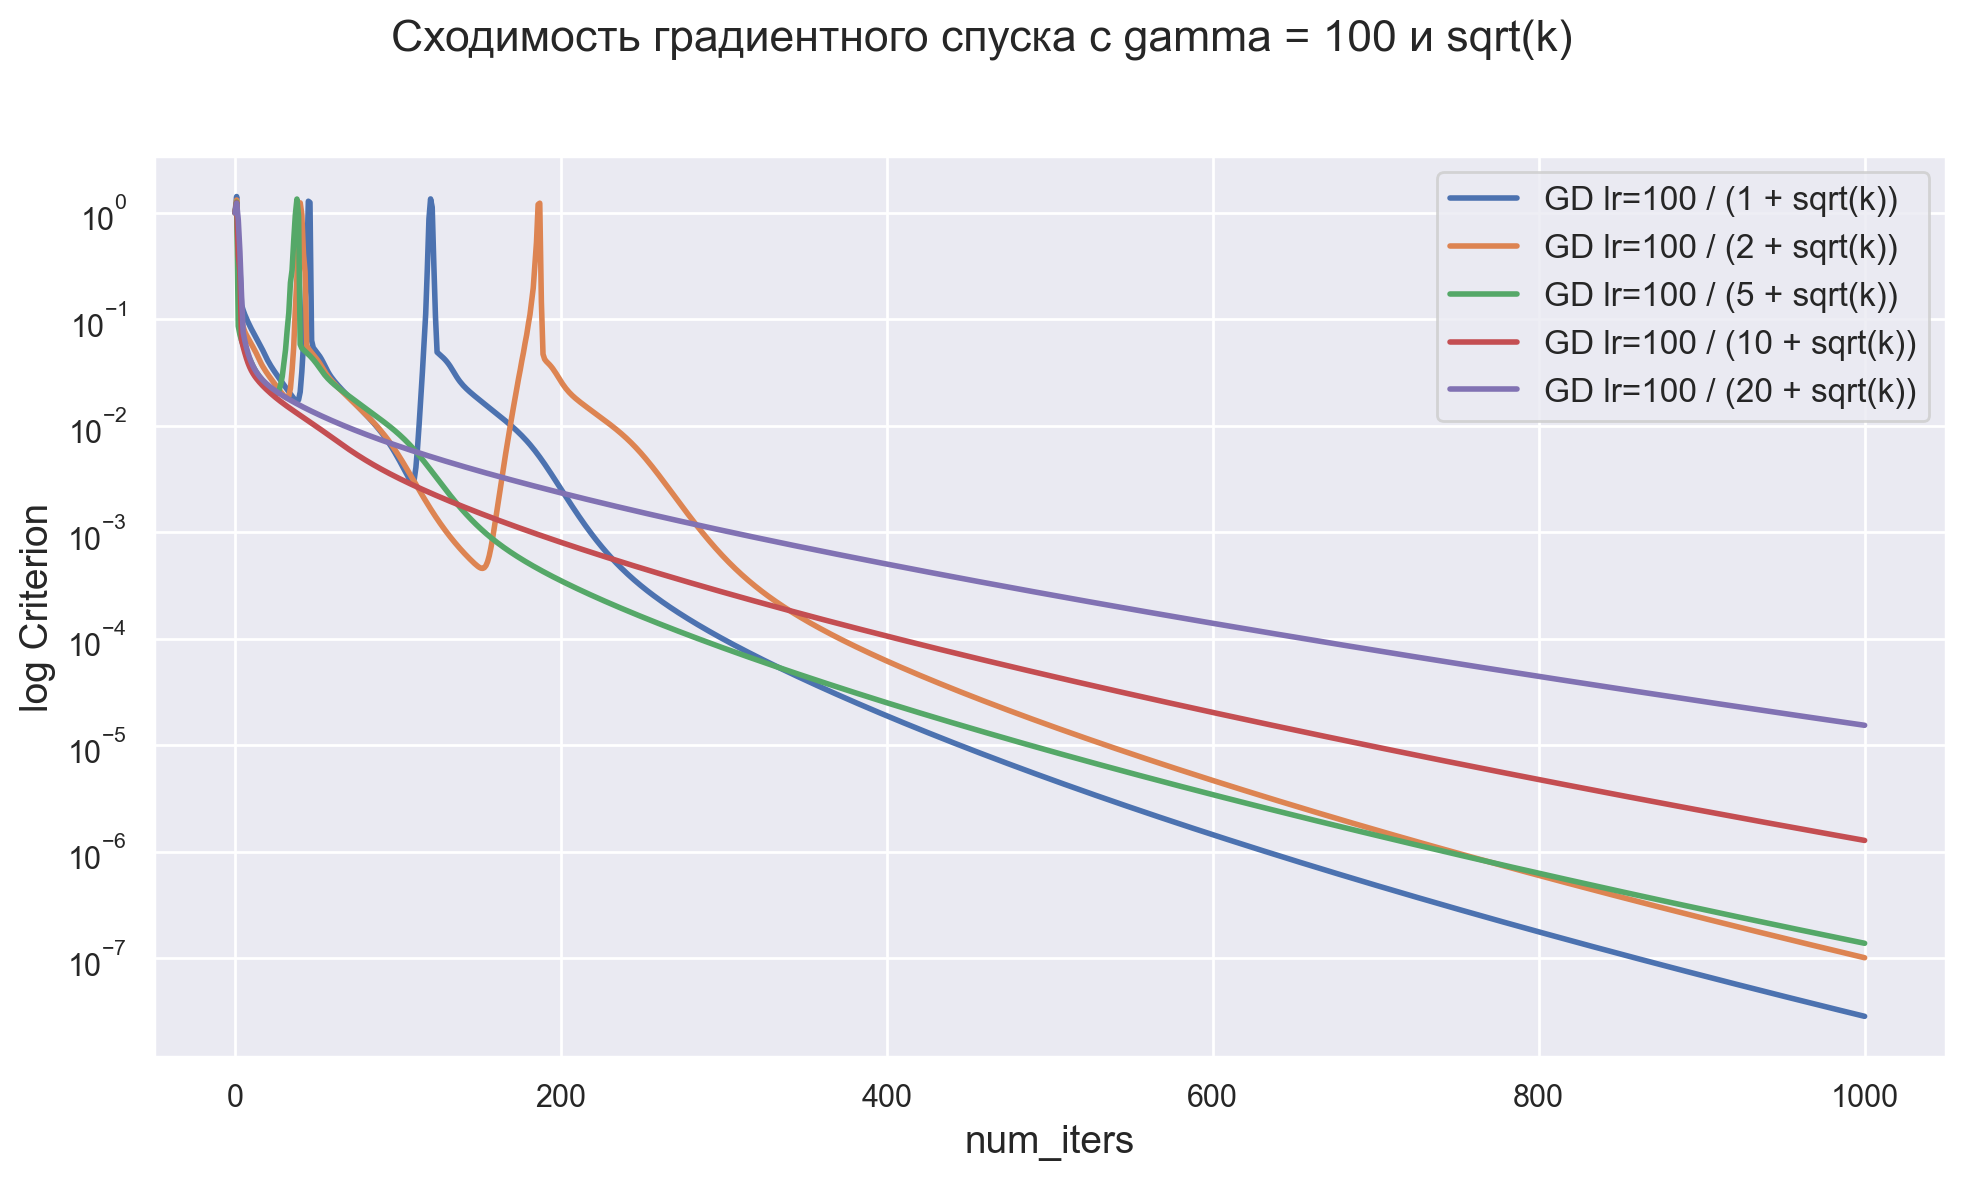

In [235]:
3.
def dynamic_lr_sqrt(initial_gamma, delta):
    # TODO: return a lambda function that depends on √k
    return lambda k : initial_gamma / (delta + np.sqrt(k))

grad_opt_1 = GradientDescent(lr=dynamic_lr_sqrt(100, 1), name='GD lr=100 / (1 + sqrt(k))')
gd_res_baseline_1 = test_optimizer(grad_opt_1)

grad_opt_2 = GradientDescent(lr=dynamic_lr_sqrt(100, 2), name='GD lr=100 / (2 + sqrt(k))')
gd_res_baseline_2 = test_optimizer(grad_opt_2)

grad_opt_3 = GradientDescent(lr=dynamic_lr_sqrt(100, 5), name='GD lr=100 / (5 + sqrt(k))')
gd_res_baseline_3 = test_optimizer(grad_opt_3)

grad_opt_4 = GradientDescent(lr=dynamic_lr_sqrt(100, 10), name='GD lr=100 / (10 + sqrt(k))')
gd_res_baseline_4 = test_optimizer(grad_opt_4)

grad_opt_5 = GradientDescent(lr=dynamic_lr_sqrt(100, 20), name='GD lr=100 / (20 + sqrt(k))')
gd_res_baseline_5 = test_optimizer(grad_opt_5)


plot_results([gd_res_baseline_1, gd_res_baseline_2, gd_res_baseline_3, gd_res_baseline_4, gd_res_baseline_5], 'Cходимость градиентного спуска с gamma = 100 и sqrt(k)')

GD lr=50 / (20 + sqrt(k)): 100%|██████████| 1000/1000 [00:05<00:00, 182.13it/s, Loss=0.0813, Accuracy=0.996, Grad norm=0.00045]


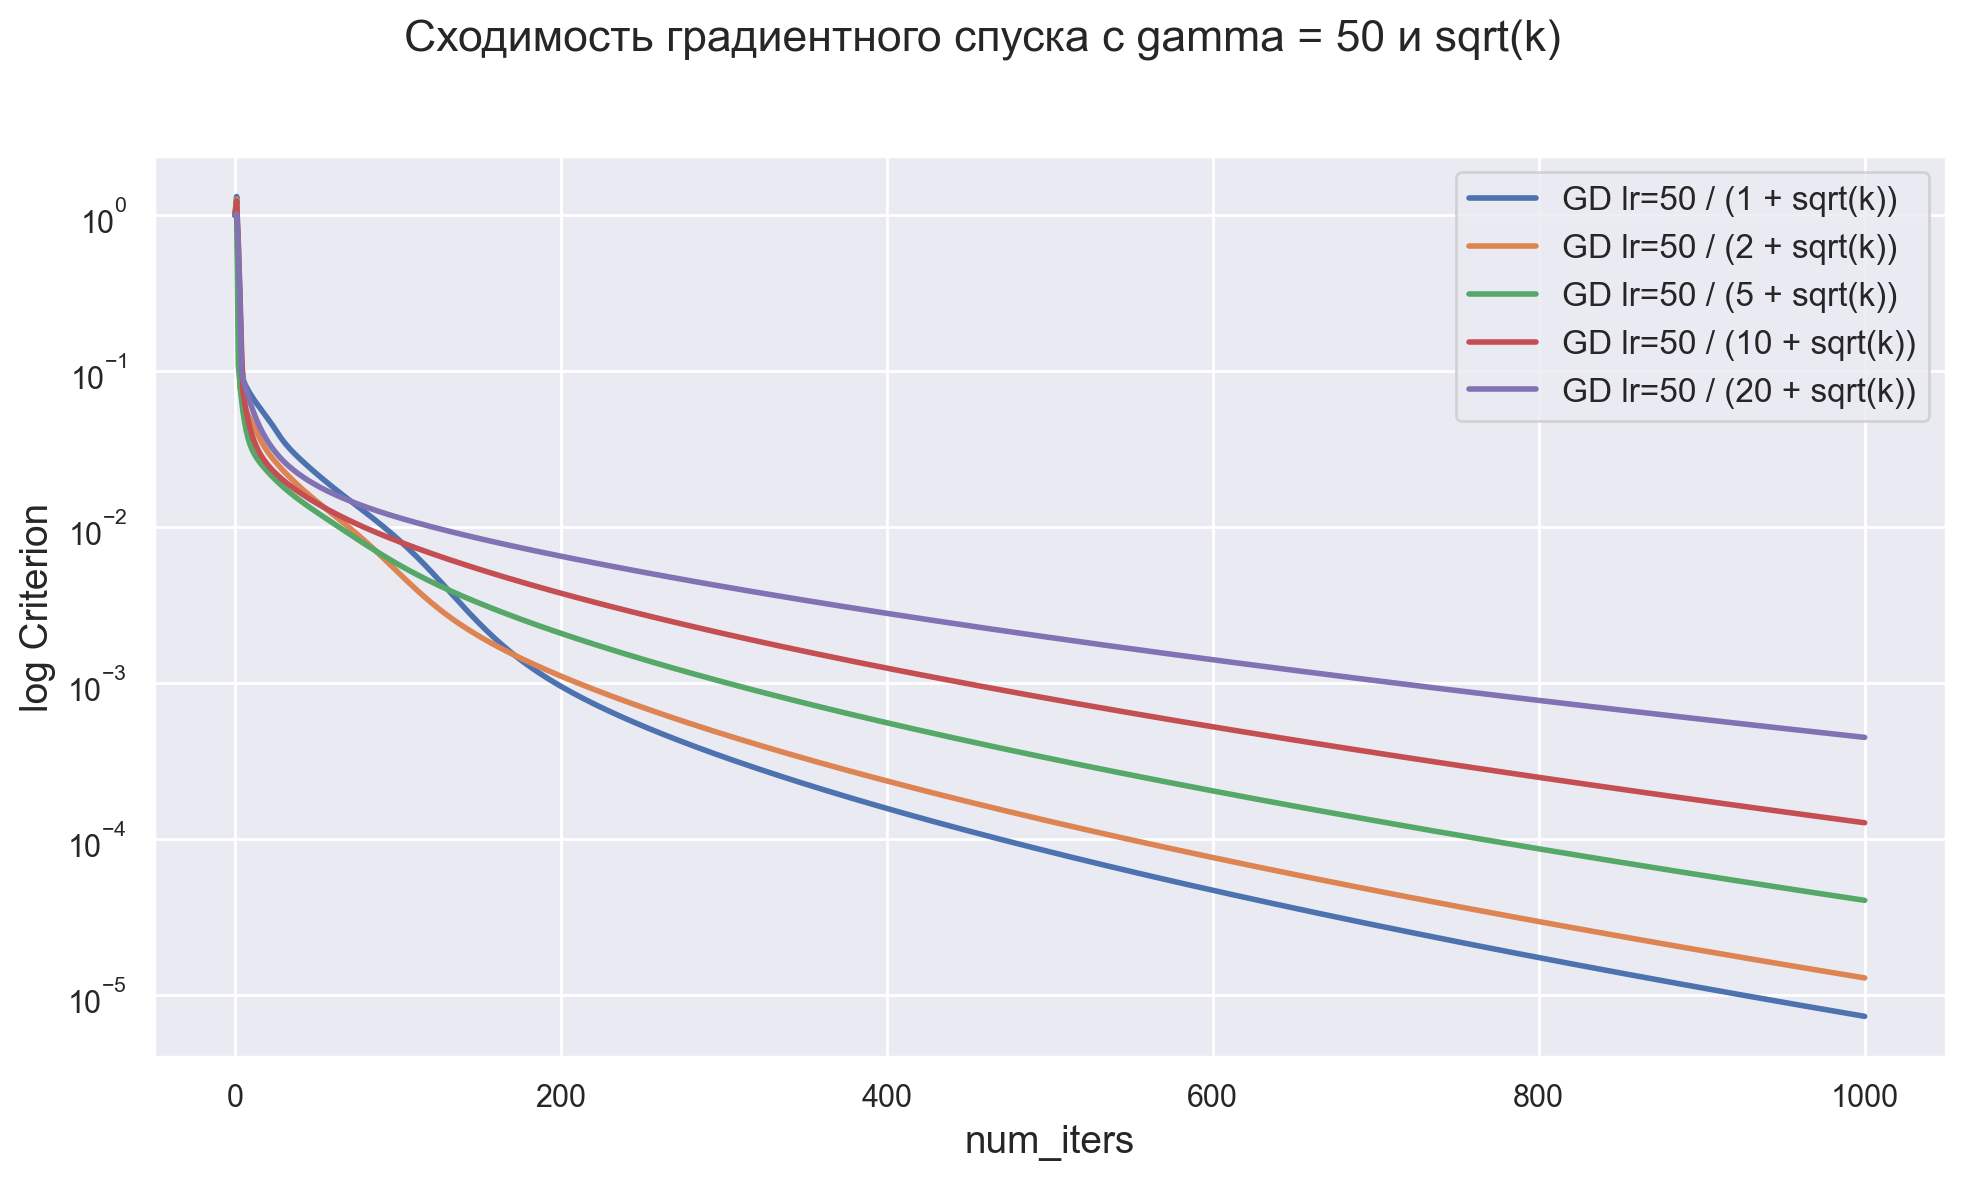

In [236]:
grad_opt_1 = GradientDescent(lr=dynamic_lr_sqrt(50, 1), name='GD lr=50 / (1 + sqrt(k))')
gd_res_baseline_1 = test_optimizer(grad_opt_1)

grad_opt_2 = GradientDescent(lr=dynamic_lr_sqrt(50, 2), name='GD lr=50 / (2 + sqrt(k))')
gd_res_baseline_2 = test_optimizer(grad_opt_2)

grad_opt_3 = GradientDescent(lr=dynamic_lr_sqrt(50, 5), name='GD lr=50 / (5 + sqrt(k))')
gd_res_baseline_3 = test_optimizer(grad_opt_3)

grad_opt_4 = GradientDescent(lr=dynamic_lr_sqrt(50, 10), name='GD lr=50 / (10 + sqrt(k))')
gd_res_baseline_4 = test_optimizer(grad_opt_4)

grad_opt_5 = GradientDescent(lr=dynamic_lr_sqrt(50, 20), name='GD lr=50 / (20 + sqrt(k))')
gd_res_baseline_5 = test_optimizer(grad_opt_5)


plot_results([gd_res_baseline_1, gd_res_baseline_2, gd_res_baseline_3, gd_res_baseline_4, gd_res_baseline_5], 'Cходимость градиентного спуска с gamma = 50 и sqrt(k)')

ну судя по тому что мы увидели, наилучшые гиперпараметры это $\gamma = 100, \delta = 1$, правда для $\gamma = 100$ происходит что-то странное, но я считаю что это из за экстремальности $\gamma$

GD lr= 100 / (1 + sqrt(k)): 100%|██████████| 1000/1000 [00:05<00:00, 192.99it/s, Loss=0.0813, Accuracy=0.996, Grad norm=2.86e-8]


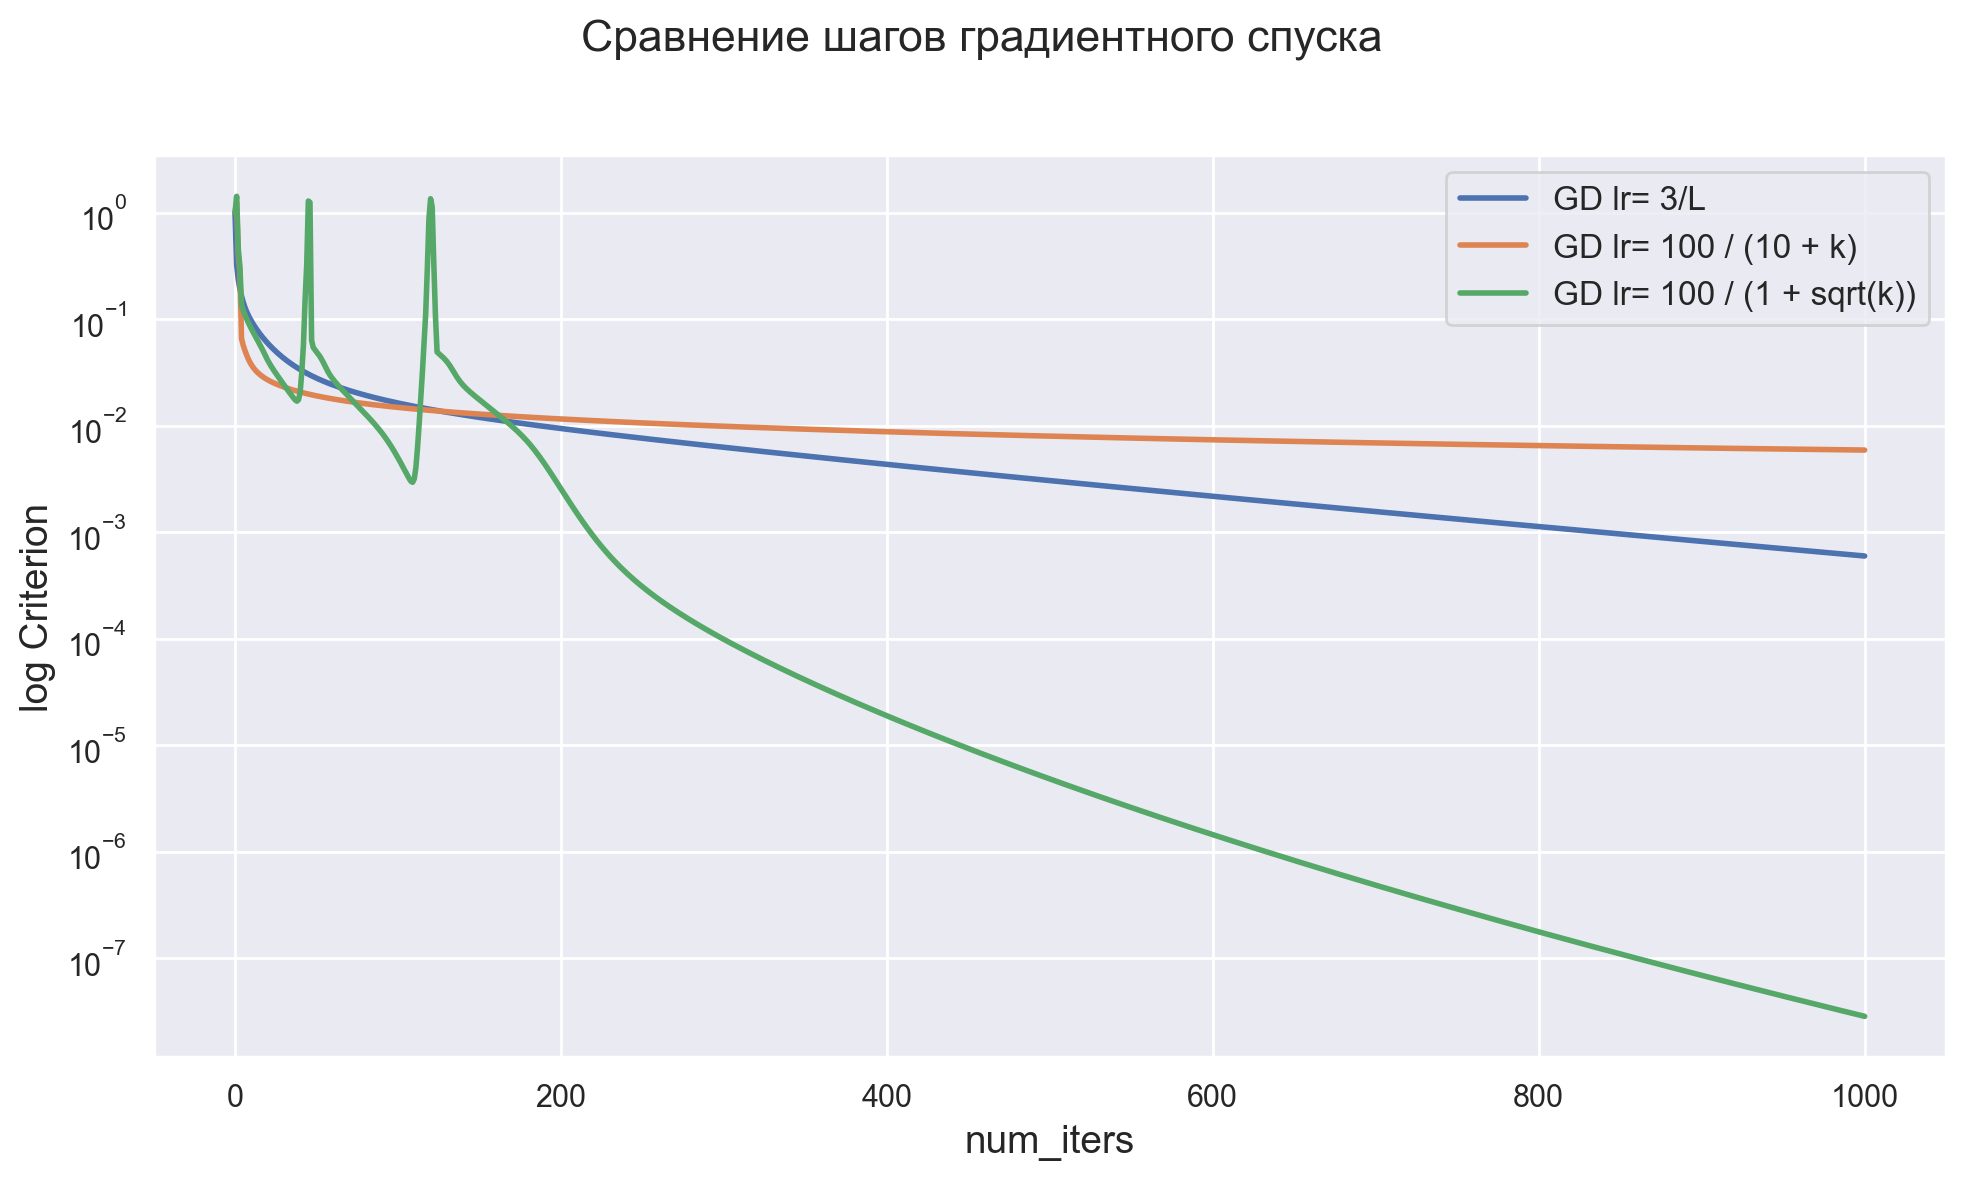

In [237]:
4.

grad_opt_fix = GradientDescent(lr=3/lipschitz_mush, name='GD lr= 3/L')
gd_res_fix = test_optimizer(grad_opt_fix)

grad_opt_dynamic = GradientDescent(lr=dynamic_lr(100, 10), name='GD lr= 100 / (10 + k)')
gd_res_dynamic = test_optimizer(grad_opt_dynamic)

grad_opt_dynamic_sqrt = GradientDescent(lr=dynamic_lr_sqrt(100, 1), name='GD lr= 100 / (1 + sqrt(k))')
gd_res_dynamic_sqrt = test_optimizer(grad_opt_dynamic_sqrt)

plot_results([gd_res_fix, gd_res_dynamic, gd_res_dynamic_sqrt], "Сравнение шагов градиентного спуска")


In [238]:
best_final_gd_res = gd_res_dynamic_sqrt

### Задача 3 (1 балл)

Рассмотрим метод тяжёлого шарика (Heavy Ball)

$$ w^{k+1} = w^k - \gamma_k \nabla \mathcal{L}(w^k) + \tau_k (w^k - w^{k-1}) $$

- Реализуйте шаг метода тяжёлого шарика
- Используйте шаг $\gamma = \frac{1}{L}$.
1. Рассмотрите моментум  $\tau = \frac{\sqrt{L} - \sqrt{\mu}}{\sqrt{L} + \sqrt{\mu}}$ и несколько моментумов в его окрестности: $s \cdot \tau$, где $s \in [0.9, 1.1]$. Рассмотрите не менее 3-х окрестностей.
2. Рассмотрите моментумы равные  $\frac{k}{k+3}$, $\frac{k}{k+2}$, $\frac{k}{k+1}$ ($k$ — номер итерации).
3. Сравните полученные результаты.

In [239]:
class HeavyBall(ManualSolver):
    def __init__(self, lr, beta, init_w, name) -> None:
        super().__init__(lr, name, True, False)
        self.beta = beta if isinstance(beta, Callable) else lambda _: beta
        self.w_prev = init_w

    def step(self, w: np.ndarray, k: int, grad_f: np.ndarray, hess_f: None) -> np.ndarray:
        # TODO: implement heavy ball iteration step
        w_next = w - self.lr(k) * grad_f + self.beta(k) * (w - self.w_prev)
        self.w_prev = w.copy()
        return w_next

HB lr= 1/L, beta= 1.1tau:   4%|▍         | 44/1000 [00:00<00:09, 95.65it/s, Loss=1.01e+3, Accuracy=0.938, Grad norm=1.73]/var/folders/5d/bsm3kt3d4qdc55zn6zggxf800000gq/T/ipykernel_38544/1863604594.py:4: RuntimeWarning: overflow encountered in exp
  return np.exp(M)
HB lr= 1/L, beta= 1.1tau: 100%|██████████| 1000/1000 [00:05<00:00, 192.85it/s, Loss=inf, Accuracy=0.941, Grad norm=6.52e+34]


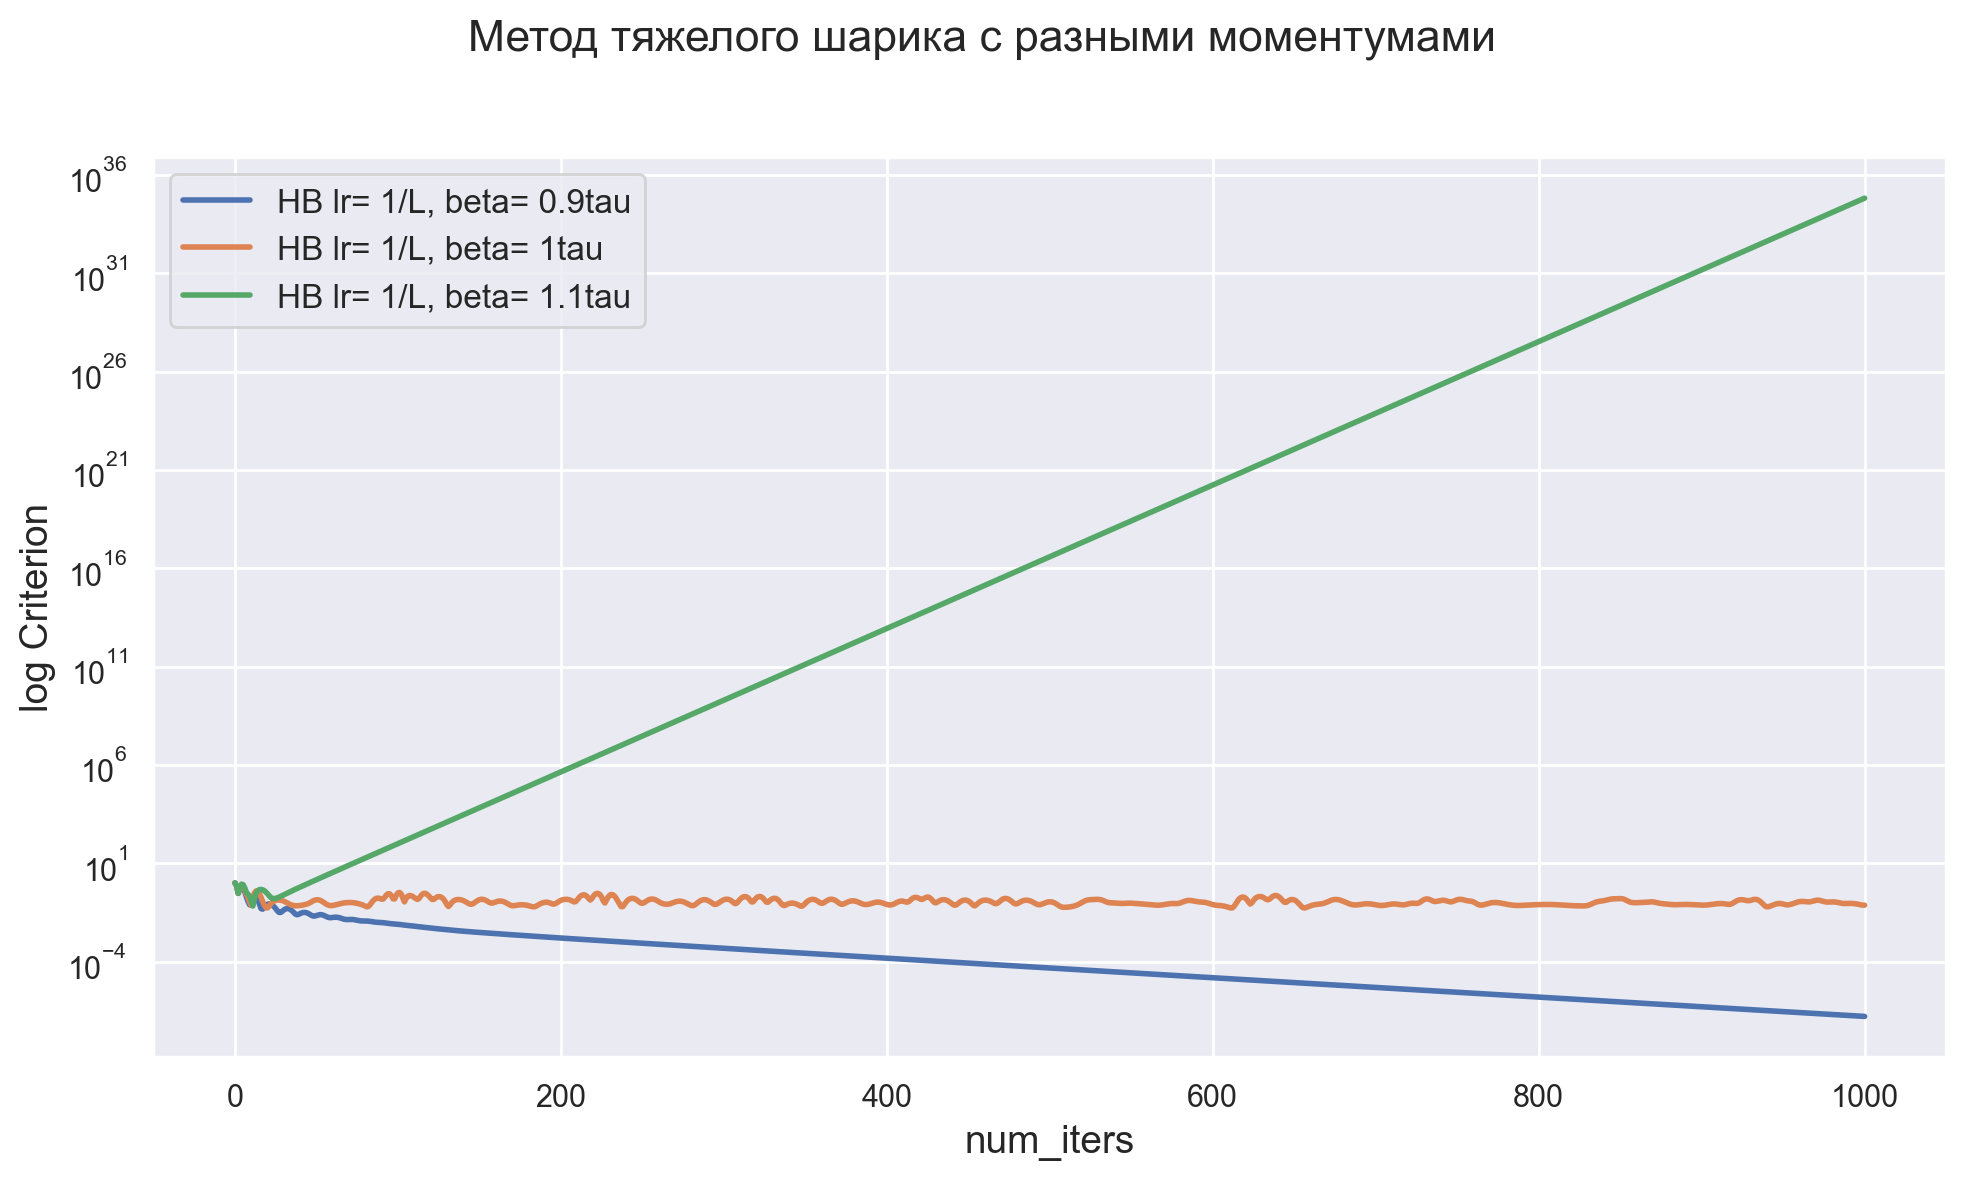

In [240]:
1.
tau = (np.sqrt(lipschitz_mush) - np.sqrt(lambda_mush)) / (np.sqrt(lipschitz_mush) - np.sqrt(lambda_mush))

hb_opt_1 = HeavyBall(lr=1/lipschitz_mush, beta=0.9*tau, init_w=start_w_mush, name="HB lr= 1/L, beta= 0.9tau")
hb_res_1 = test_optimizer(hb_opt_1)

hb_opt_2 = HeavyBall(lr=1/lipschitz_mush, beta=1*tau, init_w=start_w_mush, name="HB lr= 1/L, beta= 1tau")
hb_res_2 = test_optimizer(hb_opt_2)

hb_opt_3 = HeavyBall(lr=1/lipschitz_mush, beta=1.1*tau, init_w=start_w_mush, name="HB lr= 1/L, beta= 1.1tau")
hb_res_3 = test_optimizer(hb_opt_3)

plot_results([hb_res_1, hb_res_2, hb_res_3], "Метод тяжелого шарика с разными моментумами")

для $ beta = 1\tau, 1.1\tau$ метод не сходится

HB lr= 1/L, beta= 0.99tau: 100%|██████████| 1000/1000 [00:05<00:00, 175.40it/s, Loss=0.0813, Accuracy=0.996, Grad norm=0.00105]


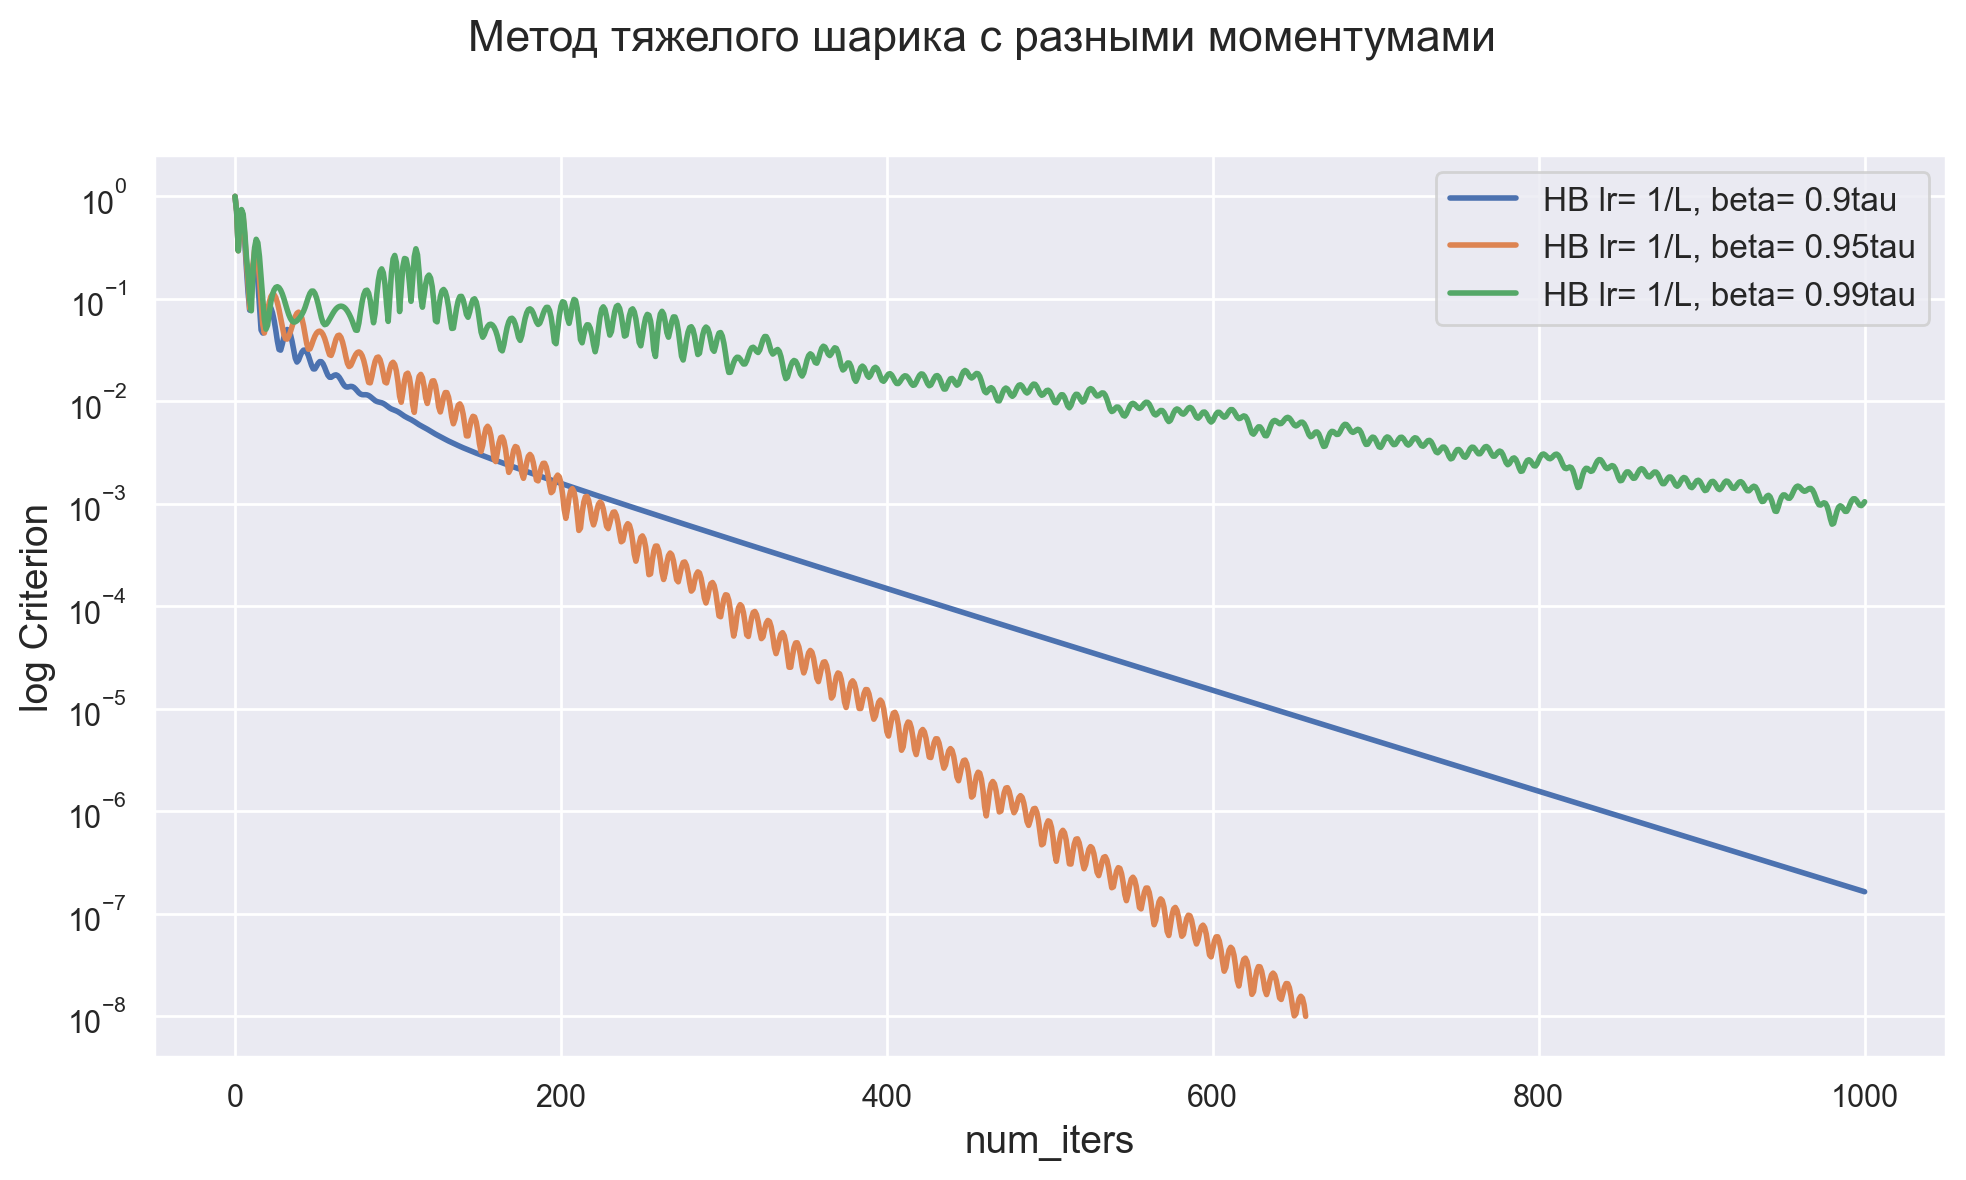

In [241]:
1.
tau = (np.sqrt(lipschitz_mush) - np.sqrt(lambda_mush)) / (np.sqrt(lipschitz_mush) - np.sqrt(lambda_mush))

hb_opt_1 = HeavyBall(lr=1/lipschitz_mush, beta=0.9*tau, init_w=start_w_mush, name="HB lr= 1/L, beta= 0.9tau")
hb_res_1 = test_optimizer(hb_opt_1)

hb_opt_2 = HeavyBall(lr=1/lipschitz_mush, beta=0.95*tau, init_w=start_w_mush, name="HB lr= 1/L, beta= 0.95tau")
hb_res_2 = test_optimizer(hb_opt_2)

hb_opt_3 = HeavyBall(lr=1/lipschitz_mush, beta=0.99*tau, init_w=start_w_mush, name="HB lr= 1/L, beta= 0.99tau")
hb_res_3 = test_optimizer(hb_opt_3)

plot_results([hb_res_1, hb_res_2, hb_res_3], "Метод тяжелого шарика с разными моментумами")

Мы наблюдаем за отличным результатом который показал нам гиперпараметр $ beta = 0.95\tau $. Остальные графики тоже сходятся хорошо

HB lr= 1/L, beta=  k/(k+1): 100%|██████████| 1000/1000 [00:06<00:00, 152.05it/s, Loss=0.0845, Accuracy=0.996, Grad norm=0.00881]


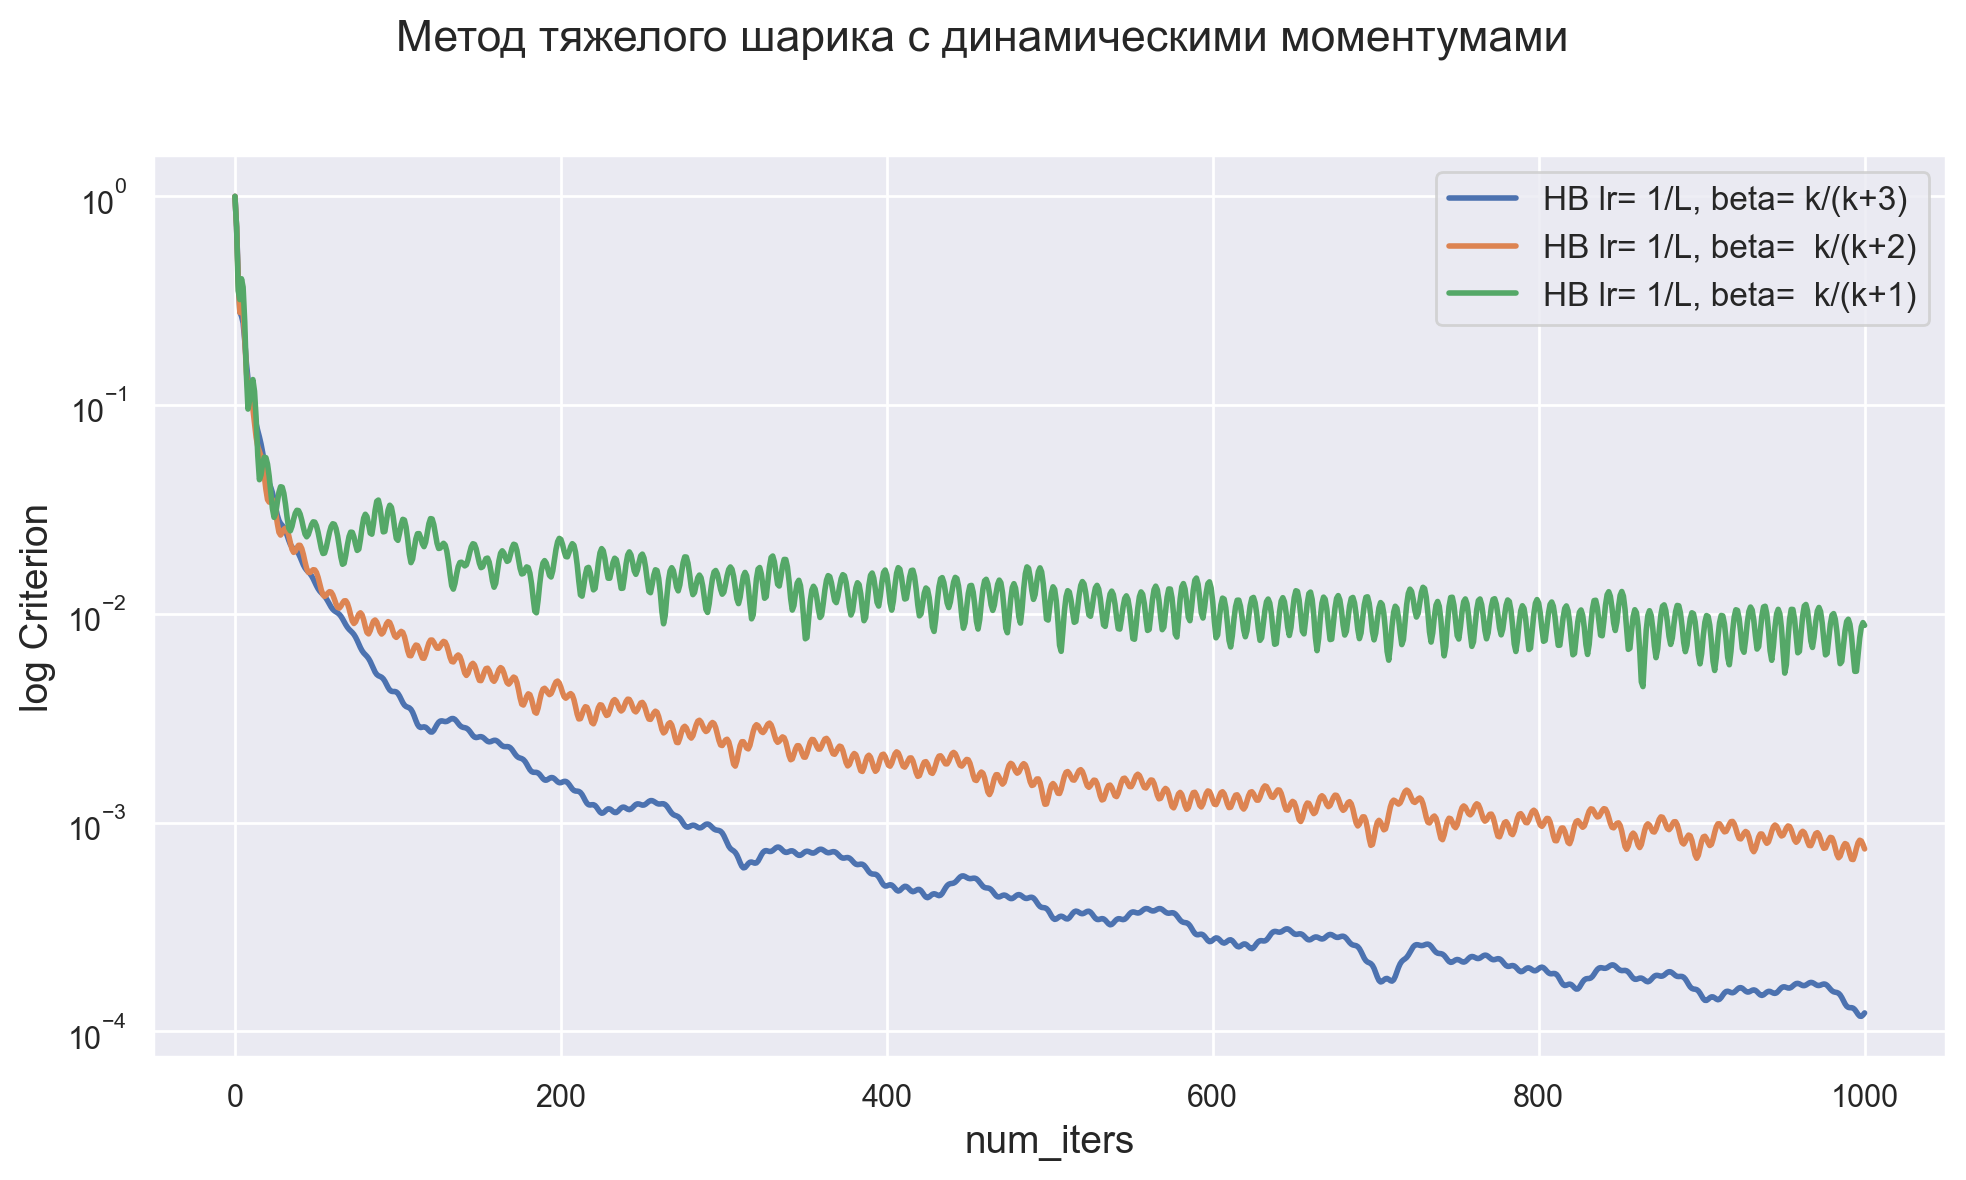

In [242]:
2.
def beta_k_s(s):
    # TODO: return a lambda function that depends on k
    return lambda k : k / (k + s)

hb_opt_1 = HeavyBall(lr=1/lipschitz_mush, beta=beta_k_s(3), init_w=start_w_mush, name="HB lr= 1/L, beta= k/(k+3)")
hb_res_1 = test_optimizer(hb_opt_1)

hb_opt_2 = HeavyBall(lr=1/lipschitz_mush, beta=beta_k_s(2), init_w=start_w_mush, name="HB lr= 1/L, beta=  k/(k+2)")
hb_res_2 = test_optimizer(hb_opt_2)

hb_opt_3 = HeavyBall(lr=1/lipschitz_mush, beta=beta_k_s(1), init_w=start_w_mush, name="HB lr= 1/L, beta=  k/(k+1)")
hb_res_3 = test_optimizer(hb_opt_3)

plot_results([hb_res_1, hb_res_2, hb_res_3], "Метод тяжелого шарика с динамическими моментумами")

HB lr= 1/L, beta= k/(k+3): 100%|██████████| 1000/1000 [00:05<00:00, 176.12it/s, Loss=0.0813, Accuracy=0.996, Grad norm=0.000123]


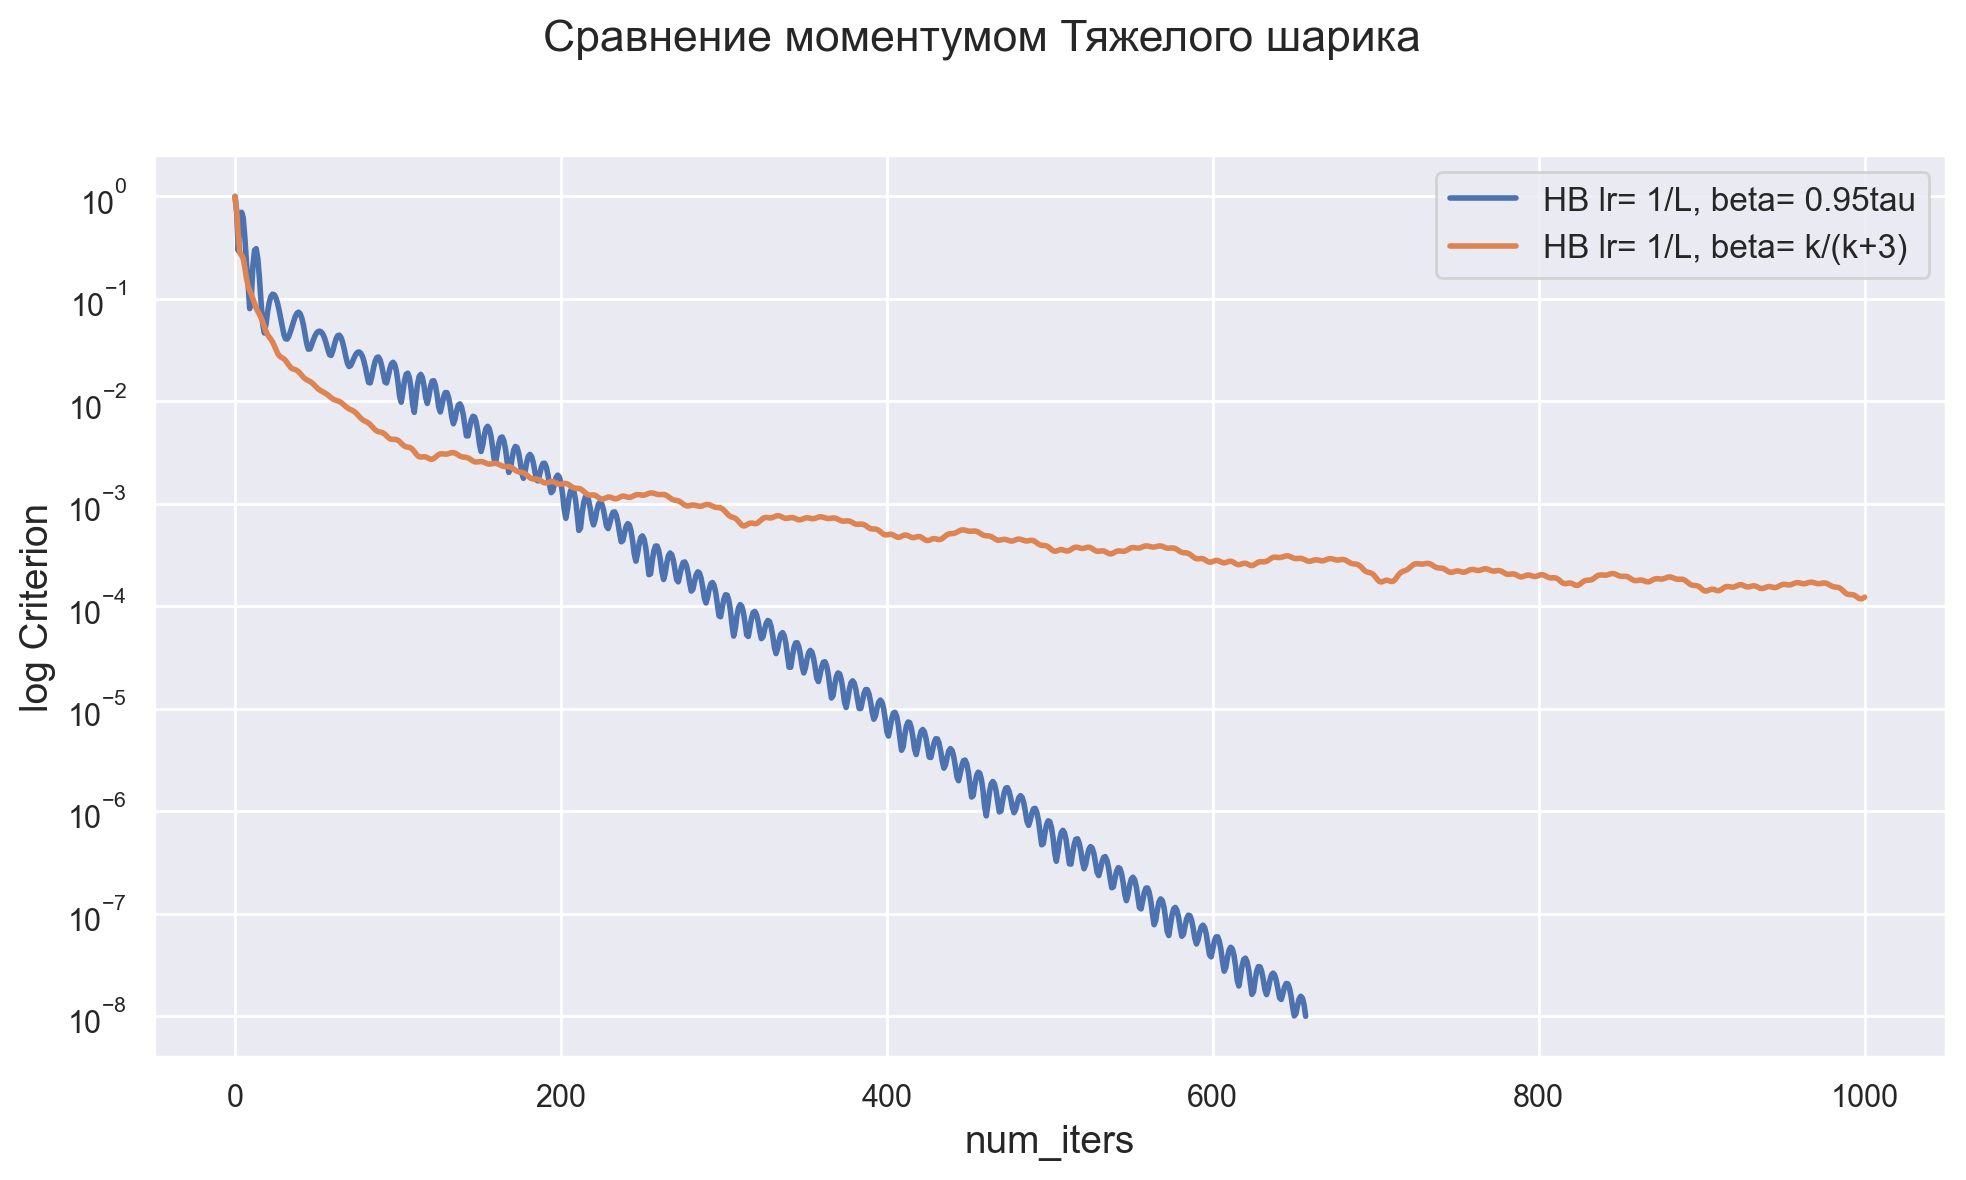

In [243]:
3.
hb_opt_fix = HeavyBall(lr=1/lipschitz_mush, beta=0.95*tau, init_w=start_w_mush, name="HB lr= 1/L, beta= 0.95tau")
hb_res_fix = test_optimizer(hb_opt_fix)

hb_opt_dynamic = HeavyBall(lr=1/lipschitz_mush, beta=beta_k_s(3), init_w=start_w_mush, name="HB lr= 1/L, beta= k/(k+3)")
hb_res_dynamic = test_optimizer(hb_opt_dynamic)

plot_results([hb_res_fix, hb_res_dynamic], "Сравнение моментумом Тяжелого шарика")

здесь видно насколько фиксированный моментум превосходит изменяющийся

In [244]:
best_final_hb_res = hb_res_fix

### Задача 4 (2 балла)

Рассмотрим ускоренный градиентный метод (Nesterov Accelerated Gradient)

$$
\begin{align*}
& w_{k+1} = y_k - \gamma_k \nabla \mathcal{L}(y_k) \\
& y_{k+1} = w_{k+1} + \tau_k (w_{k+1} - w_k)
\end{align*}
$$

- Реализуйте шаг ускоренного градиентного метода
- Используйте шаг $\gamma = \frac{1}{L}$.
1. Рассмотрите моментум  $\tau = \frac{\sqrt{L} - \sqrt{\mu}}{\sqrt{L} + \sqrt{\mu}}$ и несколько моментумов в его окрестности: $s \cdot \tau$, где $s \in [0.9, 1.1]$. Рассмотрите не менее 3-х окрестностей.
2. Рассмотрите моментумы равные  $\frac{k}{k+3}$, $\frac{k}{k+2}$, $\frac{k}{k+1}$ ($k$ — номер итерации).
3. Сравните полученные результаты.

In [250]:
class NAG(ManualSolver):
    def __init__(self, lr, beta, init_w, name) -> None:
        super().__init__(lr, name, False, False)
        self.beta = beta if isinstance(beta, Callable) else lambda _: beta
        self.w_prev = init_w
        self.y_prev = init_w

    def step(self, w: np.ndarray, k: int, grad_f: None, hess_f: None) -> np.ndarray:
        # TODO: implement NAG iteration step
        w_next = self.y_prev - self.lr(k) * mush_grad(self.y_prev)
        y_next = w_next + self.beta(k) * (w_next - w)

        self.w_prev = w_next
        self.y_prev = y_next
        return w_next

NAG lr= 1/L, beta= 0.99tau: 100%|██████████| 1000/1000 [00:04<00:00, 216.41it/s, Loss=0.0813, Accuracy=0.996, Grad norm=8.97e-5]


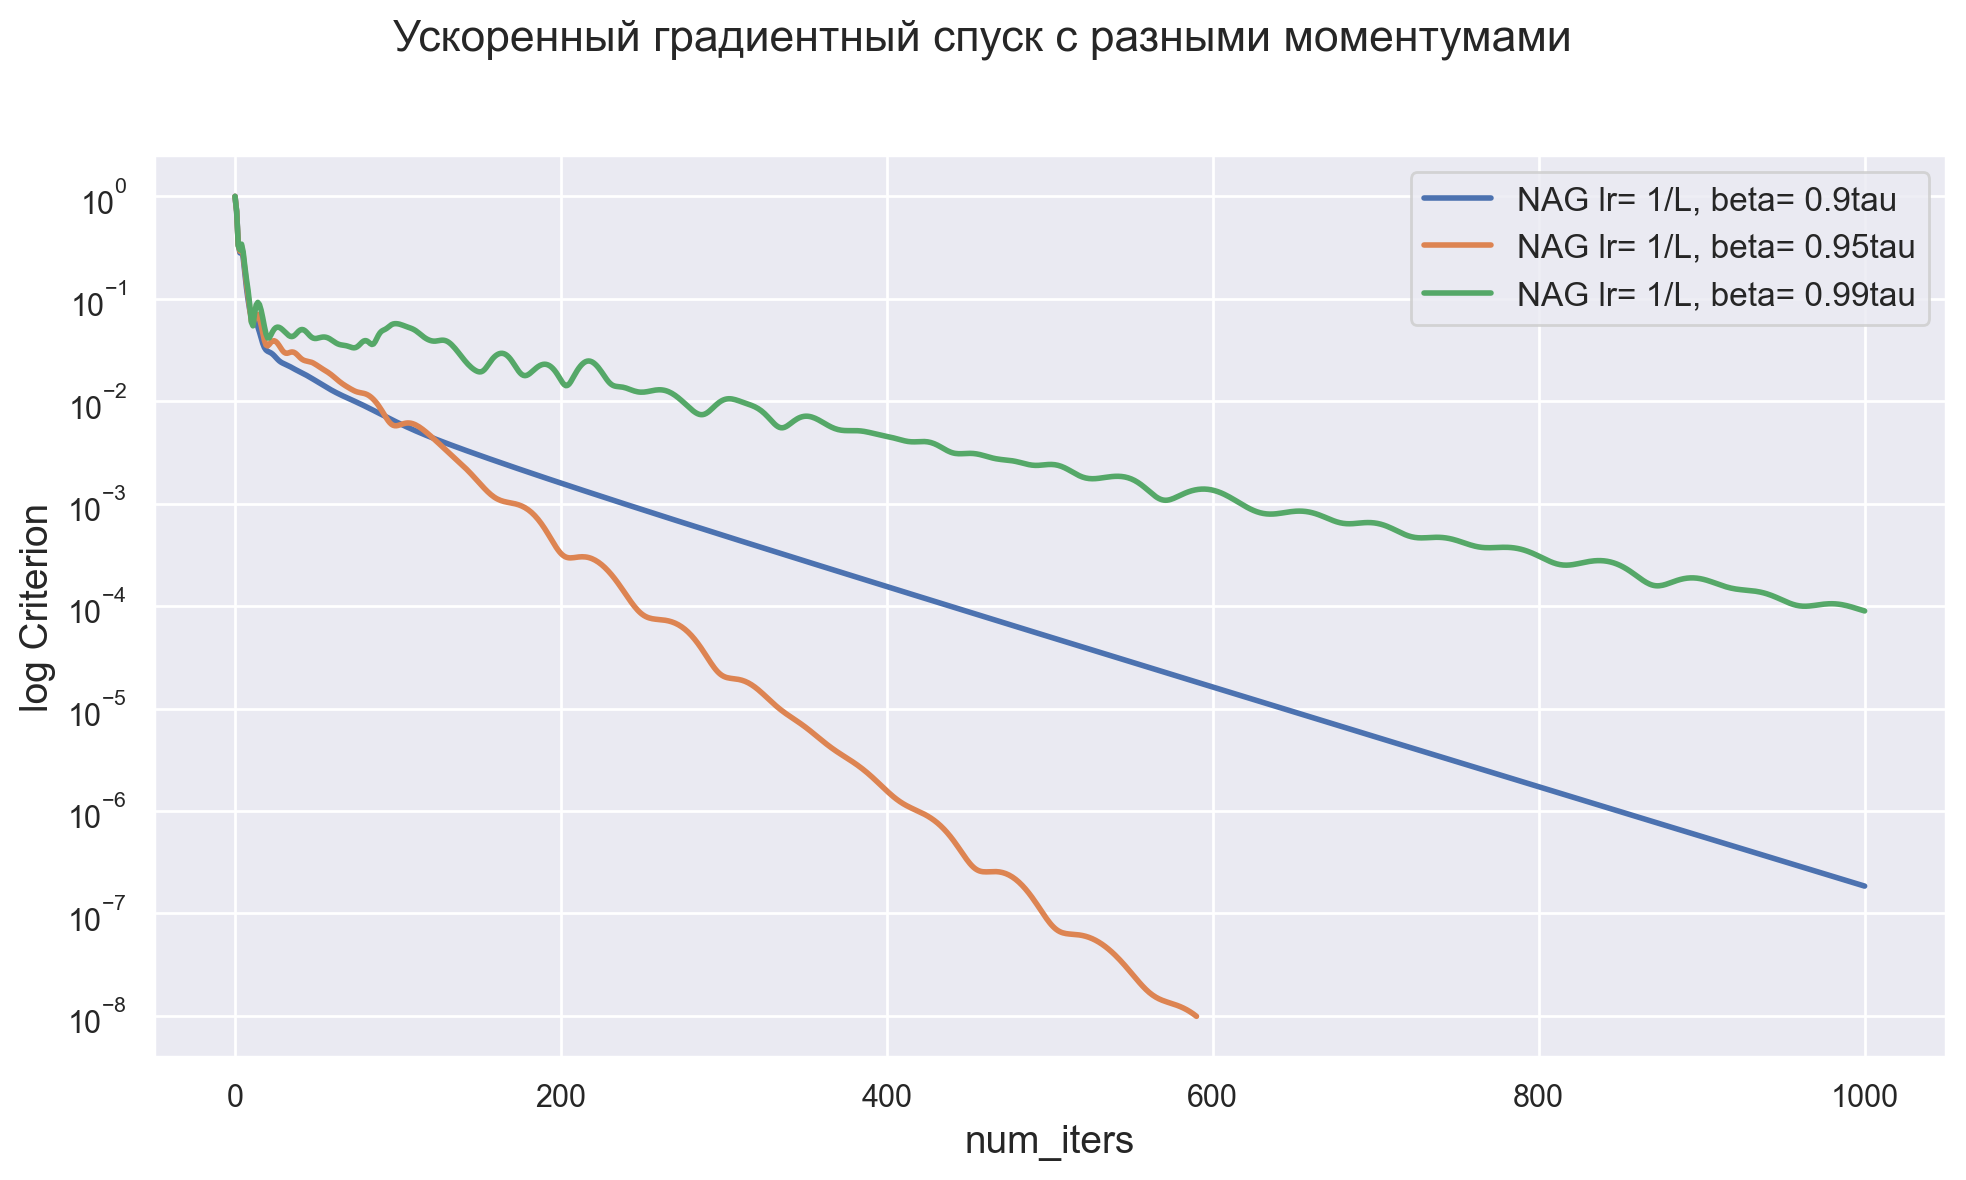

In [251]:
nag_opt_1 = NAG(lr=1/lipschitz_mush, beta=0.9*tau, init_w=start_w_mush, name="NAG lr= 1/L, beta= 0.9tau")
nag_res_1 = test_optimizer(nag_opt_1)

nag_opt_2 = NAG(lr=1/lipschitz_mush, beta=0.95*tau, init_w=start_w_mush, name="NAG lr= 1/L, beta= 0.95tau")
nag_res_2 = test_optimizer(nag_opt_2)

nag_opt_3 = NAG(lr=1/lipschitz_mush, beta=0.99*tau, init_w=start_w_mush, name="NAG lr= 1/L, beta= 0.99tau")
nag_res_3 = test_optimizer(nag_opt_3)

plot_results([nag_res_1, nag_res_2, nag_res_3], "Ускоренный градиентный спуск с разными моментумами")

NAG lr= 1/L, beta=  k/(k+1): 100%|██████████| 1000/1000 [00:07<00:00, 134.04it/s, Loss=0.0816, Accuracy=0.996, Grad norm=0.0012] 


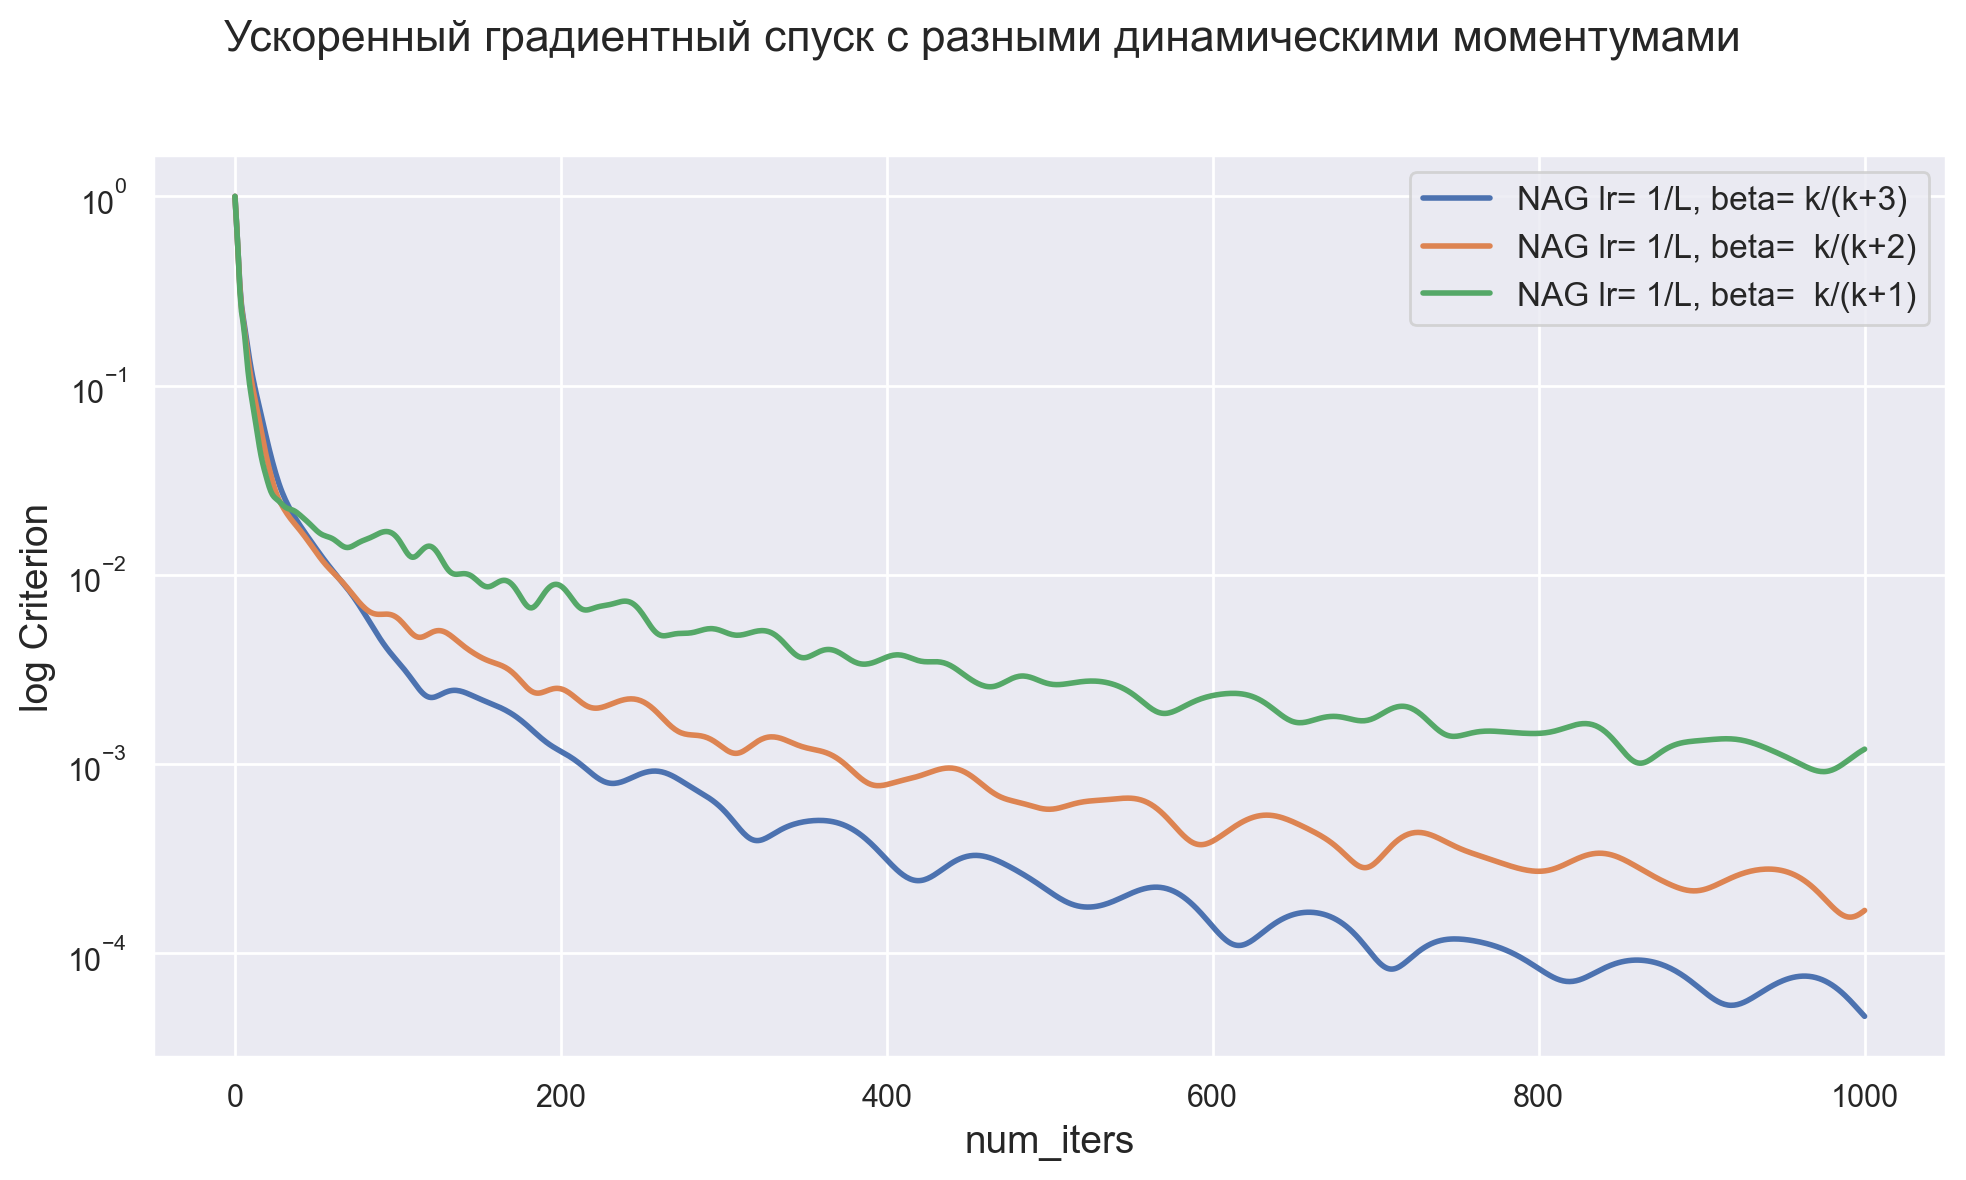

In [279]:
2.
def beta_k_s(s):
    # TODO: return a lambda function that depends on k
    return lambda k : k / (k + s)

nag_opt_1 = NAG(lr=1/lipschitz_mush, beta=beta_k_s(3), init_w=start_w_mush, name="NAG lr= 1/L, beta= k/(k+3)")
nag_res_1 = test_optimizer(nag_opt_1)

nag_opt_2 = NAG(lr=1/lipschitz_mush, beta=beta_k_s(2), init_w=start_w_mush, name="NAG lr= 1/L, beta=  k/(k+2)")
nag_res_2 = test_optimizer(nag_opt_2)

nag_opt_3 = NAG(lr=1/lipschitz_mush, beta=beta_k_s(1), init_w=start_w_mush, name="NAG lr= 1/L, beta=  k/(k+1)")
nag_res_3 = test_optimizer(nag_opt_3)

plot_results([nag_res_1, nag_res_2, nag_res_3], "Ускоренный градиентный спуск с разными динамическими моментумами")

NAG lr= 1/L, beta= k/(k+3): 100%|██████████| 1000/1000 [00:04<00:00, 236.72it/s, Loss=0.0813, Accuracy=0.996, Grad norm=4.64e-5]


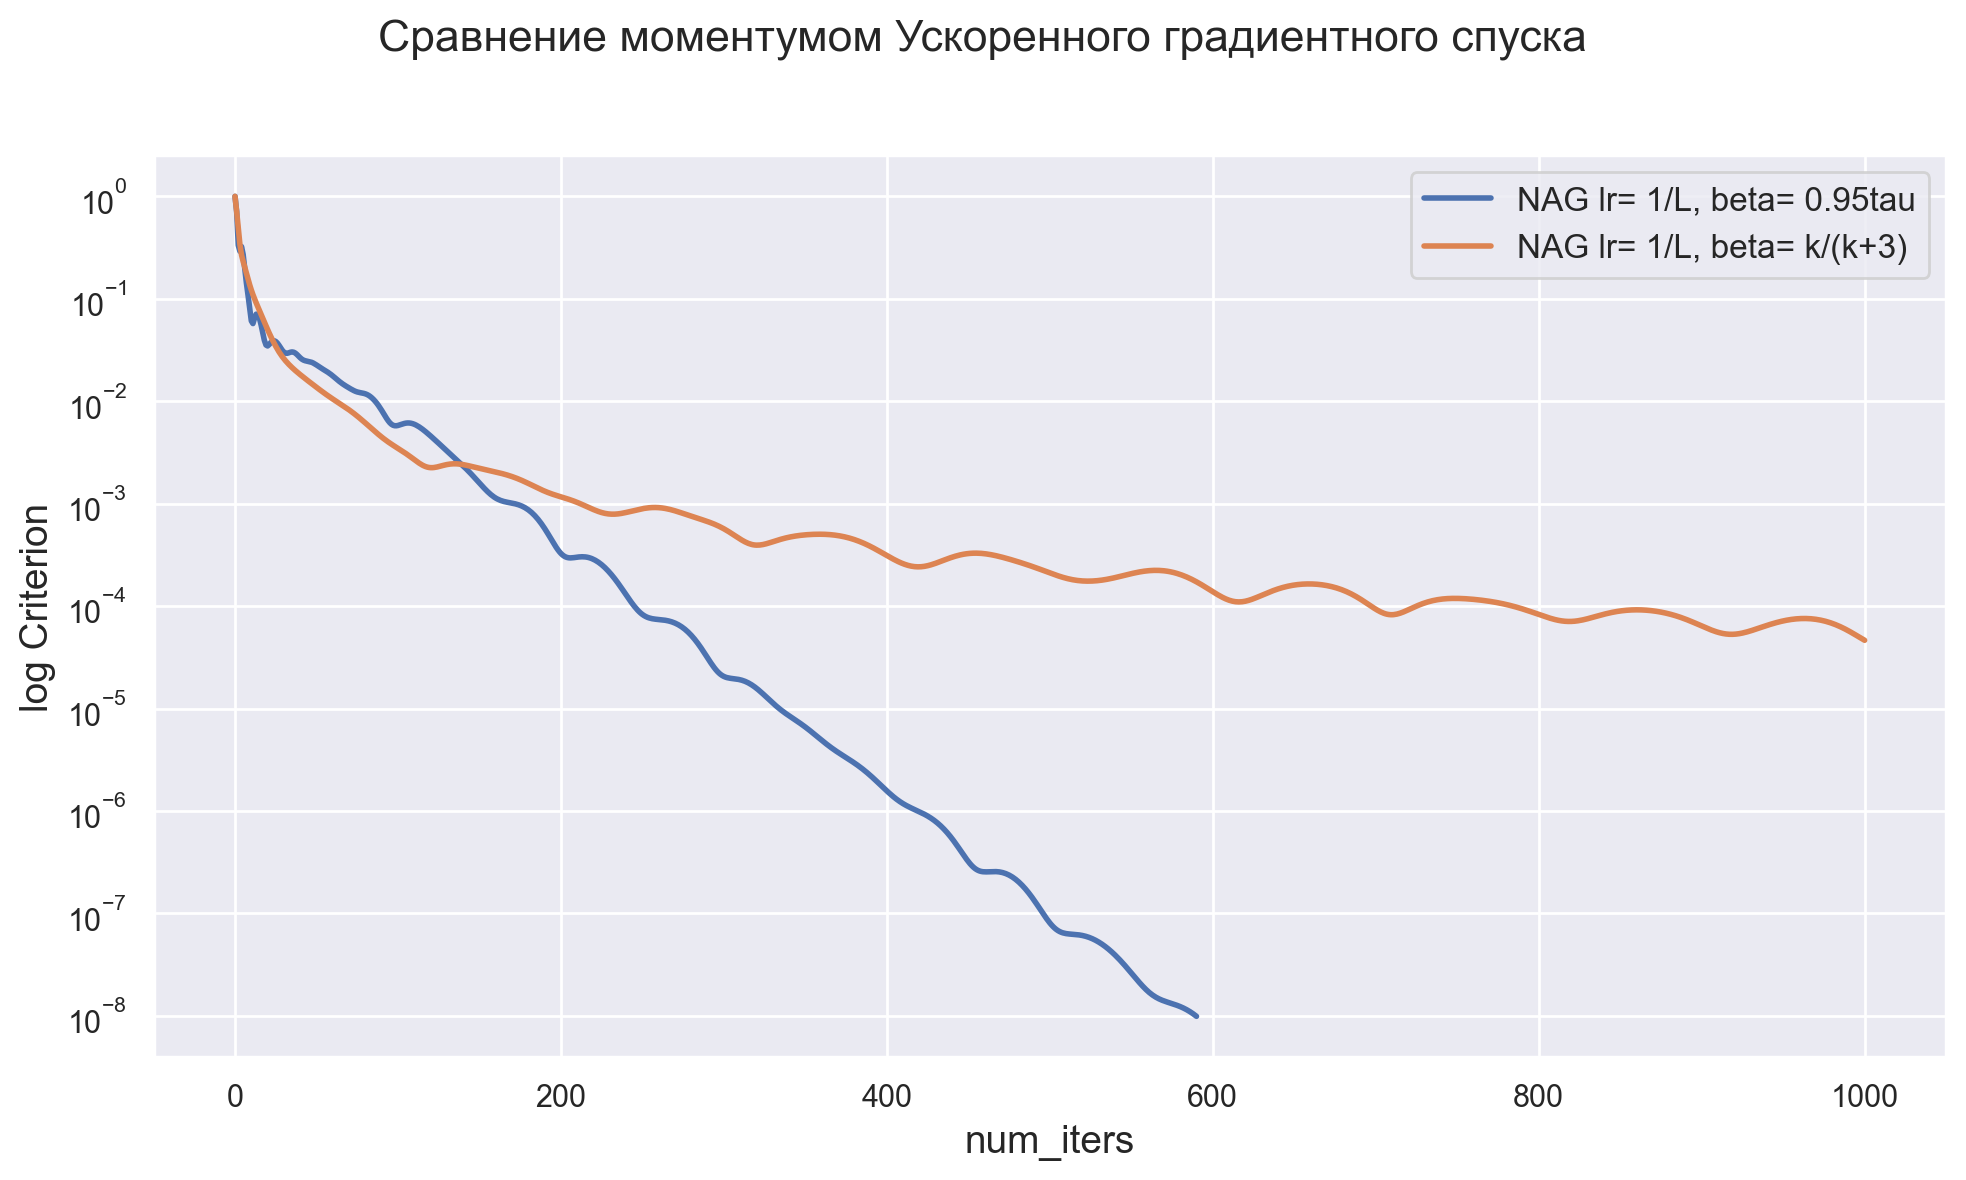

In [280]:
3.
nag_opt_fix = NAG(lr=1/lipschitz_mush, beta=0.95*tau, init_w=start_w_mush, name="NAG lr= 1/L, beta= 0.95tau")
nag_res_fix = test_optimizer(nag_opt_fix)

nag_opt_dynamic = NAG(lr=1/lipschitz_mush, beta=beta_k_s(3), init_w=start_w_mush, name="NAG lr= 1/L, beta= k/(k+3)")
nag_res_dynamic = test_optimizer(nag_opt_dynamic)

plot_results([nag_res_fix, nag_res_dynamic], "Сравнение моментумом Ускоренного градиентного спуска")

Ускоренный градиентный спуск работает еще быстрее 

In [281]:
best_final_nag_res = nag_res_fix

### Задача 5 (1 балла)

Рассмотрим один из самых известных методов второго порядка - Метод Ньютона (Newton's method):

$$
w_{k+1} = w_k - \nabla^2\mathcal{L}(w^k)^{-1} \nabla \mathcal{L}(w^k)
$$

А точнее, его модификацию - демпфированный метод Ньютона (Dumped Newton's method):

$$
w_{k+1} = w_k - \gamma_k \nabla^2\mathcal{L}(w^k)^{-1} \nabla \mathcal{L}(w^k)
$$

- Реализуйте шаг демпфированного метода Ньютона
1.  Протестируйте различные $\gamma_k = \gamma = \frac{s}{L}$, где $s \in [0.5, 1.5]$, $L$ - константа липшица в задаче. Рассмотрите не менее 3-х $s$.
2. Сравните полученные результаты.

In [260]:
class Newton(ManualSolver):
    def __init__(self, lr, name) -> None:
        super().__init__(lr, name, True, True)

    def step(self, w: np.ndarray, k: int, grad_f: np.ndarray, hess_f: np.ndarray) -> np.ndarray:
        # TODO: implement Newton iteration step

        return w - self.lr(k) * (np.linalg.inv(hess_f) @ grad_f)

Newton lr= 1.5 / L:   7%|▋         | 7/100 [00:01<00:15,  6.15it/s, Loss=209, Accuracy=0.519, Grad norm=1.46]  /var/folders/5d/bsm3kt3d4qdc55zn6zggxf800000gq/T/ipykernel_38544/1863604594.py:4: RuntimeWarning: overflow encountered in exp
  return np.exp(M)
Newton lr= 1.5 / L: 100%|██████████| 100/100 [00:16<00:00,  5.90it/s, Loss=276, Accuracy=0.481, Grad norm=1.62]


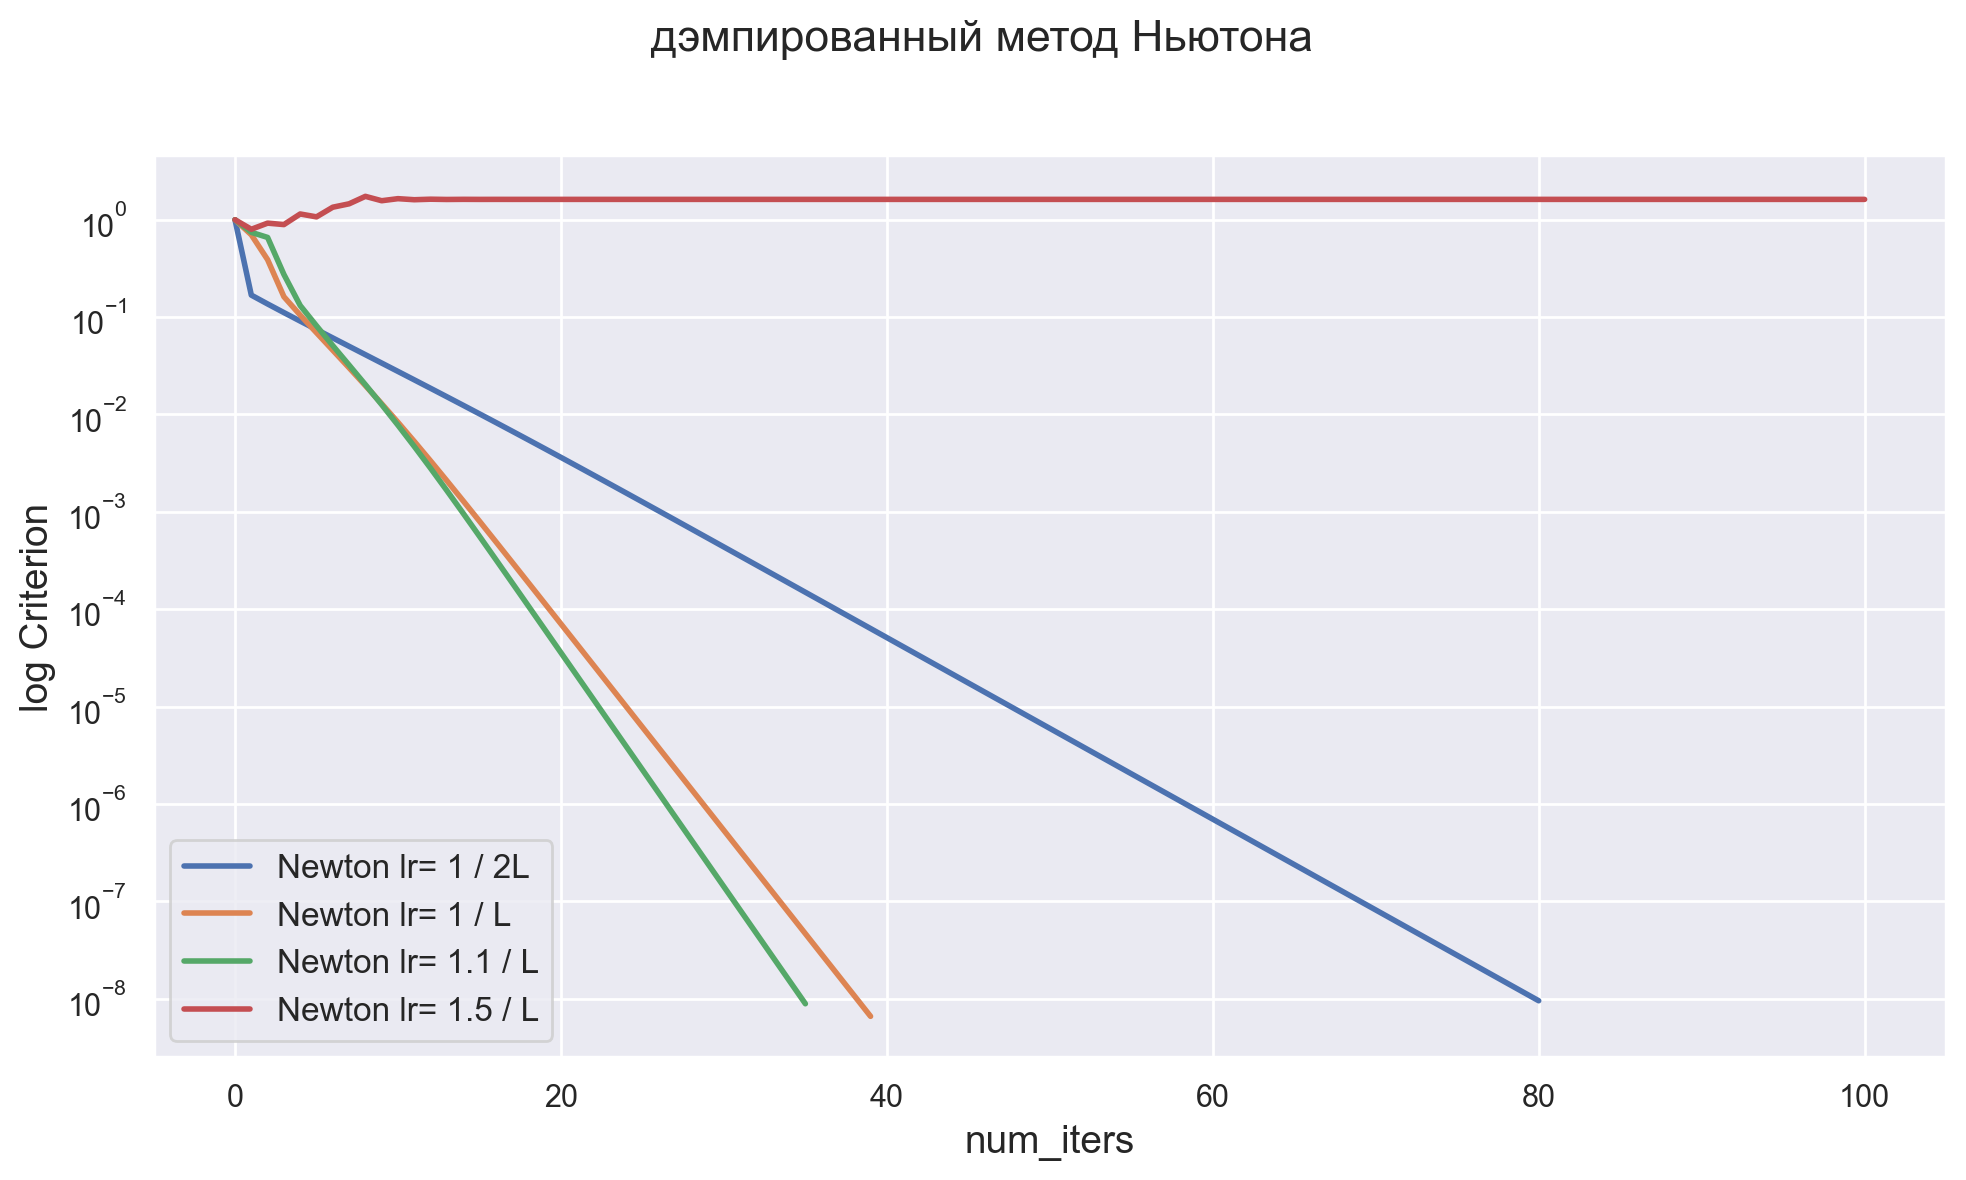

In [ ]:
1.
Newton_opt_1 = Newton(lr=0.5 / lipschitz_mush, name="Newton lr= 1 / 2L")
Newton_res_1 = test_optimizer(Newton_opt_1, max_iters=100)

Newton_opt_2 = Newton(lr=1 / lipschitz_mush, name="Newton lr= 1 / L")
Newton_res_2 = test_optimizer(Newton_opt_2, max_iters=100)

Newton_opt_3 = Newton(lr=1.1 / lipschitz_mush, name="Newton lr= 1.1 / L")
Newton_res_3 = test_optimizer(Newton_opt_3, max_iters=100)

Newton_opt_4 = Newton(lr=1.5 / lipschitz_mush, name="Newton lr= 1.5 / L")
Newton_res_4 = test_optimizer(Newton_opt_4, max_iters=100)

plot_results([Newton_res_1, Newton_res_2, Newton_res_3, Newton_res_4], "дэмпированный метод Ньютона")

In [276]:
best_final_newton_res = Newton_res_3

### Сравнение лучших реализаций

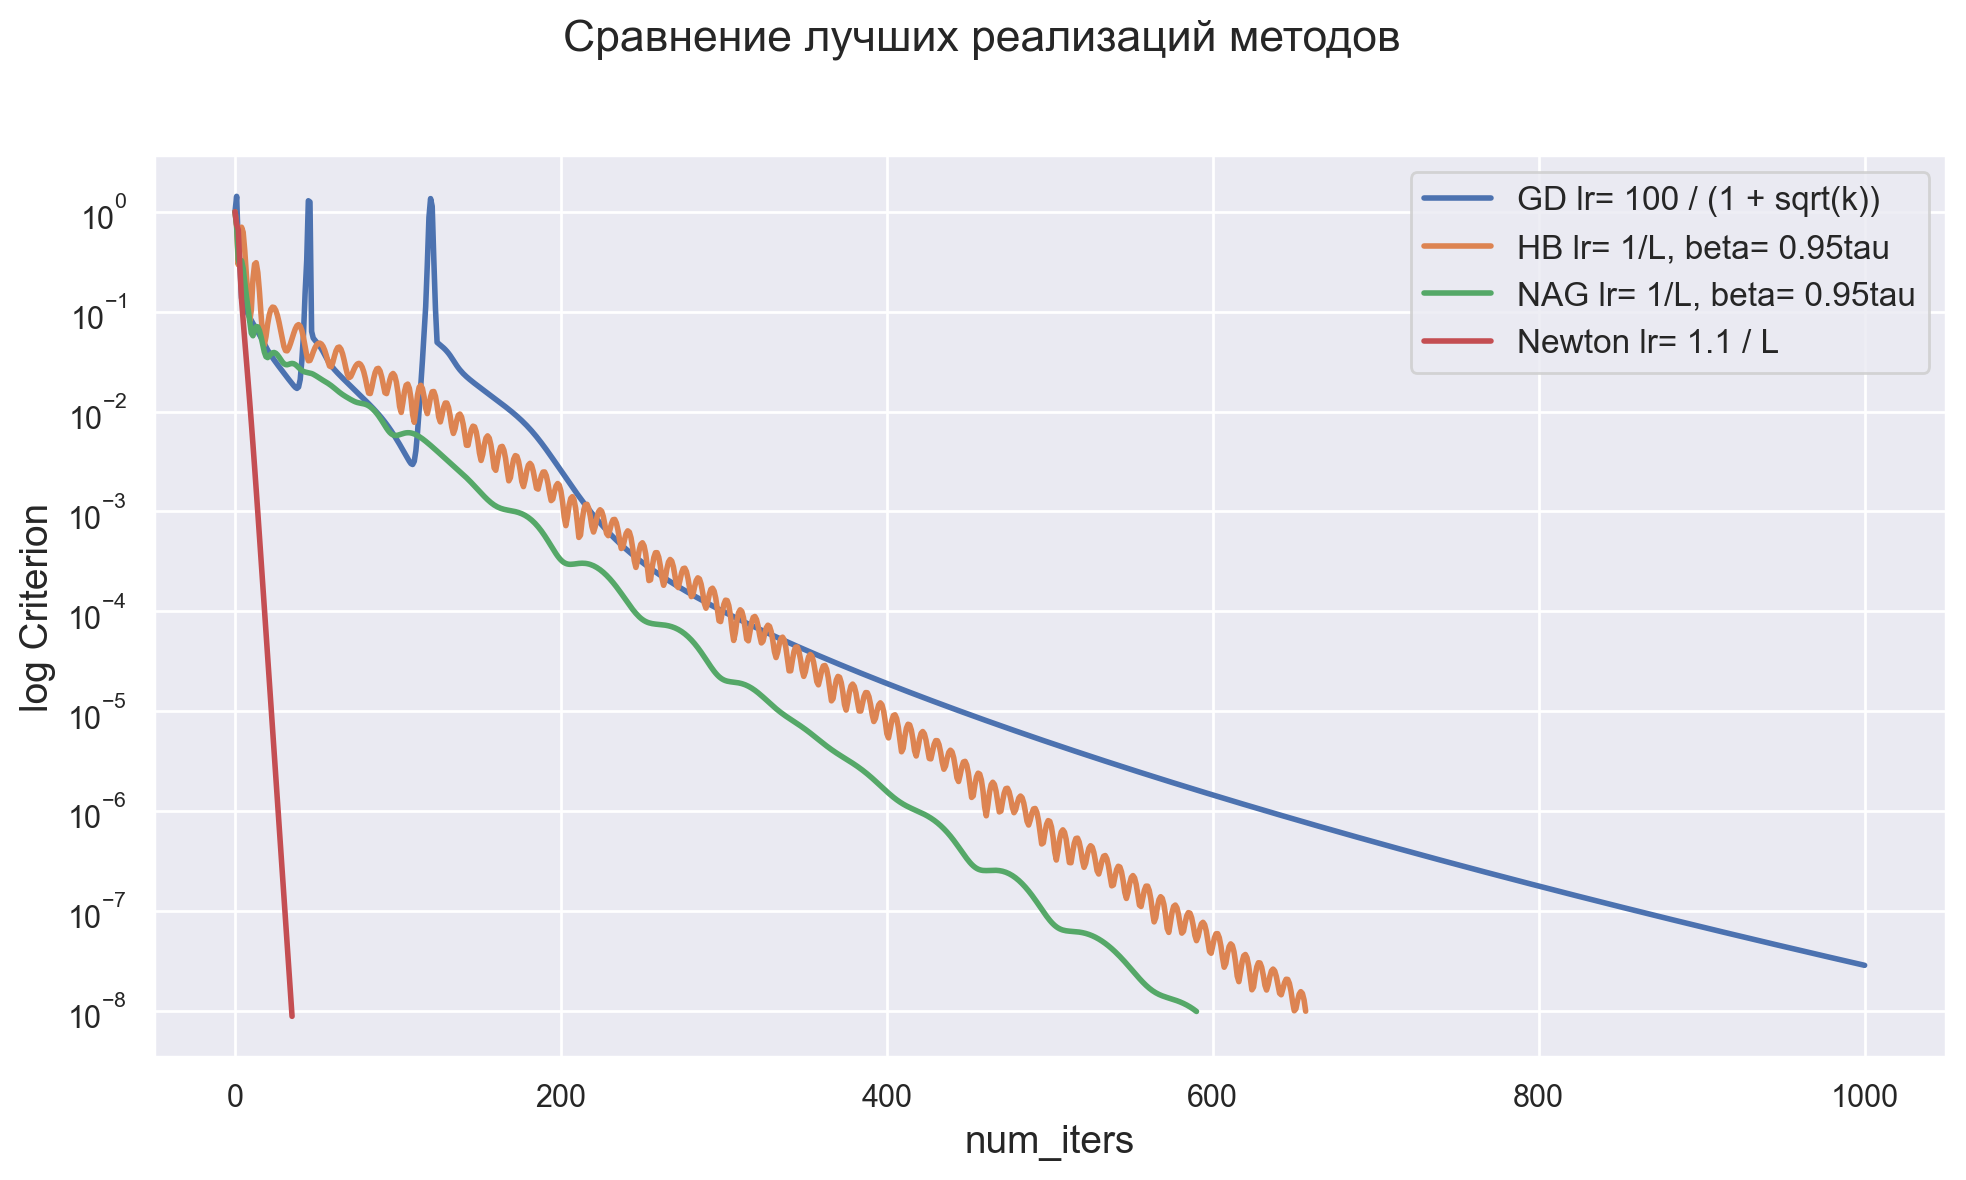

In [282]:
final_results = [best_final_gd_res, best_final_hb_res, best_final_nag_res, best_final_newton_res]
plot_results(final_results, 'Сравнение лучших реализаций методов', metrics_type=['Criterion'])

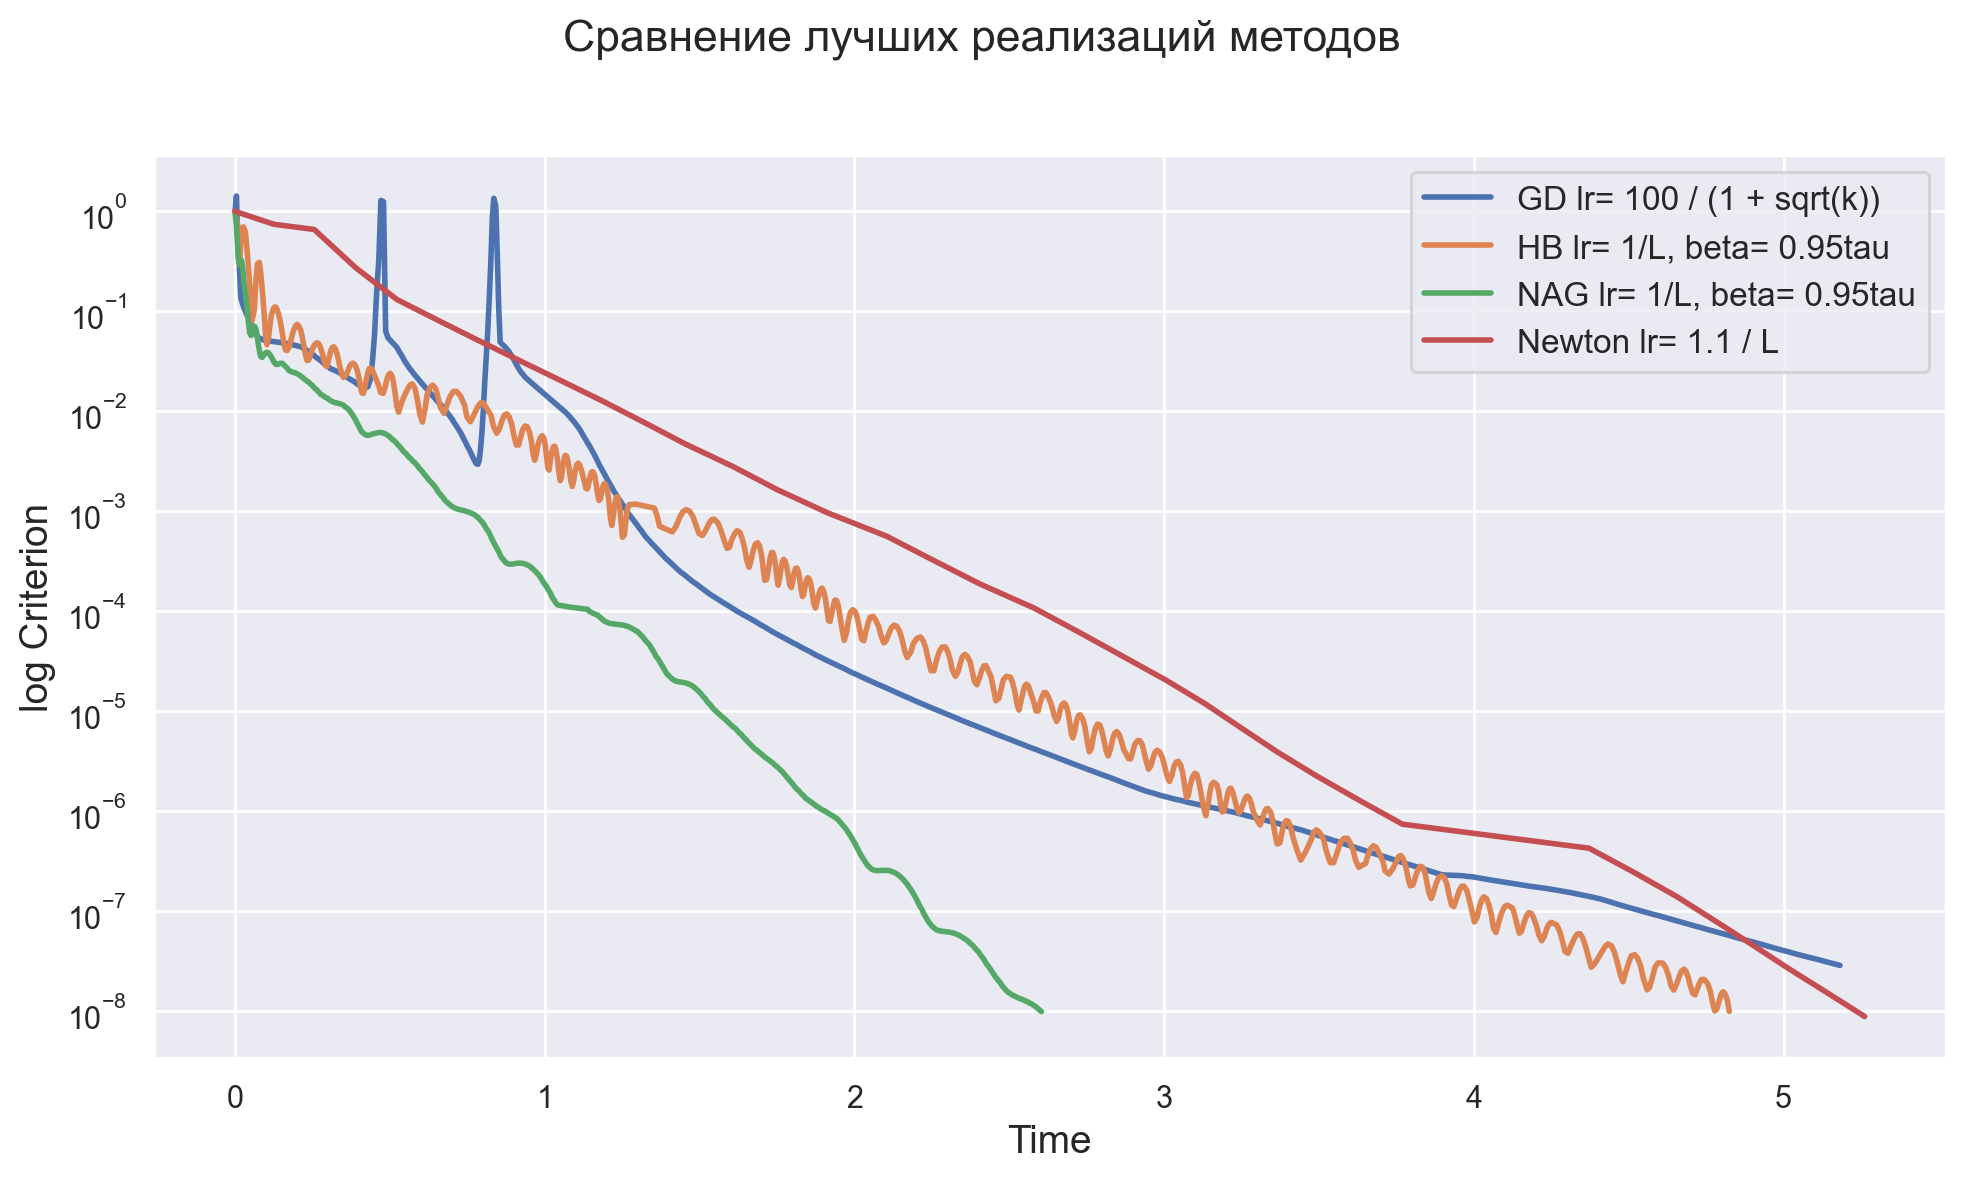

In [283]:
final_results = [best_final_gd_res, best_final_hb_res, best_final_nag_res, best_final_newton_res]
plot_results(final_results, 'Сравнение лучших реализаций методов', metrics_type=['Criterion'], x='Time')

конечно метод Ньютона использовал меньшее количество итерации, но лучше всех отработал Ускоренный метод Нестерова

### Ваши выводы (до 0.5 баллов):

1. Почему предложено выбирать $\gamma = \frac{s}{L}$, $\tau = \frac{\sqrt{L} - \sqrt{\mu}}{\sqrt{L} + \sqrt{\mu}}$?
2. Почему наблюдаются различия в графиках по количеству итераций и по времени?
3. Любые другие рассуждения приветствуются.

1. Для данных гиперпараметров доказано сходимость методов, регулирую $s$ в шаге метода, мы можем ускорить сходимость метода

2. Различия возникают из за разницы выполнения одной итерации метода, например в методе Ньютона требуется огромное количество времени чтобы обратить матрицу, но зато метод теоретический должен сходится за одну итерацию (ну или по крайней мере за пару)

3. Иногда методы Нестеров и тяжелого шарика дают одинаковые результаты, но обычно метод Нестерова более стабилен

### Задача 6* (1 балл)

Метод проксимального градиентного спуска используется для оптимизации композитной функции потерь
$$
h(w) = f(w) + g(w),
$$
где $f(w)$ является выпуклой дифференцируемой функцией на своей области определения. Особенностью является то, что $g(w)$ не обязательно должна быть дифференцируема всюду на своём множестве определения.  

Мы решаем задачу вида
$$
\min_{w\in \mathbb{R}^d}\{f(w) + R(w)\},
$$
где $R(w)$ - выпуклый (возможно негладкий) регуляризатор.

Обновление параметров осуществляется по схеме
$$
w_{k+1} = prox_{\gamma R}(w_k - \gamma\nabla f(w)),
$$
где проксимальный оператор определяется как
$$
prox_{\gamma R}(v) = \arg\min_{w\in \mathbb{R}^d}\left\{\dfrac{1}{2\gamma}\|w - v\|^2 + R(w) \right\}.
$$

* Реализуйте шаг проксимального градиентного спуска для различных видов $R(w)$ (L1, L2-регуляризация).
1. Протестируйте различные $\gamma_k = \gamma = \frac{s}{L}$, где $L$ определяется согласно $R(w)$.
2. Сравните полученные результаты.

In [ ]:
1.
# YOUR CODE HERE:
###########################
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
###########################

In [ ]:
2.
# YOUR CODE HERE:
###########################
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
###########################

## Задание 3: Предсказание погоды в Австралии

Датасет содержит ежедневные наблюдения погоды в различных регионах Австралии за период в 10 лет.

Предсказываемым признаком является `RainTomorrow`: "Будет ли завтра дождь?". Это задача бинарной классификации.

Скачиваем датасет

In [514]:
import pandas as pd
import seaborn as sns

In [515]:
url = 'https://huggingface.co/Anm5/rainpred/resolve/main/weatherAUS.csv'
filename = 'weatherAUS.csv'

response = requests.get(url)
with open(filename, 'wb') as file:
    file.write(response.content)
df = pd.read_csv(filename)
df.head(5)

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


### Задача 1 (3 балла): Анализ датасета

Датасет представляет собой табличные данные. В этом задании вы убедитесь, что основной объём работы в классификации таких данных с помощью методов машинного обучения состоит в анализе датасета и его признаков.

Давайте выведем общую информацию о признаках в датасете

In [516]:
df.info()
print(f"Number of NaN targets: {df['RainTomorrow'].isnull().sum()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

Можно заметить, что для некоторых примеров в датасете отсутствует разметка. Поскольку мы решаем задачу классификации с учителем, эти примеры нас не интересуют.

**Удалите из датасета сэмплы с отсутствующим значением `RainTomorrow`**.

In [517]:
df = df[~df["RainTomorrow"].isnull()]

Выделим категориальные переменные

In [518]:
categorical = [var for var in df.columns if df[var].dtype=='O']
print('The categorical variables are :', categorical)
for feature in categorical:
    print(f"Number of unique {feature}:", df[feature].nunique())

The categorical variables are : ['Date', 'Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday', 'RainTomorrow']
Number of unique Date: 3436
Number of unique Location: 49
Number of unique WindGustDir: 16
Number of unique WindDir9am: 16
Number of unique WindDir3pm: 16
Number of unique RainToday: 2
Number of unique RainTomorrow: 2


`RainTomorrow` является целевым признаком. `RainToday` нетрудно бинаризовать. Остальные признаки содержат большое количество значений.

В первом приближении, удалим признаки кроме `RainTomorrow`, `RainToday`.

**Важно:** датасет без категориальных признаков необходимо записать в отдельную переменную `df_numerical`. Исходный набор `df` пригодится в дополнительном задании.

**Бинаризуйте признаки `RainTomorrow`, `RainToday`. Остальные удалите**

In [519]:
numerical = list(set(df.columns) - set(categorical))

In [520]:
df_numerical = df[numerical]
df_numerical["RainTomorrow"] = df["RainTomorrow"].apply(lambda x : 1 if x=="Yes" else 0)
df_numerical["RainToday"] = df["RainToday"].apply(lambda x : 1 if x=="Yes" else 0)

/var/folders/5d/bsm3kt3d4qdc55zn6zggxf800000gq/T/ipykernel_38544/565657143.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_numerical["RainTomorrow"] = df["RainTomorrow"].apply(lambda x : 1 if x=="Yes" else 0)
/var/folders/5d/bsm3kt3d4qdc55zn6zggxf800000gq/T/ipykernel_38544/565657143.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_numerical["RainToday"] = df["RainToday"].apply(lambda x : 1 if x=="Yes" else 0)


Перейдём к численным признакам

In [521]:
numerical = [var for var in df.columns if df[var].dtype!='O']
round(df_numerical[numerical].describe(), 2)

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,141556.00,141871.00,140787.00,81350.00,74377.00,132923.00,140845.00,139563.00,140419.00,138583.00,128179.00,128212.00,88536.00,85099.00,141289.00,139467.00
mean,12.19,23.23,2.35,5.47,7.62,39.98,14.00,18.64,68.84,51.48,1017.65,1015.26,4.44,4.50,16.99,21.69
std,6.40,7.12,8.47,4.19,3.78,13.59,8.89,8.80,19.05,20.80,7.11,7.04,2.89,2.72,6.49,6.94
min,-8.50,-4.80,0.00,0.00,0.00,6.00,0.00,0.00,0.00,0.00,980.50,977.10,0.00,0.00,-7.20,-5.40
25%,7.60,17.90,0.00,2.60,4.90,31.00,7.00,13.00,57.00,37.00,1012.90,1010.40,1.00,2.00,12.30,16.60
50%,12.00,22.60,0.00,4.80,8.50,39.00,13.00,19.00,70.00,52.00,1017.60,1015.20,5.00,5.00,16.70,21.10
75%,16.80,28.20,0.80,7.40,10.60,48.00,19.00,24.00,83.00,66.00,1022.40,1020.00,7.00,7.00,21.60,26.40
max,33.90,48.10,371.00,145.00,14.50,135.00,130.00,87.00,100.00,100.00,1041.00,1039.60,9.00,9.00,40.20,46.70


Одним из важных аспектов обработки численных признаков является *опеределение выбросов (англ. outliers)*. С одной стороны, выбросы можно выделить для всех признаков. Однако, бывает полезно изучить, для каких фичей они более характерны. Это позволит избежать потери важной информации.

**Вам необходимо определить, для каких из численных признаков имеет смысл выделять выбросы.**

**Примечание:** Это можно сделать с помощью графика гистограммы. Отрисуйте зависимости всех числовых признаков от целевого `RainTomorrow`. По оси x отложите значения признака, по оси y - плотность `RainTomorrow` (в результате на рисунке будут 2 графика для каждого из бинарных значений). Для этого воспользуйтесь функцией `seaborn.histplot` с аргументом `stat='density'`. По виду графика можно интерпретировать, для каких признаков существуют значительные выбросы.

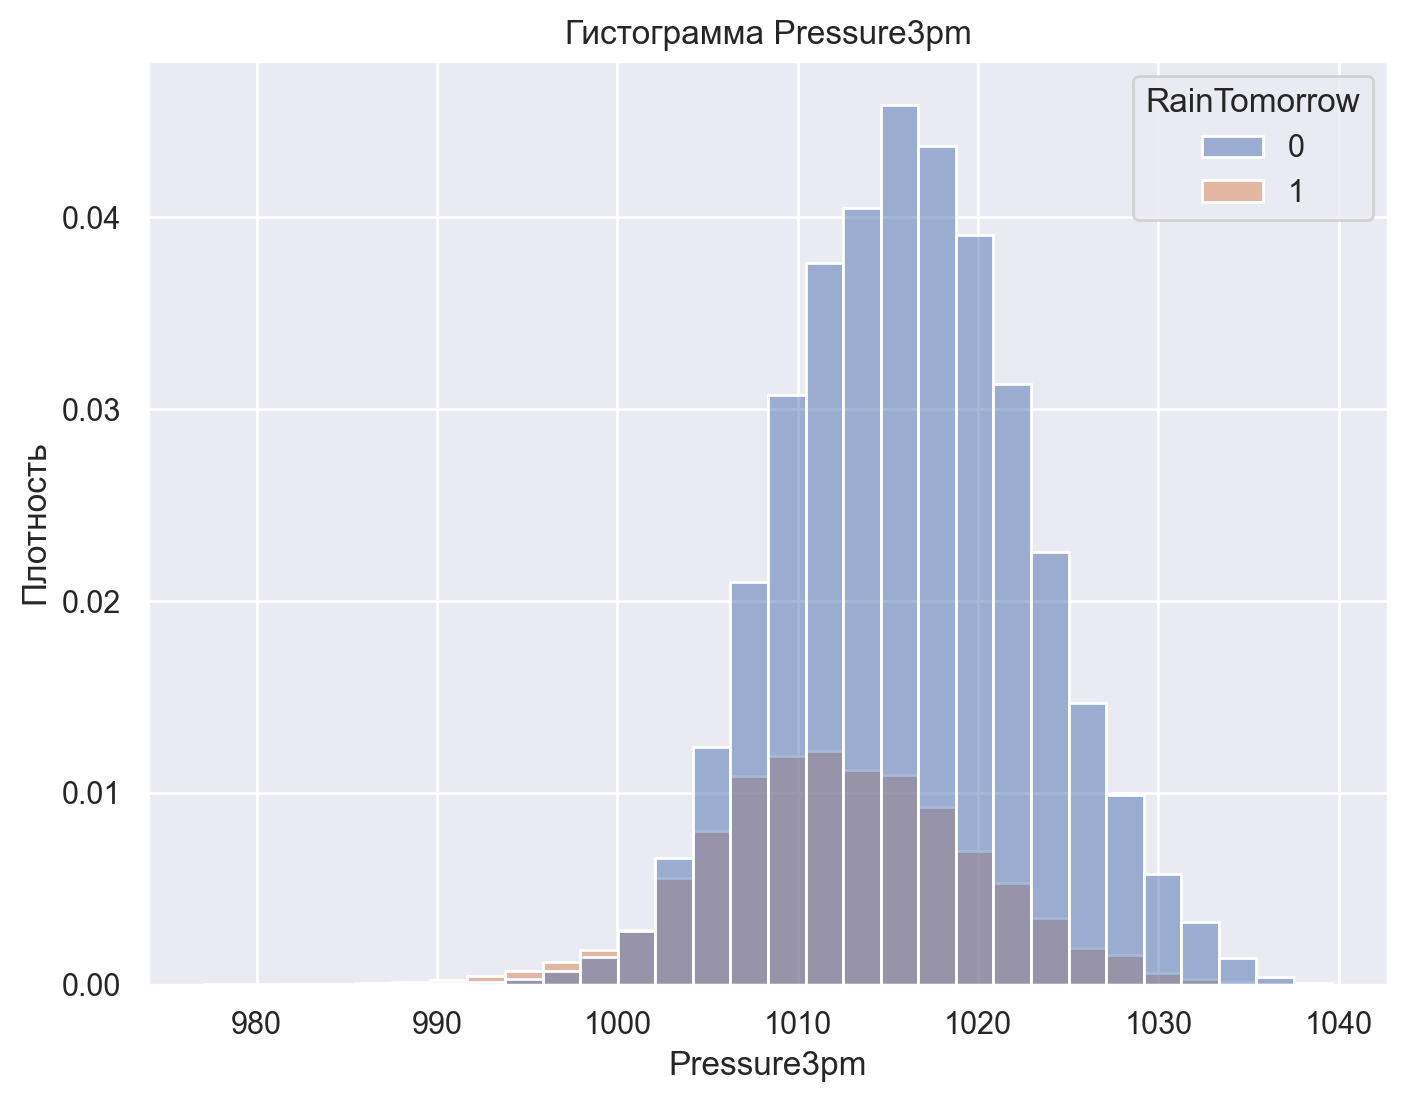

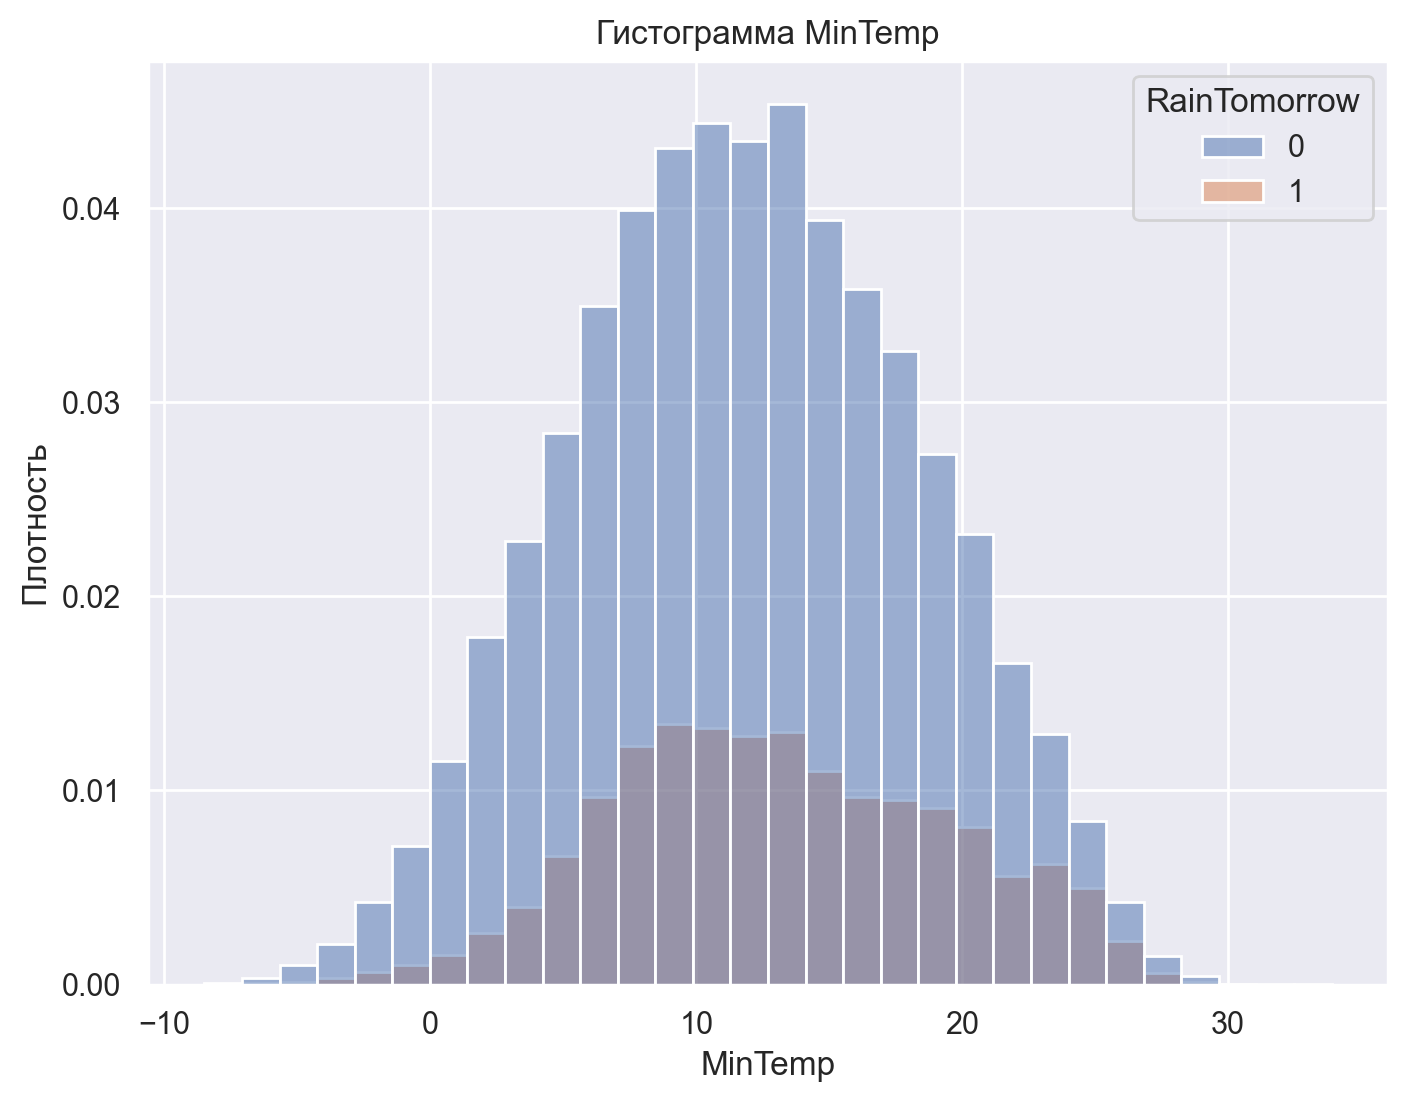

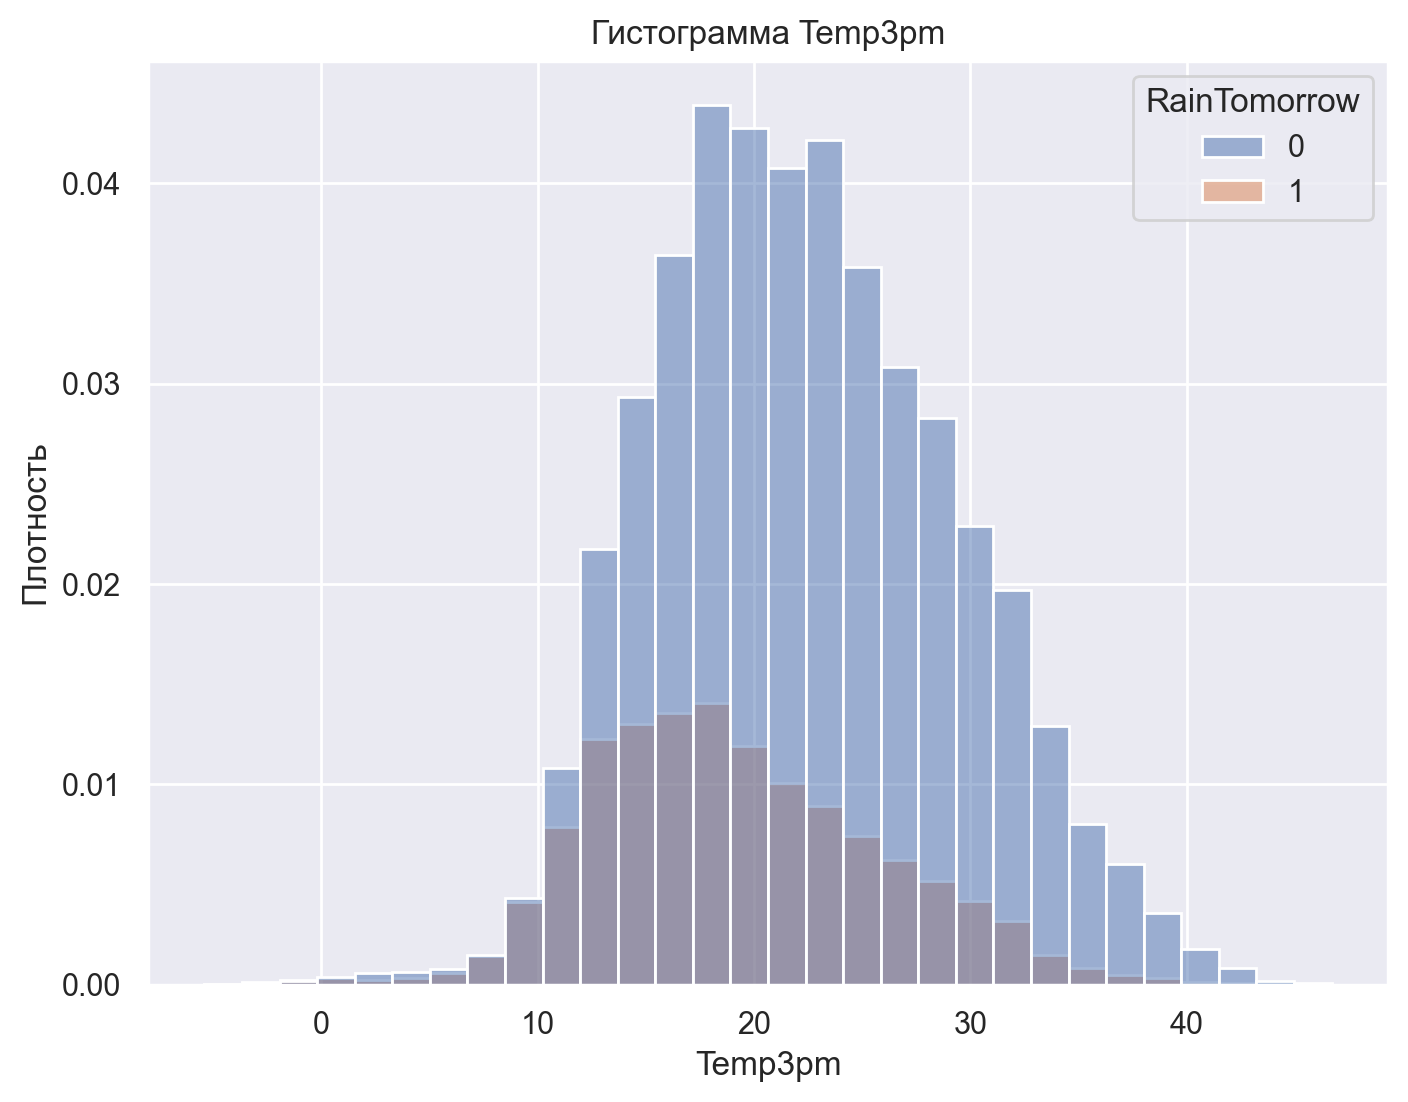

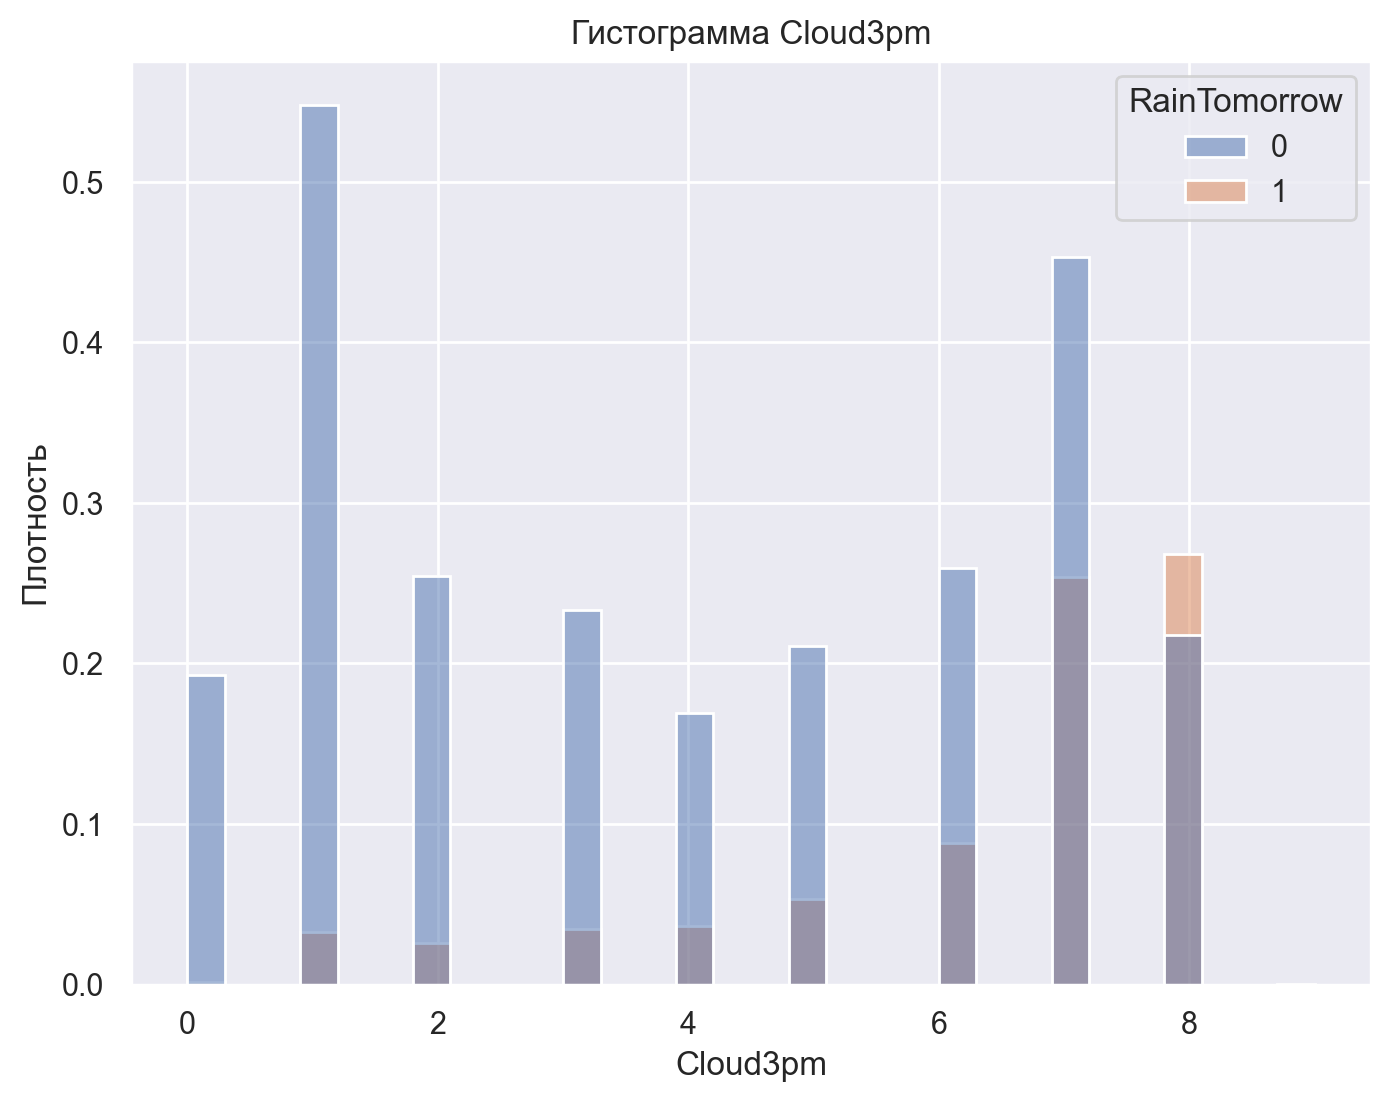

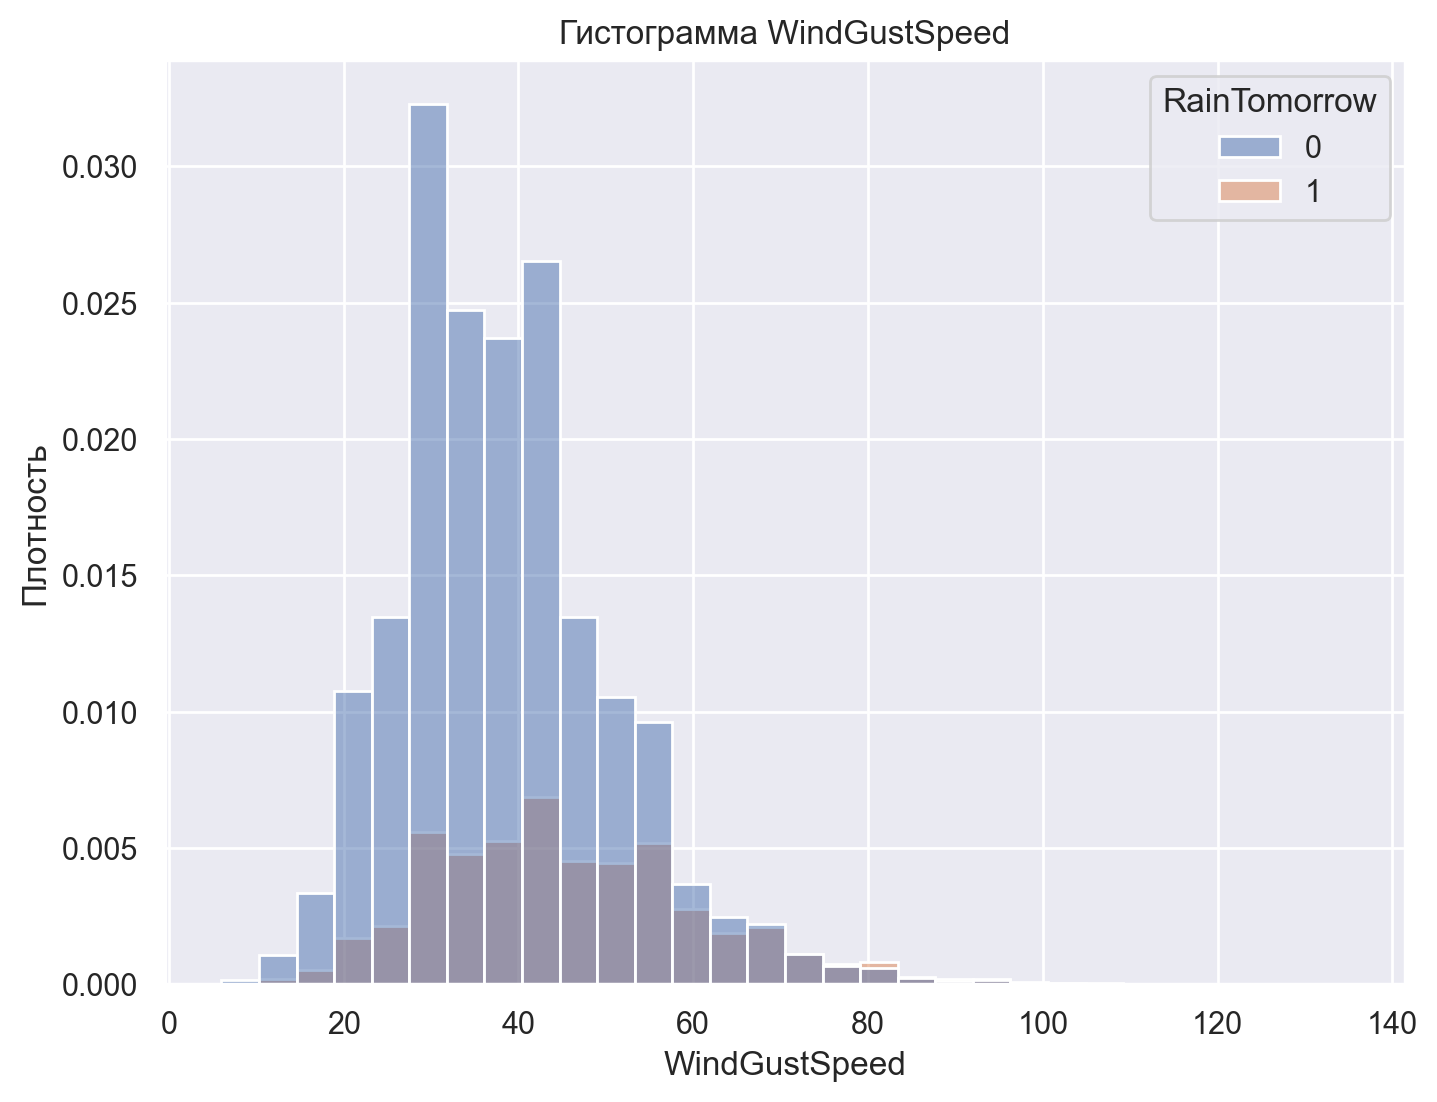

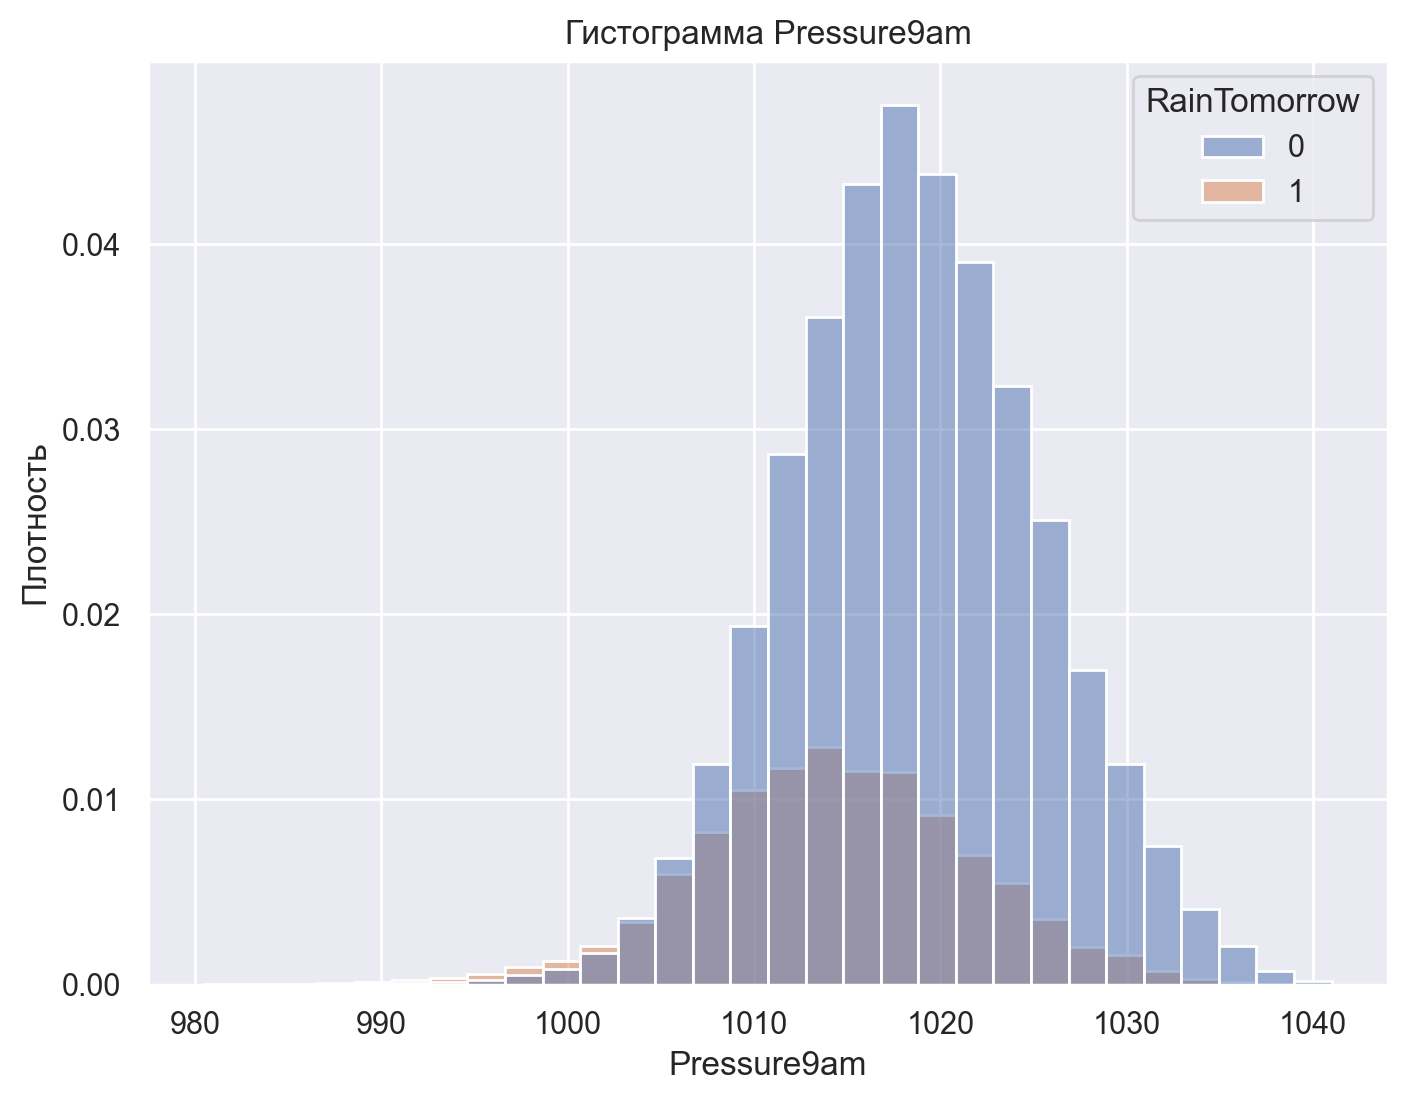

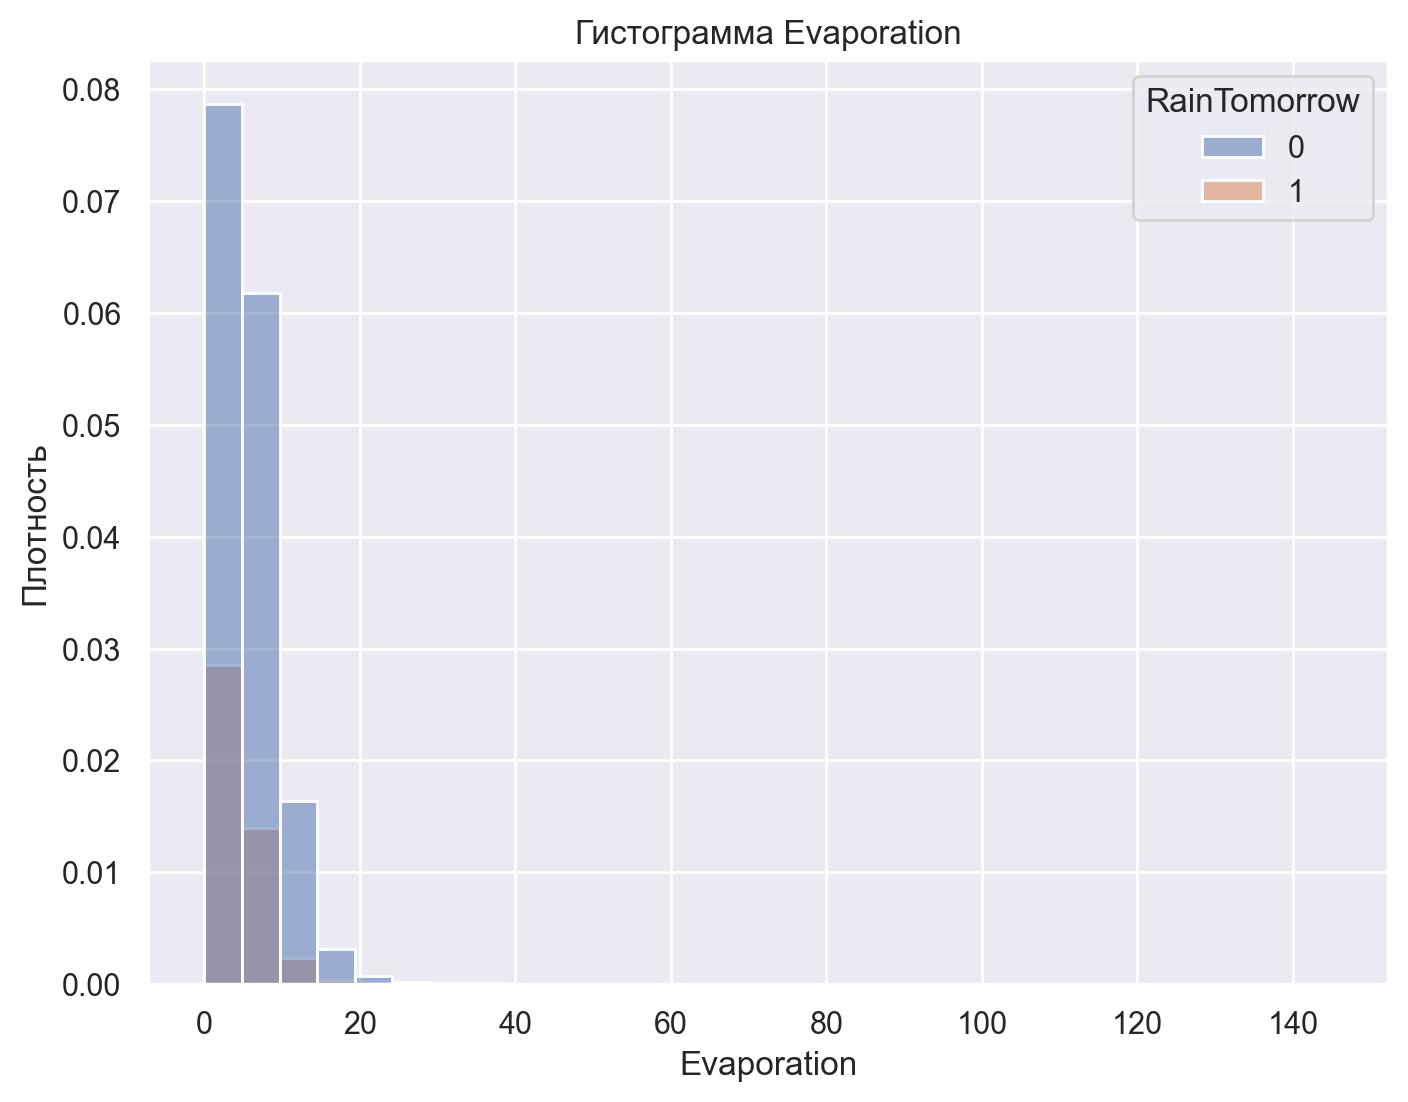

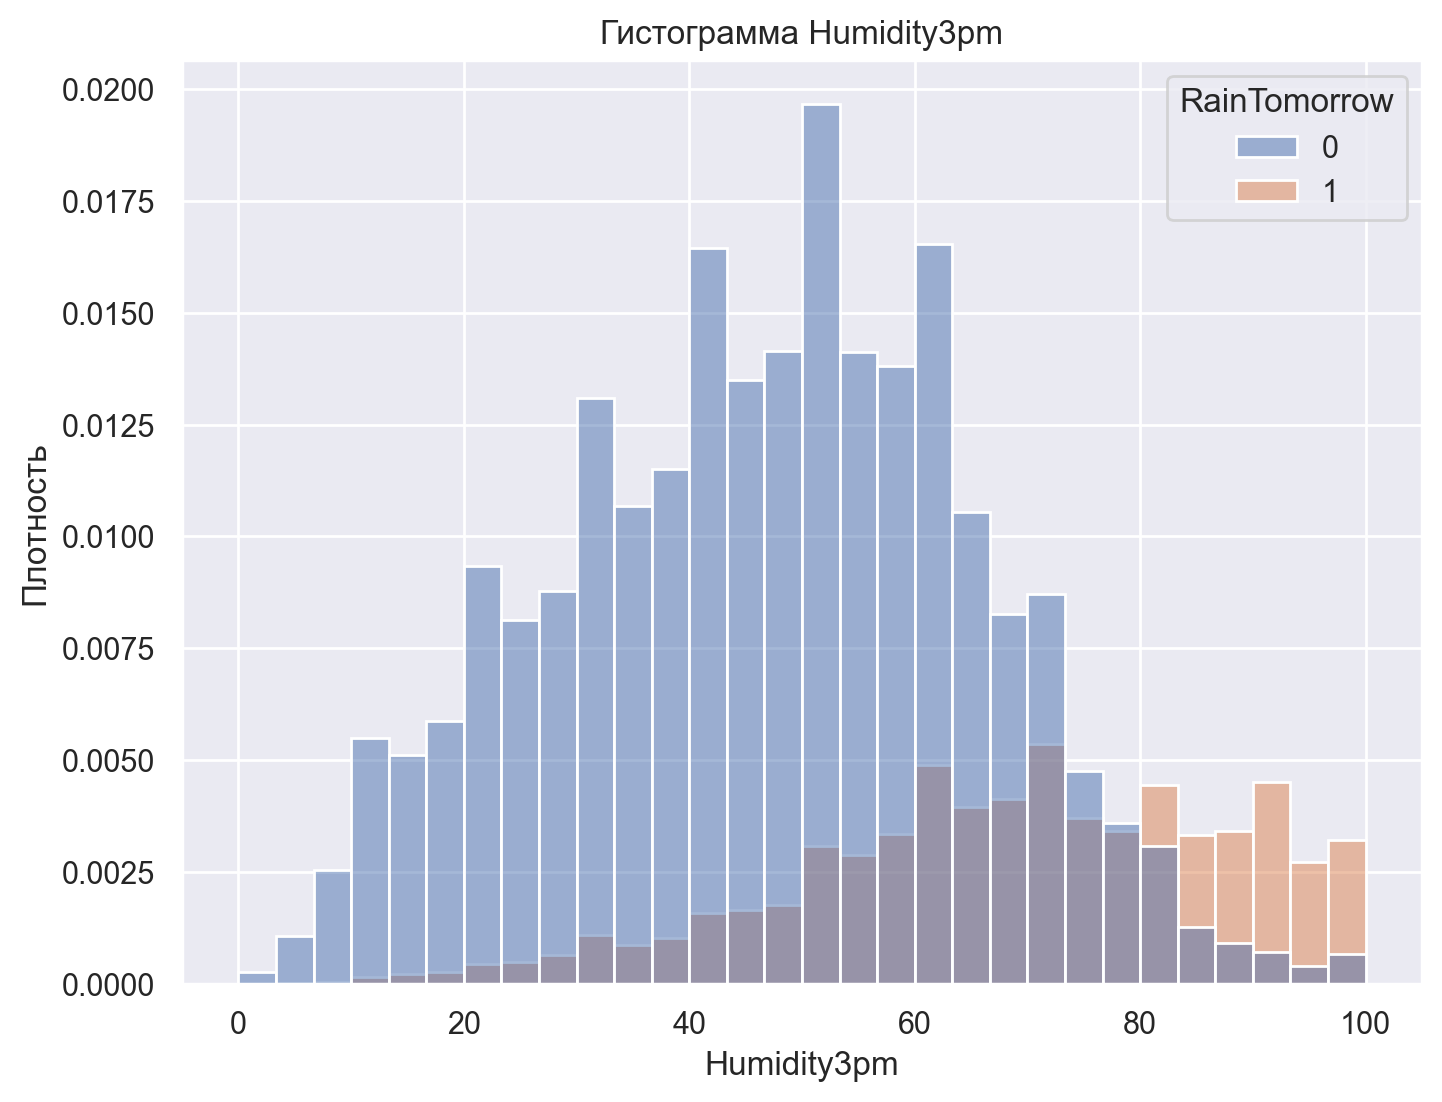

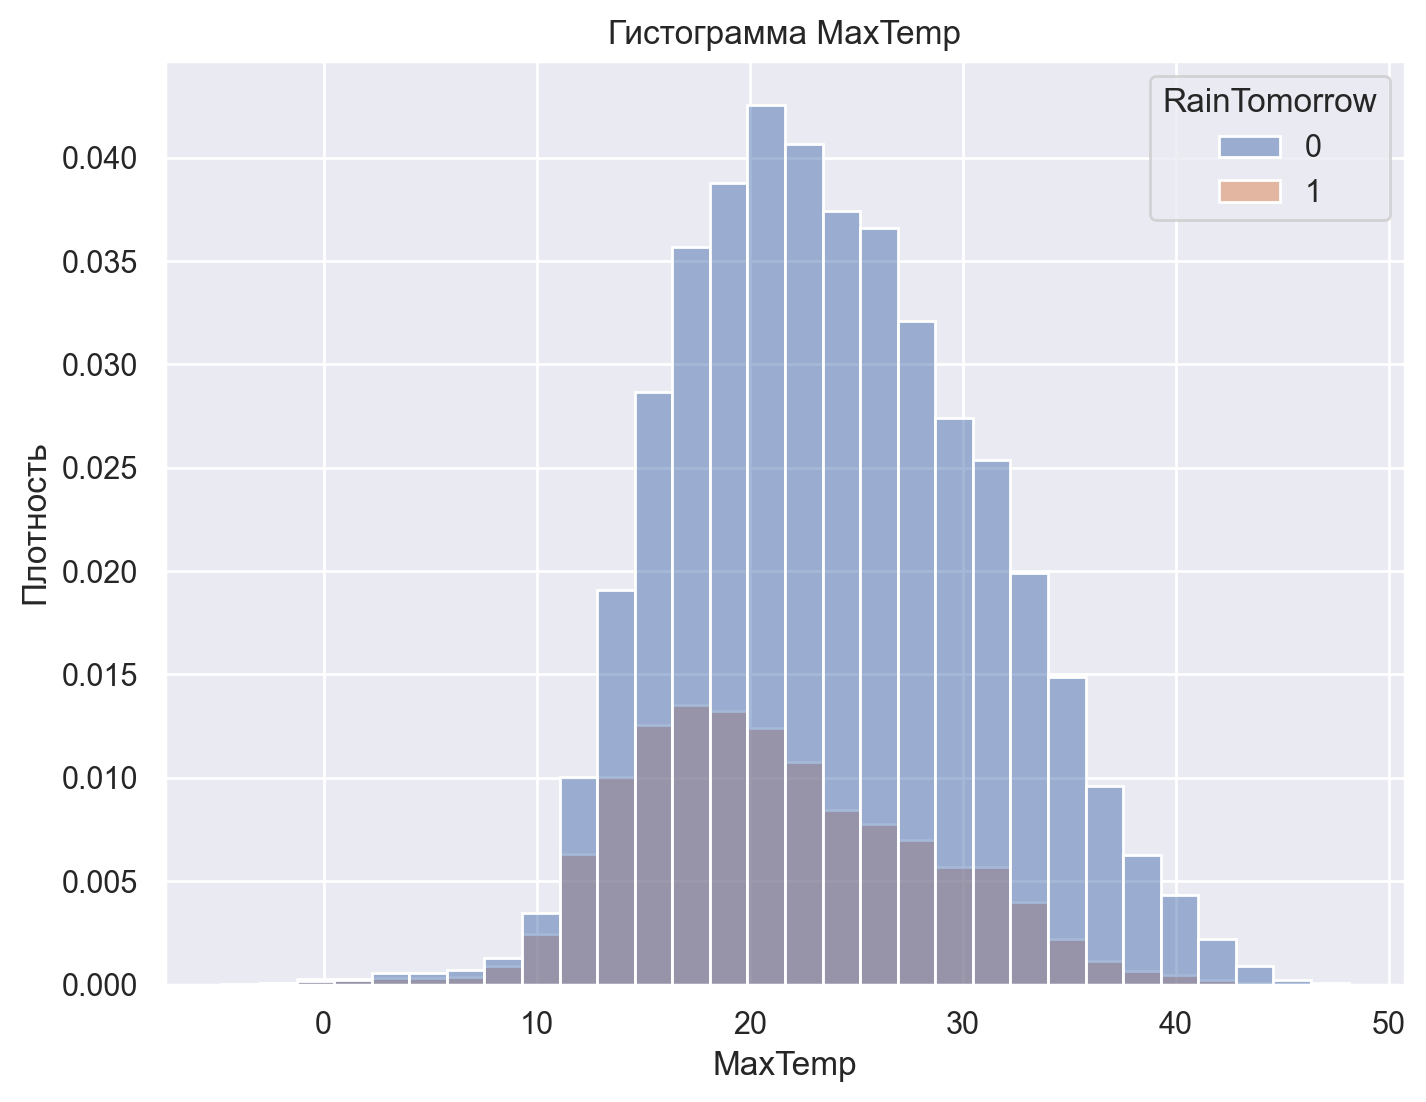

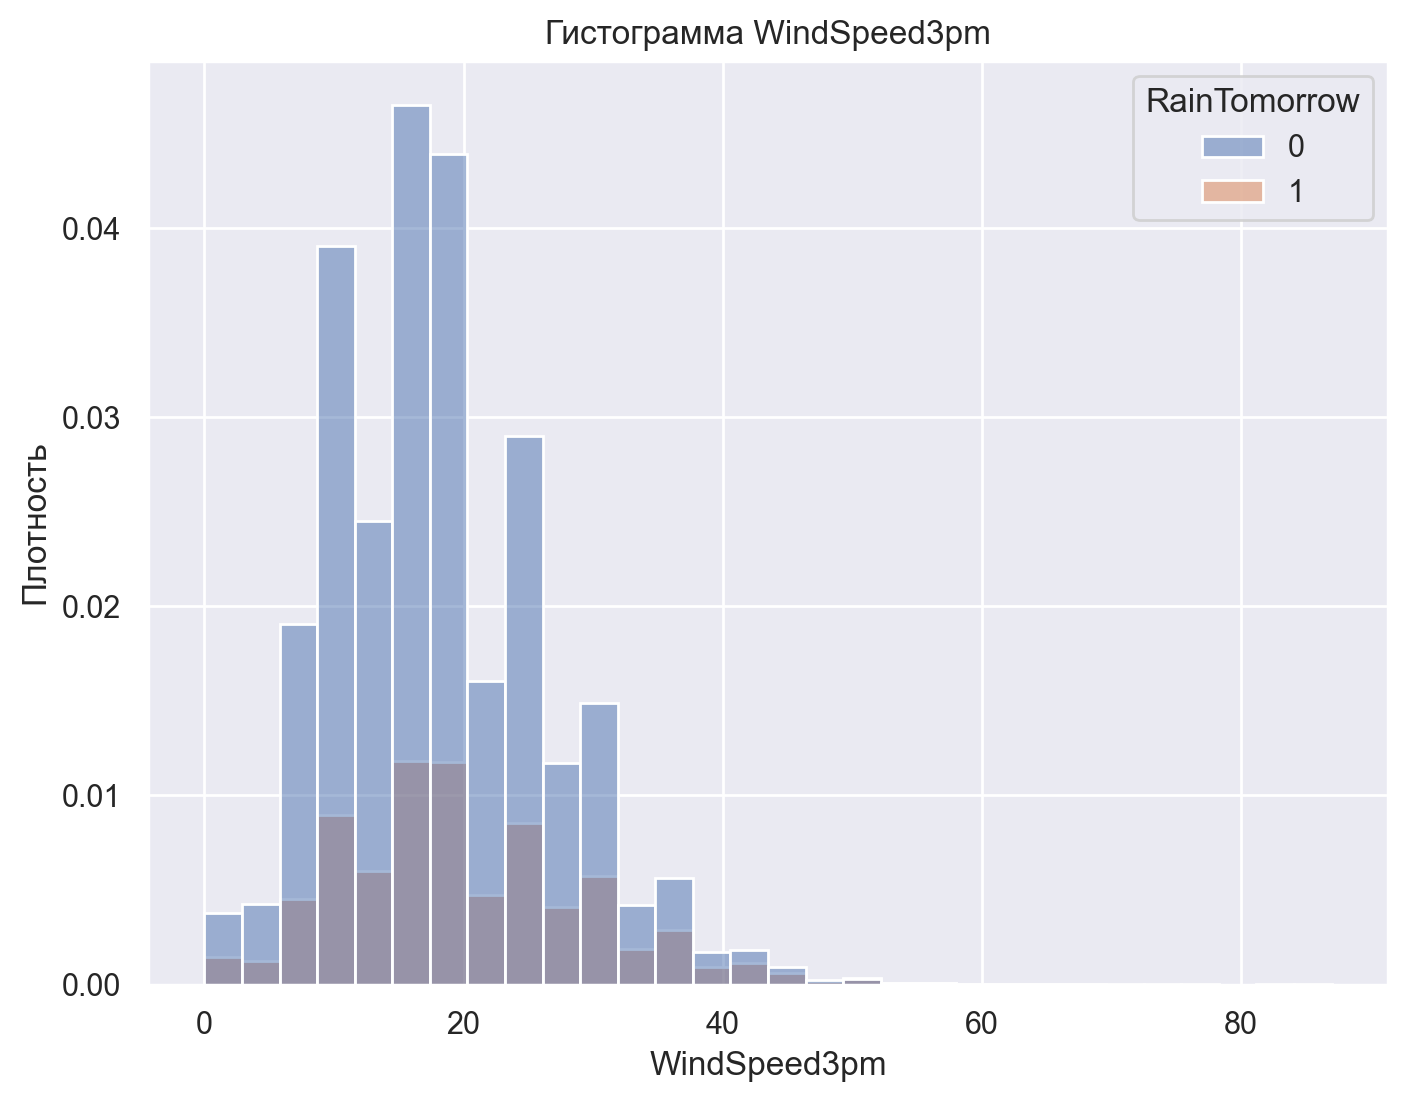

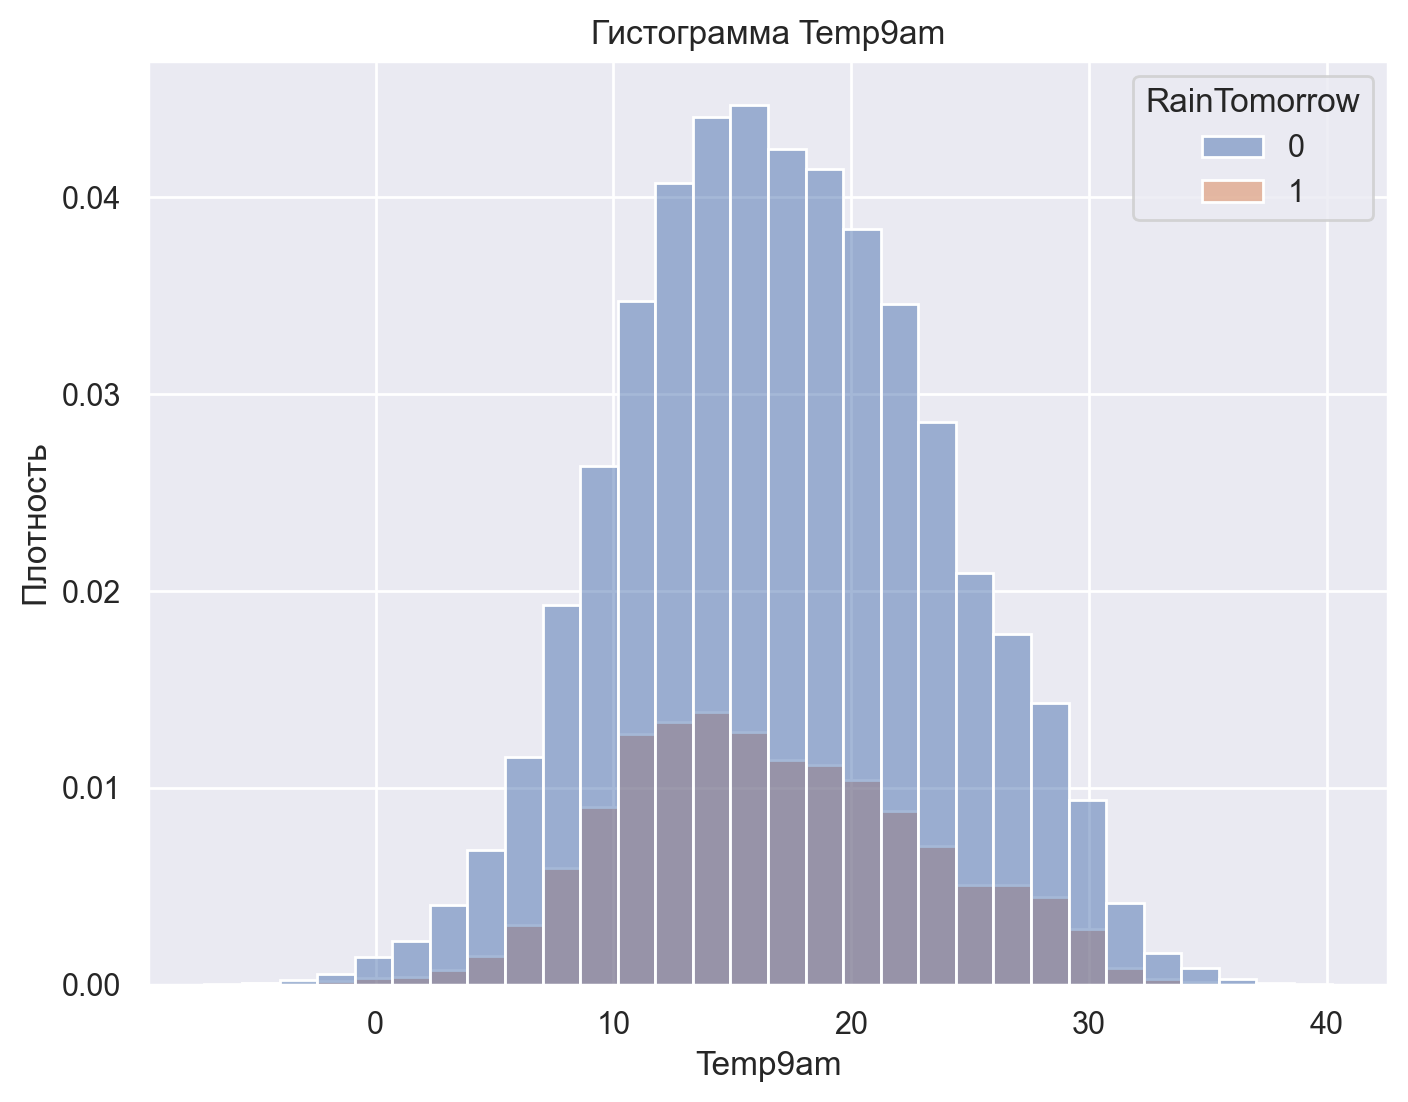

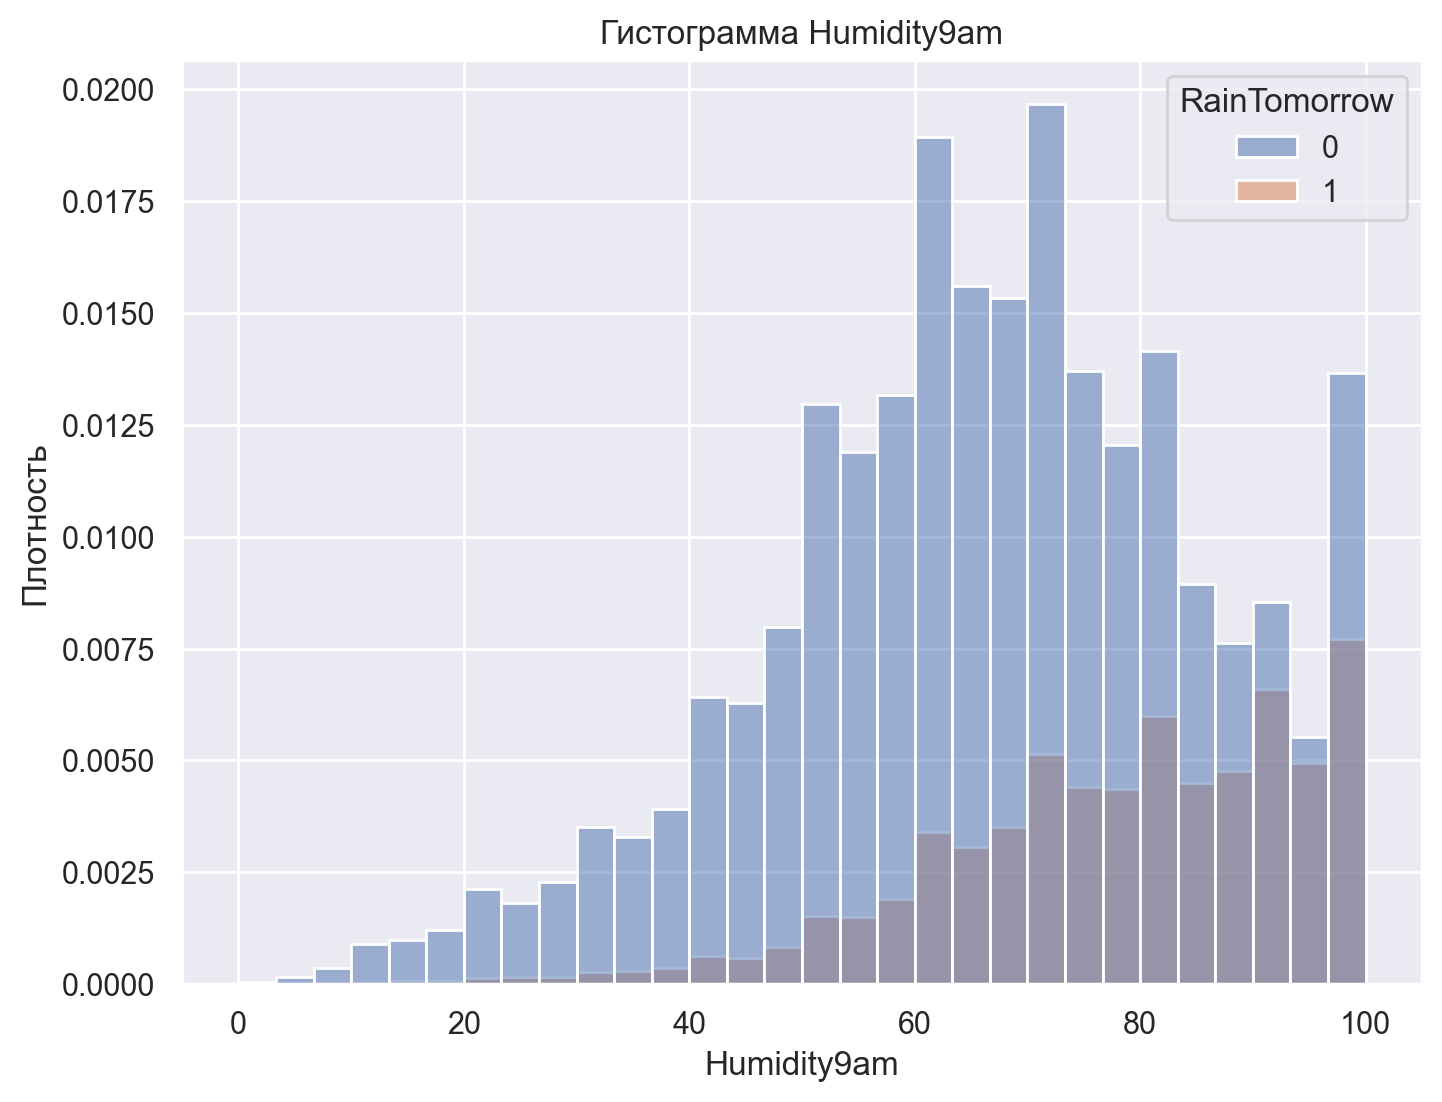

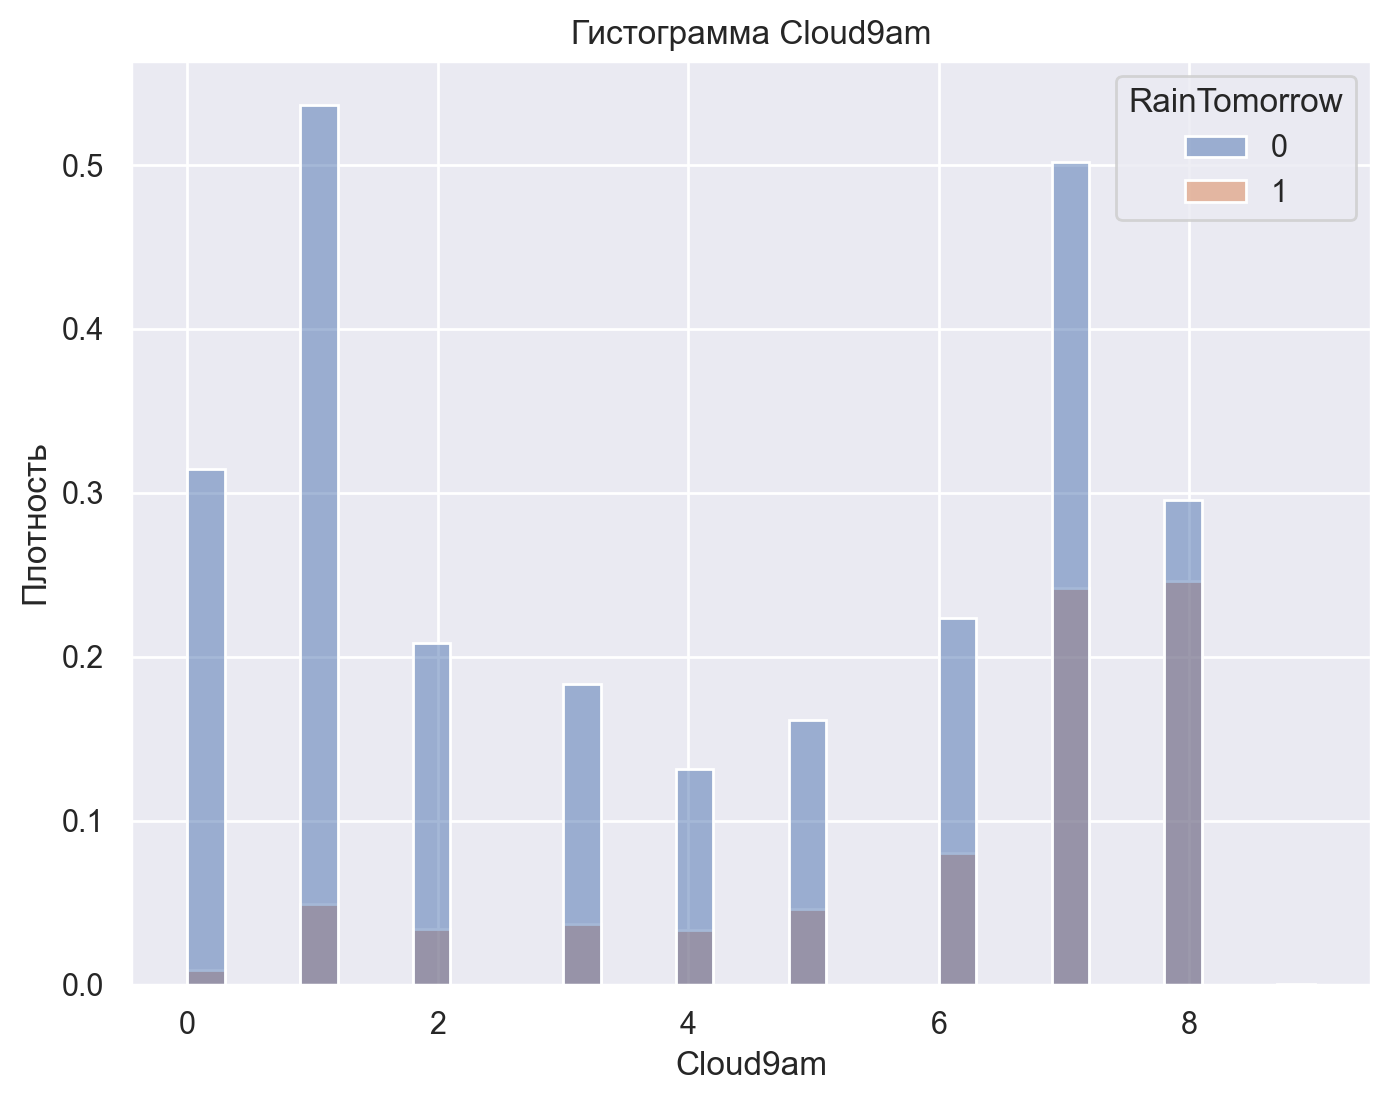

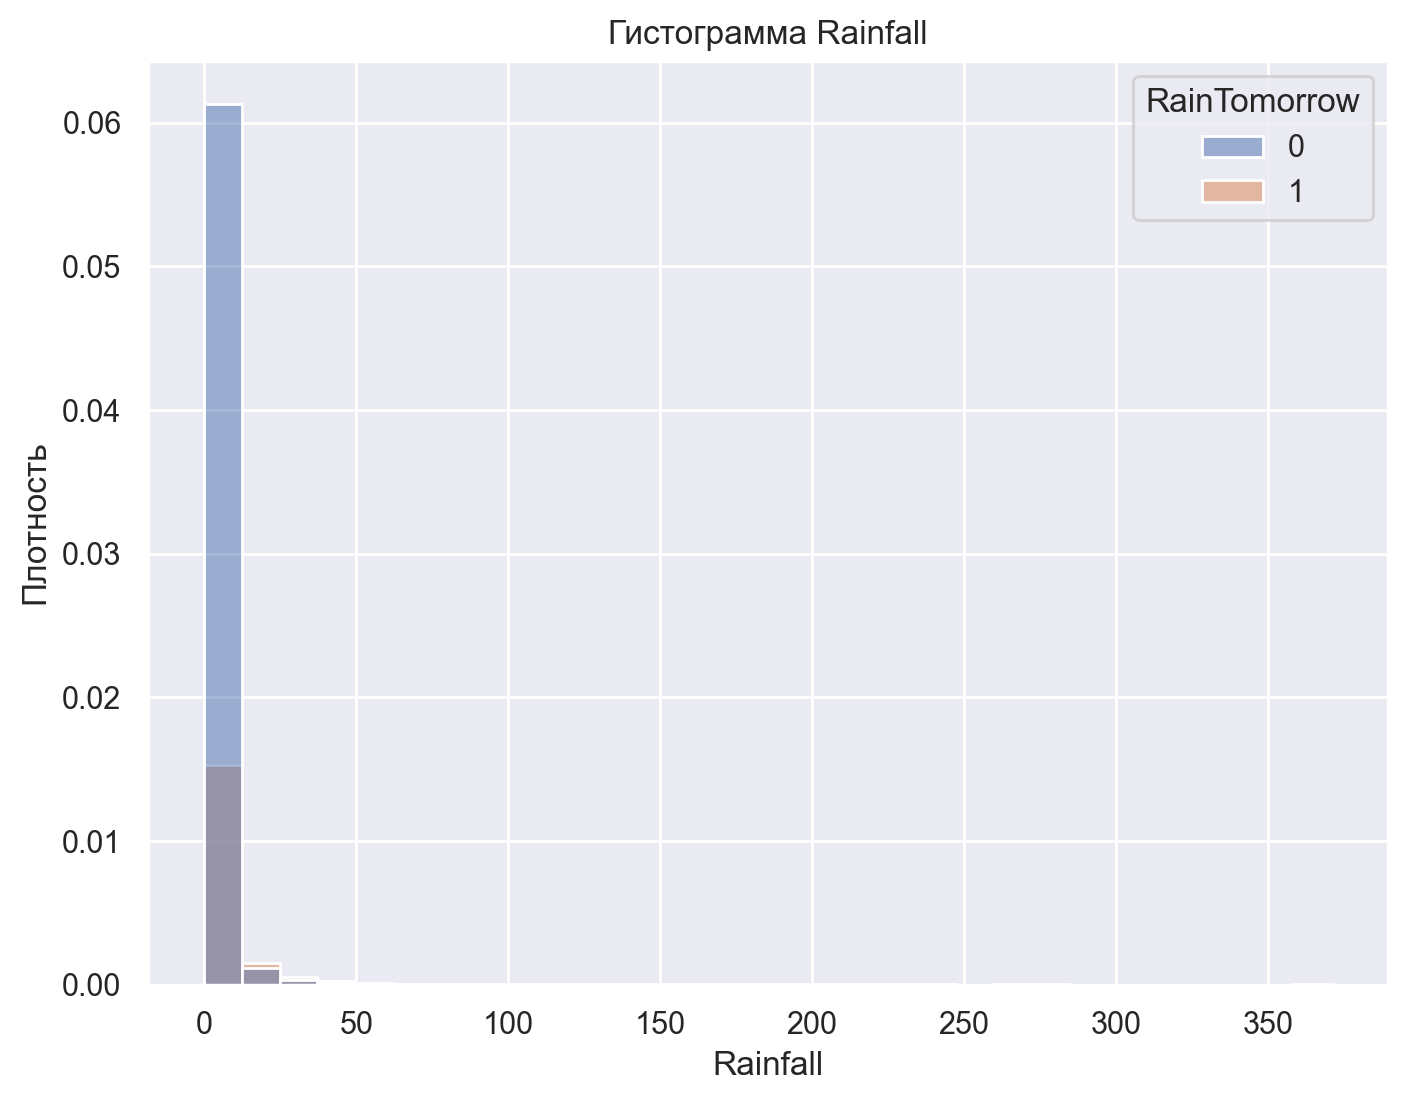

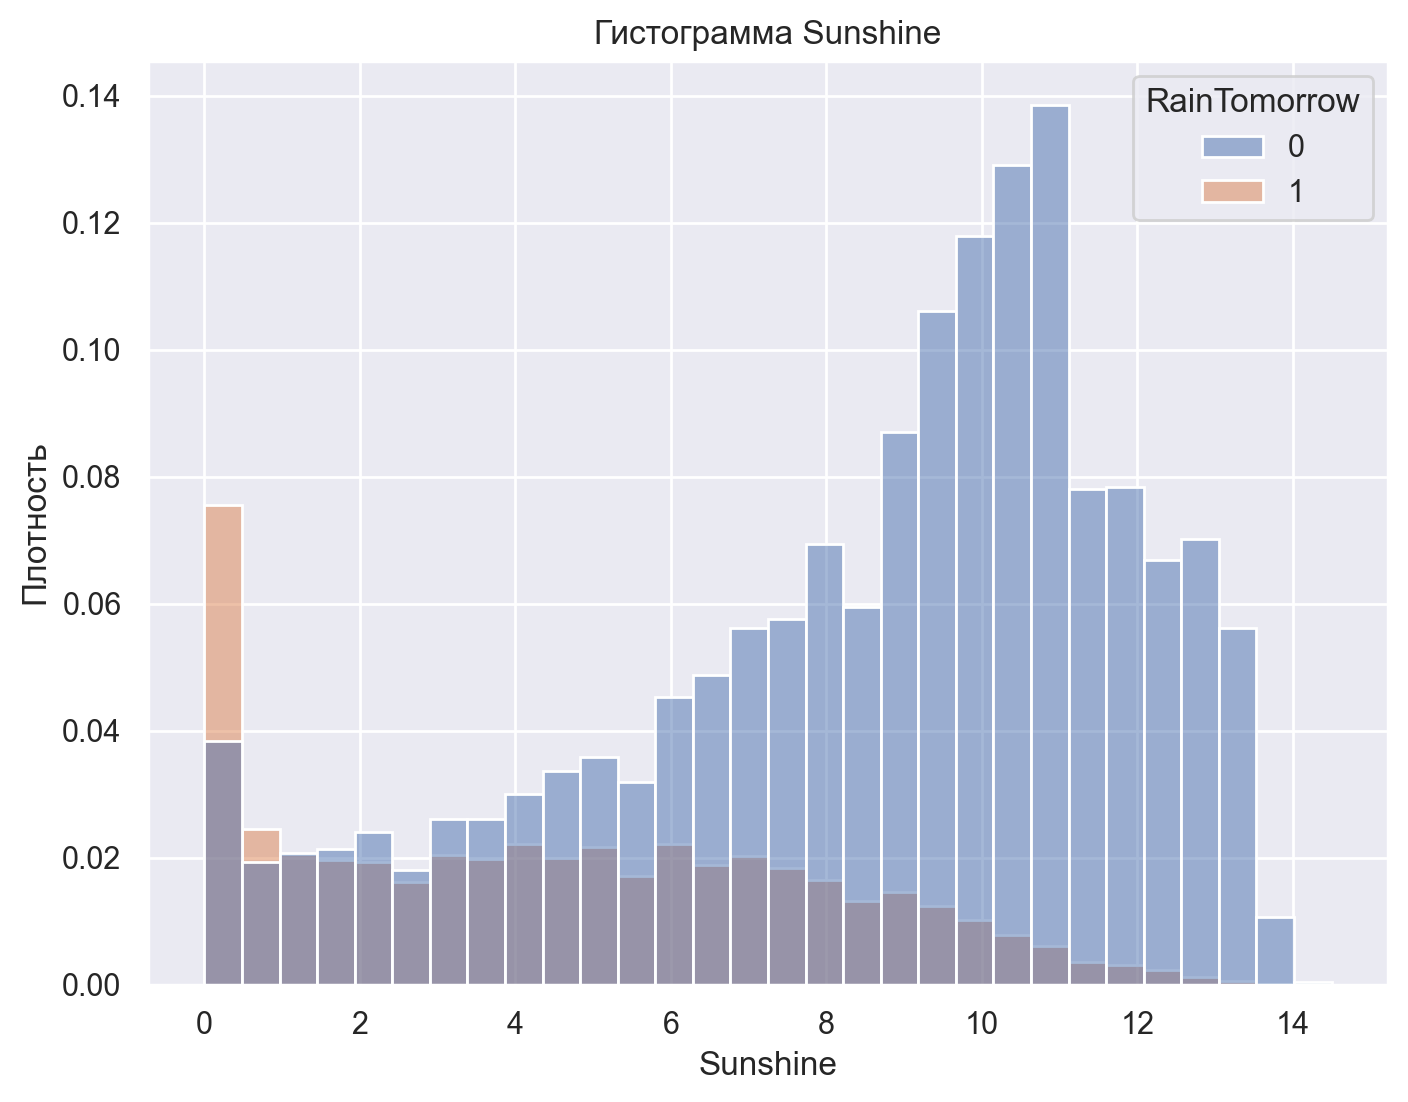

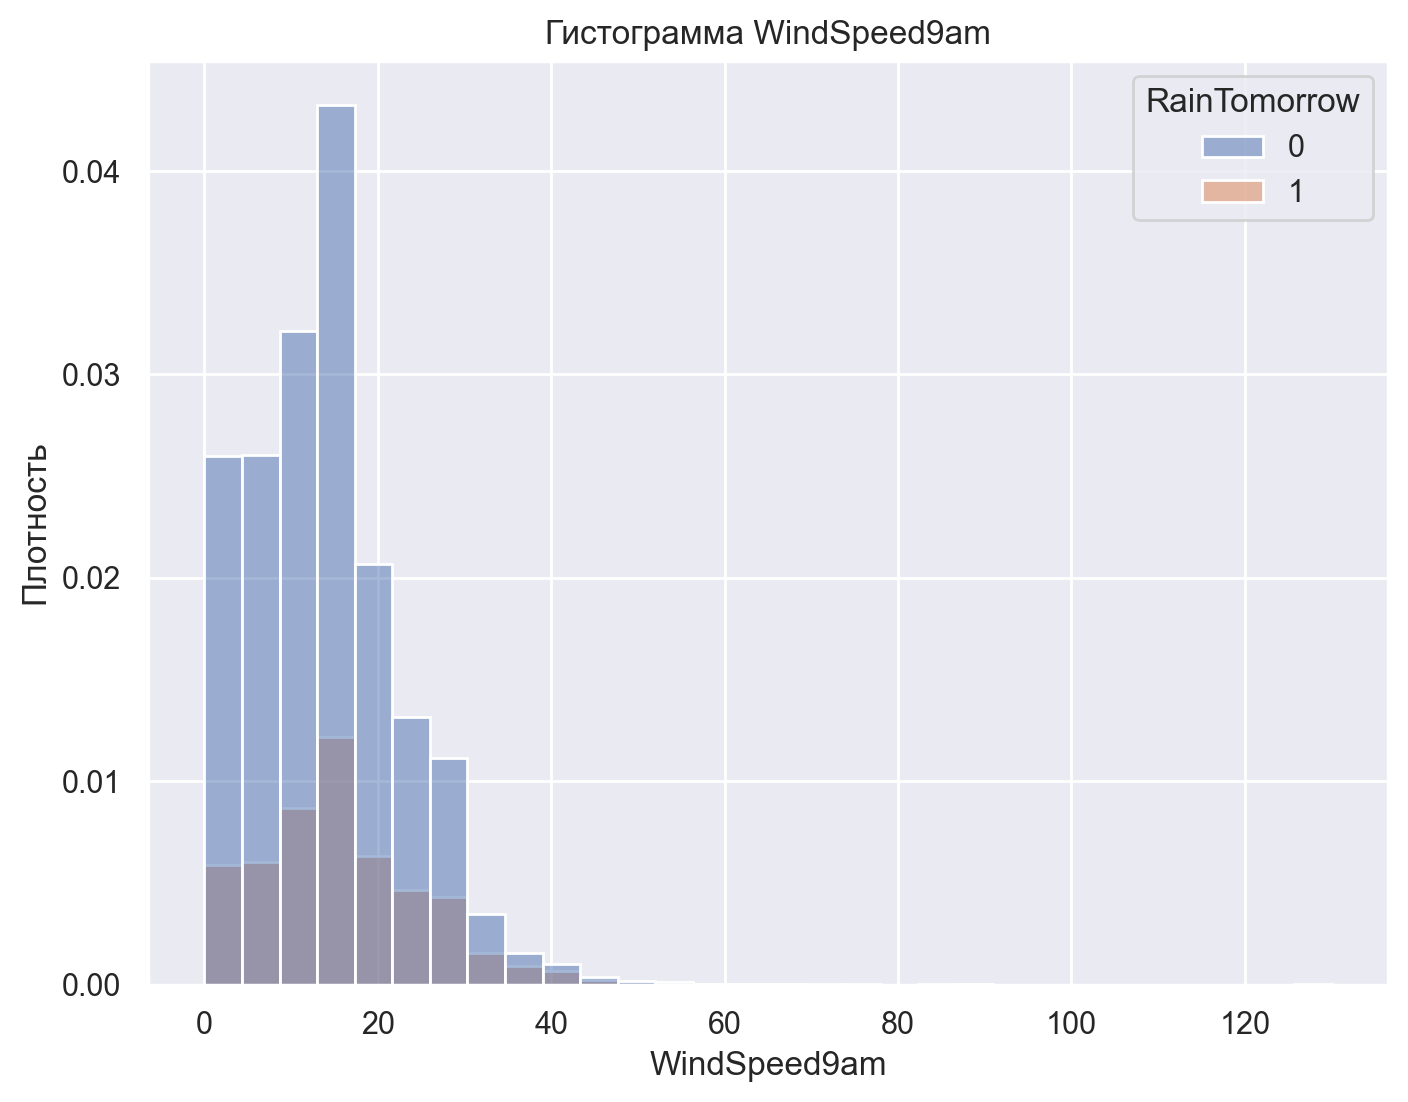

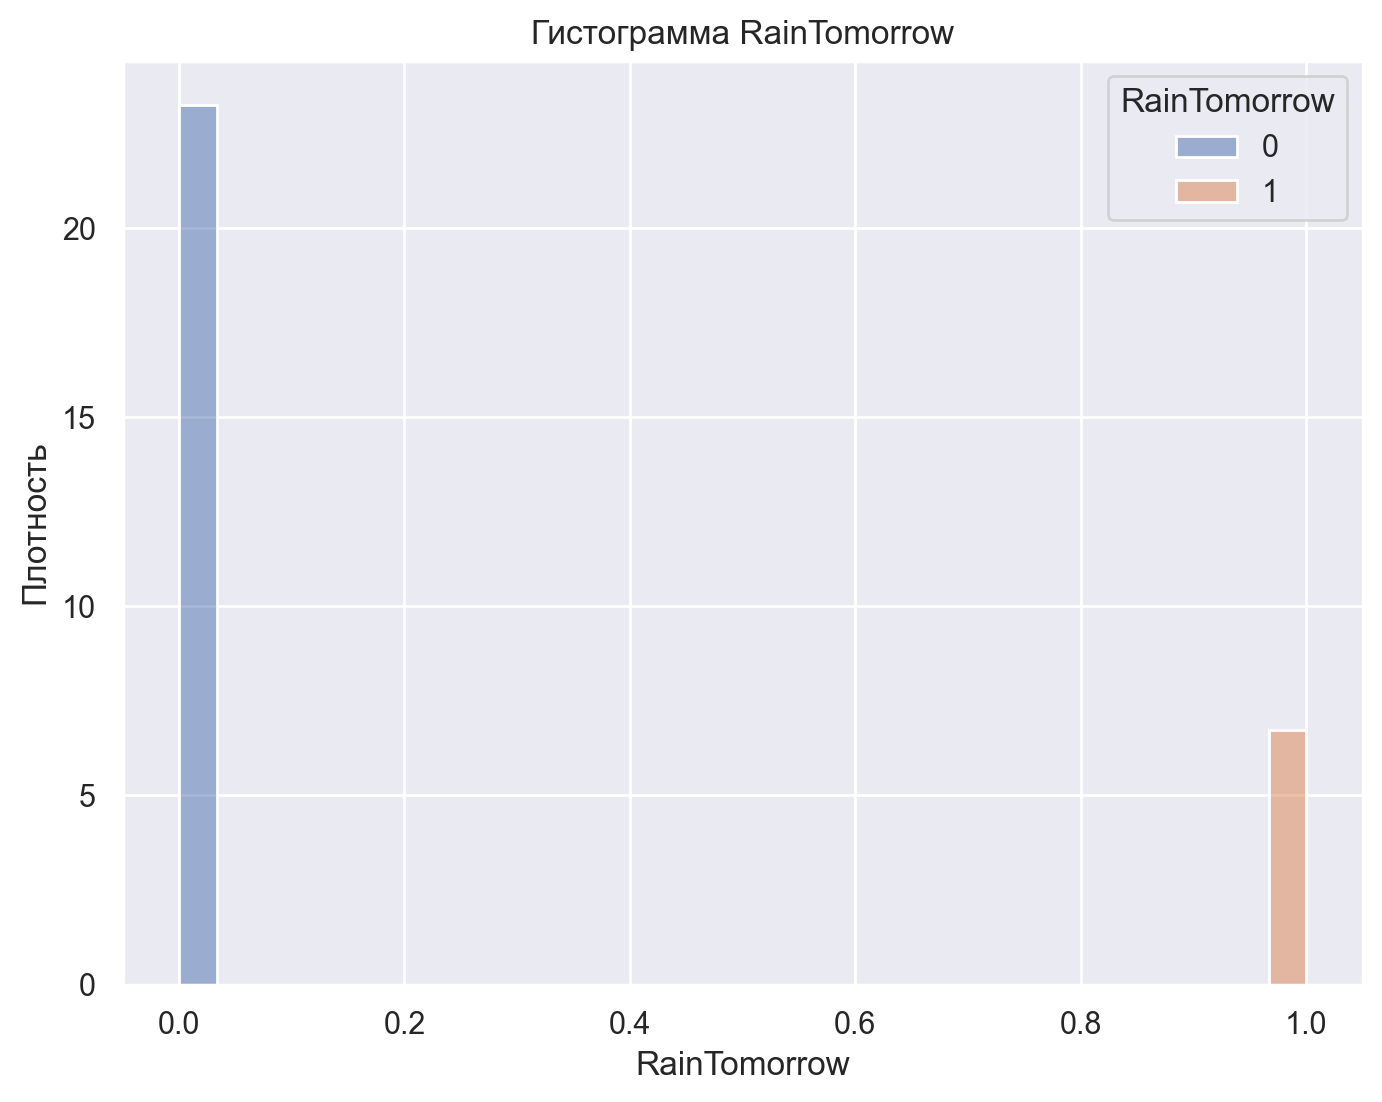

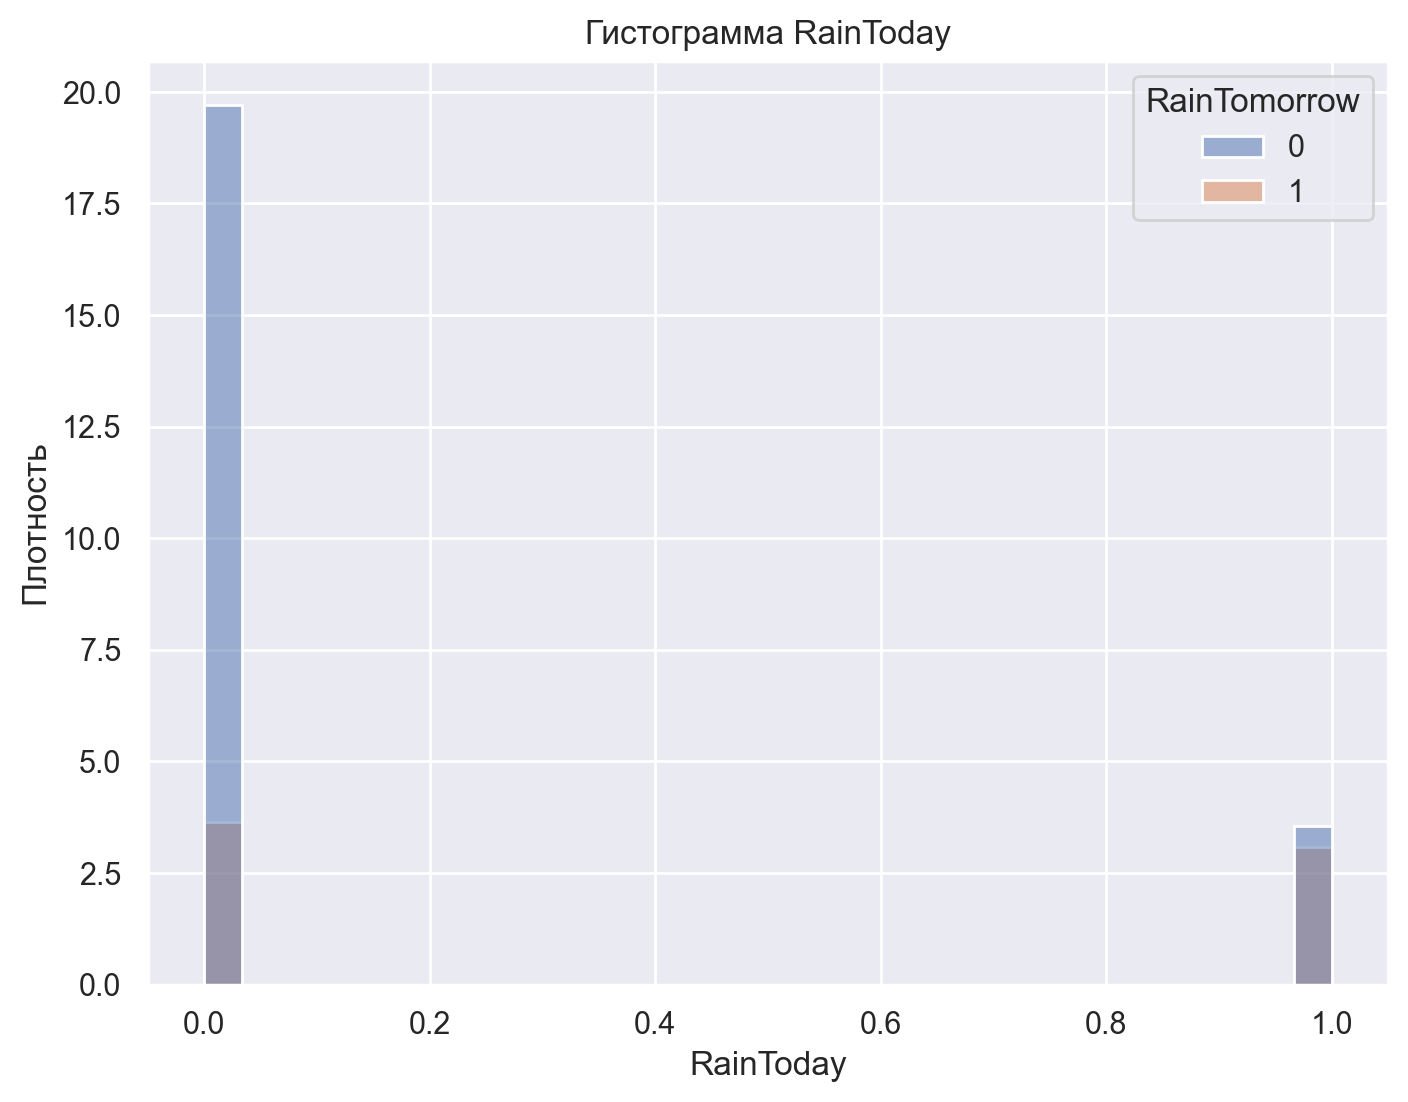

In [494]:
for column in df_numerical.columns:
  plt.figure(figsize=(8, 6))
  sns.histplot(data=df_numerical, x=column, stat="density", hue="RainTomorrow", bins=30)
  plt.title(f'Гистограмма {column}')
  plt.xlabel(column)
  plt.ylabel('Плотность')
  plt.show()

Графики признаков с выбросами имеют характерное *смещение (англ. skew)*. Для смещённых распределений, выбросы можно определить через *межквартильное расстояние (англ. Interquartile Range).*
$$
IQR = Q3 - Q1,
$$
где $Q3$ - третий квартиль, соответствующий порогу $75\%$, $Q1$ - первый квартиль, соответствующий порогу $25\%$.

Тогда выбросы определяют согласно правилу:
*  *Нижний выброс* - $x < Q1 - 1.5\cdot IQR$, $x$ - значение признака;
*  *Верхний выброс* - $x > Q3 + 1.5\cdot IQR$.

Если в результате получилось слишком много выбросов, значение $1.5$ можно увеличить, выделяя более "явные".

**Для полученных числовых признаков выделите соответствующие выбросы с помощью $IQR$ с коэффициентом 2**.

$\textbf{В коде ниже показано как все обьекты с положительной меткой попадают в выбрасы, вне зависимости от того насколько большим я делал зазор, поэтому я пропускаю этап обработки выбрасов}$

In [511]:
outliers = pd.Series(False, index=df_numerical.index)

for column in df_numerical.columns:
    Q1 = df_numerical[column].quantile(0.25)
    Q3 = df_numerical[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 2 * IQR
    upper_bound = Q3 + 2 * IQR
    
    outliers |= ((df_numerical[column] < lower_bound) | (df_numerical[column] > upper_bound))
    print(outliers.sum(), df_numerical[outliers]["RainTomorrow"].sum())


155 125
155 125
185 144
185 144
1220 744
1330 829
2338 942
2338 942
2339 943
2747 1124
2747 1124
2784 1124
2784 1124
25443 12423
25443 12423
25766 12507
45136 31877
50314 31877


In [497]:
df_numerical[outliers].describe()

,Pressure3pm,MinTemp,Temp3pm,Cloud3pm,WindGustSpeed,Pressure9am,Evaporation,Humidity3pm,MaxTemp,WindSpeed3pm,Temp9am,Humidity9am,Cloud9am,Rainfall,Sunshine,WindSpeed9am,RainTomorrow,RainToday
count,45456.000000,50089.000000,49218.000000,31991.000000,46571.000000,45461.000000,28761.000000,48890.000000,50218.000000,49259.000000,49929.000000,49582.000000,32840.000000,49623.000000,26607.000000,49843.000000,50314.000000,50314.000000
mean,1013.287314,12.987420,19.477333,5.858085,44.751584,1015.077642,5.015330,64.046513,21.210930,20.108569,16.491530,76.923742,5.774695,6.549634,5.378025,15.665028,0.633561,0.625174
std,7.434913,6.205643,6.724866,2.229822,15.650235,7.347949,5.355018,19.455524,6.943222,9.761313,6.359303,16.756434,2.401201,13.266865,3.601874,9.845571,0.481836,0.484083
min,977.100000,-7.800000,-5.400000,0.000000,7.000000,980.500000,0.000000,0.000000,-4.800000,0.000000,-7.200000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1008.200000,8.500000,14.600000,5.000000,33.000000,1010.200000,2.000000,52.000000,16.100000,13.000000,11.800000,67.000000,4.000000,0.000000,2.200000,9.000000,0.000000,0.000000
50%,1013.300000,12.500000,18.600000,7.000000,43.000000,1015.100000,3.800000,65.000000,20.200000,19.000000,15.900000,79.000000,7.000000,2.200000,5.400000,15.000000,1.000000,1.000000
75%,1018.300000,17.600000,23.800000,8.000000,54.000000,1020.000000,6.200000,78.000000,25.800000,26.000000,20.800000,90.000000,8.000000,7.200000,8.200000,20.000000,1.000000,1.000000
max,1039.600000,31.900000,46.700000,8.000000,135.000000,1040.500000,145.000000,100.000000,48.100000,87.000000,39.100000,100.000000,9.000000,371.000000,14.200000,130.000000,1.000000,1.000000


In [501]:
df_numerical[~outliers].describe()

,Pressure3pm,MinTemp,Temp3pm,Cloud3pm,WindGustSpeed,Pressure9am,Evaporation,Humidity3pm,MaxTemp,WindSpeed3pm,Temp9am,Humidity9am,Cloud9am,Rainfall,Sunshine,WindSpeed9am,RainTomorrow,RainToday
count,82756.000000,91467.000000,90249.000000,53108.000000,86352.000000,82718.000000,52589.000000,89693.000000,91653.000000,90304.000000,91360.000000,90837.000000,55696.000000,91164.000000,47770.000000,91002.000000,91879.0,91879.0
mean,1016.340768,11.747746,22.892422,3.686996,37.413216,1019.069566,5.718388,44.634252,24.331300,17.835179,17.258565,64.433502,3.648556,0.063987,8.876295,13.091119,0.0,0.0
std,6.560816,6.467097,6.752768,2.663375,11.544840,6.550608,3.358749,18.139985,6.968362,8.122478,6.548848,18.780899,2.858851,0.182741,3.265126,8.183800,0.0,0.0
min,991.400000,-8.500000,-2.900000,0.000000,6.000000,993.900000,0.000000,0.000000,-2.300000,0.000000,-5.600000,5.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
25%,1011.700000,7.100000,18.000000,1.000000,30.000000,1014.600000,3.200000,31.000000,19.200000,11.000000,12.600000,53.000000,1.000000,0.000000,7.200000,7.000000,0.0,0.0
50%,1016.100000,11.700000,22.500000,3.000000,37.000000,1018.900000,5.300000,45.000000,23.900000,17.000000,17.100000,65.000000,3.000000,0.000000,9.700000,13.000000,0.0,0.0
75%,1020.800000,16.500000,27.600000,6.000000,44.000000,1023.400000,7.800000,58.000000,29.300000,22.000000,21.900000,77.000000,7.000000,0.000000,11.100000,19.000000,0.0,0.0
max,1038.900000,33.900000,45.900000,9.000000,81.000000,1041.000000,17.000000,100.000000,47.300000,46.000000,40.200000,100.000000,9.000000,1.000000,14.500000,43.000000,0.0,0.0


In [498]:
df_numerical["RainTomorrow"].sum()

np.int64(31877)

In [512]:
df_numerical[outliers]["RainTomorrow"].sum()

np.int64(31877)

Есть 2 стратегии работы с выбросами:
*   Удалить соответствующий сэмпл;
*   Заменить его на среднее/медиану.

В первом приближении, удалим соответствующие примеры.

In [522]:
df_num_no_outliers = df_numerical.reset_index(drop=True)

Базовый анализ датасета почти закончен! Осталась пара шагов.

Выделим целевой признак в соответствующую переменную. Посмотрим на пропуски в обучающей выборке.

In [523]:
X = df_num_no_outliers.drop(['RainTomorrow'], axis=1)
y = df_num_no_outliers['RainTomorrow']
X.isnull().sum()

Pressure3pm      13981
MinTemp            637
Temp3pm           2726
Cloud3pm         57094
WindGustSpeed     9270
Pressure9am      14014
Evaporation      60843
Humidity3pm       3610
MaxTemp            322
WindSpeed3pm      2630
Temp9am            904
Humidity9am       1774
Cloud9am         53657
Rainfall          1406
Sunshine         67816
WindSpeed9am      1348
RainToday            0
dtype: int64

Пропуски необходимо заполнить. Обычно это делают с помощью среднего/медианы. Мы воспользуемся медианой, так как она более устойчива к выбросам.

**Заполните пропуски в обучающей выборке медианой.**

In [524]:
X = X.fillna(X.median())

Наконец, осталось провести нормализацию значений.

Разделим выборку на обучающую и тестовую, чтобы не учитывать масштаб на тесте.

In [525]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
X_train.describe()

,Pressure3pm,MinTemp,Temp3pm,Cloud3pm,WindGustSpeed,Pressure9am,Evaporation,Humidity3pm,MaxTemp,WindSpeed3pm,Temp9am,Humidity9am,Cloud9am,Rainfall,Sunshine,WindSpeed9am,RainToday
count,113754.000000,113754.000000,113754.00000,113754.000000,113754.000000,113754.000000,113754.000000,113754.000000,113754.000000,113754.000000,113754.000000,113754.000000,113754.000000,113754.000000,113754.000000,113754.000000,113754.000000
mean,1015.252305,12.175225,21.67070,4.701452,39.895063,1017.646309,5.183036,51.480317,23.221349,18.633252,16.981340,68.839434,4.647652,2.323285,8.041763,13.984704,0.221891
std,6.683925,6.384019,6.87257,2.118964,13.127684,6.750345,3.213743,20.531492,7.109859,8.709156,6.470597,18.944168,2.292660,8.425833,2.765524,8.842558,0.415520
min,978.200000,-8.500000,-5.40000,0.000000,6.000000,980.500000,0.000000,0.000000,-4.800000,0.000000,-7.200000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1011.000000,7.600000,16.70000,4.000000,31.000000,1013.500000,4.000000,37.000000,17.900000,13.000000,12.300000,57.000000,3.000000,0.000000,8.200000,7.000000,0.000000
50%,1015.200000,12.000000,21.10000,5.000000,39.000000,1017.600000,4.800000,52.000000,22.600000,19.000000,16.700000,70.000000,5.000000,0.000000,8.500000,13.000000,0.000000
75%,1019.400000,16.800000,26.30000,6.000000,46.000000,1021.800000,5.400000,65.000000,28.200000,24.000000,21.500000,83.000000,6.000000,0.600000,8.700000,19.000000,0.000000
max,1038.900000,33.900000,46.70000,9.000000,135.000000,1041.000000,145.000000,100.000000,48.100000,87.000000,40.200000,100.000000,8.000000,371.000000,14.500000,130.000000,1.000000


Для нормализации будем использовать `MinMaxScaler` модуля `sklearn.preprocessing`.

**Вам необходимо "обучить" (`fit`) scaler на `X_train` и использовать его на `X_test` (`transform`).**

**Примечание:** выходом `MinMaxScaler` является `np.array`. Чтобы в дальнейшем работать с выборкой, после масштабирования необходимо обратно перевести её в `pd.DataFrame`.

In [526]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train_array = scaler.fit_transform(X_train)
X_test_array = scaler.transform(X_test)

X_train = pd.DataFrame(X_train_array, columns=X_train.columns, index=X_train.index)
X_test = pd.DataFrame(X_test_array, columns=X_test.columns, index=X_test.index)
# Output: `X_train`, `X_test`: pd.DataFrame type.

### Задача 2 (5 баллов): Классификация



* Вам необходимо обучить обработанный датасет с помощью логистической регрессии.
* Вы можете пользоваться библиотекой `sklearn`
* Проведите классификацию с L1 и L2-регуляризацией. Какие признаки регуляризация lasso посчитала неинформативными?
* Проведите классификацию с регуляризацией [elasticnet](https://en.wikipedia.org/wiki/Elastic_net_regularization). Для этого воспользуйтесь поиском по сетке гиперпараметров (`GridSearchCV` модуля `sklearn.model_selection`). Пространство поиска определите константой `C = [1, 2, 5, 10, 100]` и значением `l1_ratio = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]`.
* Сделайте выводы по полученым результатам




In [ ]:
from sklearn.linear_model import LogisticRegression

clf_l2 = LogisticRegression(penalty="l2")
clf_l2.fit(X_train, y_train)
y_pred_l2 = clf_l2.predict(X_test)

clf_l1 = LogisticRegression(penalty="l1", solver="liblinear")
clf_l1.fit(X_train, y_train)
y_pred_l1 = clf_l1.predict(X_test)

In [531]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [1, 2, 5, 10, 100],
    'l1_ratio': [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
}

clf_elastic = LogisticRegression(
    penalty='elasticnet',
    solver='saga',
    max_iter=5000
)

grid = GridSearchCV(clf_elastic, param_grid, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)

,estimator,LogisticRegre...solver='saga')
,param_grid,"{'C': [1, 2, ...], 'l1_ratio': [0.0, 0.1, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'elasticnet'


In [532]:
print("Accuracy для L1:", clf_l1.score(X_test, y_test))
print("Accuracy для L2:", clf_l2.score(X_test, y_test))

print("для elasticnet:")
print("Лучшая модель:", grid.best_estimator_)
print("Лучшие параметры:", grid.best_params_)
print("Точность:", grid.best_score_)

Accuracy для L1: 0.8394106684482576
Accuracy для L2: 0.8393403424874293
для elasticnet:
Лучшая модель: LogisticRegression(C=1, l1_ratio=1.0, max_iter=5000, penalty='elasticnet',
                   solver='saga')
Лучшие параметры: {'C': 1, 'l1_ratio': 1.0}
Точность: 0.8432055020887864


Довольно не плохие результаты

### Задача 3* (2 балла): Категориальные признаки

* В ходе анализа датасета было сделано несколько упрощений:
    * Категориальные признаки были опущены (`df --> df_numerical`);
    * Выбросы были опущены (`df_numerical --> df_num_no_outliers`).
* Необходимо провести обработку категориальных признаков.
* Протестировать качество логистической регрессии и подобрать гиперпараметры на различных вариантах:
    * С категориальными признаками и без учета выбросов;
    * Без категориальных признаков, с учетом выбросов;
    * С категориальными признаками, с учетом выбросов.
* Поощряется изобретательность. Возможно, какие-то категориальные/численные признаки покажутся менее инфомативными.


* P.S. Не расстраивайтесь, если выдвигаемые гипотезы не дадут прибавки в качестве. Важен сам пайплайн проверки выдвигаемых гипотез)

In [ ]:
# YOUR CODE HERE:
###########################
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
###########################